# 99_main_analysis — Black-Litterman LSTM vs ANN 메인 분석

본 노트북은 paper 의 main result 를 단계별로 정리.

## 구조

```
[0]  환경 셋업 (import, 데이터 로드)
[1]  LSTM vs ANN σ 예측 성능 (RMSE, Spearman, Hit rate)
[2]  1-step variation × (전체 + 레짐별) 통합 — Q/P/Omega/Prior 한 가지 변화
[3]  P 행렬 변경 (mcap, eq, rp) 후 모든 슬롯 비교 (전체 + 레짐별)
[4]  R1-R3, R3 mechanism (LSTM vs ANN 예측 quality + portfolio transmission)
[5]  R4 (AI rally) 분석 — fpm 우위 + prior 효과
```

**Anchor (Pyo & Lee 2018)**: `mat_mcap_mcap_fpm_pap`

**Regime 정의** (HMM-informed):
- R1 회복   (2010-01 ~ 2012-06, 30mo)
- R2 확장   (2012-07 ~ 2019-12, 90mo)
- R3 위기   (2020-01 ~ 2023-06, 42mo)
- R4 정상화 (2023-07 ~ 2025-12, 30mo)


In [7]:
# ── [0] 환경 셋업 ────────────────────────────────────────────────
import pickle
import math
import warnings
import platform
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

warnings.filterwarnings('ignore')

# 한글 폰트
if platform.system() == 'Windows':
    plt.rcParams['font.family']     = 'sans-serif'
    plt.rcParams['font.sans-serif'] = ['Malgun Gothic', 'Arial Unicode MS', 'DejaVu Sans']
elif platform.system() == 'Darwin':
    plt.rcParams['font.family']     = 'sans-serif'
    plt.rcParams['font.sans-serif'] = ['AppleGothic', 'NanumGothic', 'DejaVu Sans']
else:
    plt.rcParams['font.family']     = 'sans-serif'
    plt.rcParams['font.sans-serif'] = ['NanumGothic', 'Noto Sans CJK KR', 'DejaVu Sans']
plt.rcParams['axes.unicode_minus'] = False

# 경로
BASE_DIR    = Path.cwd()
RESULTS_DIR = BASE_DIR / 'results'
DATA_DIR    = BASE_DIR / 'data'
OUT_DIR     = BASE_DIR / 'outputs' / '99_main_analysis'
OUT_DIR.mkdir(parents=True, exist_ok=True)

CUTOFF = '2025-12-31'

# pkl 로드
loaded = {}
for pkl in sorted(RESULTS_DIR.glob('*.pkl')):
    try:
        with open(pkl, 'rb') as f:
            loaded[pkl.stem] = pickle.load(f)
    except Exception as e:
        print(f'  pkl 로드 실패 {pkl.name}: {e}')
n_l = sum(1 for n in loaded if not n.endswith('_ann'))
n_a = sum(1 for n in loaded if n.endswith('_ann'))
print(f'pkl 로드 완료: {len(loaded)}개 (LSTM {n_l} / ANN {n_a})')

# rf + spy
_panel = pd.read_csv(DATA_DIR / 'monthly_panel.csv',
                     usecols=['date','ticker','rf_1m','spy_ret'], parse_dates=['date'])
rf      = _panel.groupby('date')['rf_1m'].first().dropna()
spy_ret = _panel.groupby('date')['spy_ret'].first().dropna()
print(f'rf/spy 기간: {rf.index[0].date()} ~ {rf.index[-1].date()}')

# Anchor 별칭
ANCHOR_L = 'mat_mcap_mcap_fpm_pap'
ANCHOR_A = 'mat_mcap_mcap_fpm_pap_ann'

# Regime 정의
REGIMES = [
    ('R1_회복',   '2010-01-01', '2012-06-30'),
    ('R2_확장',   '2012-07-01', '2019-12-31'),
    ('R3_위기',   '2020-01-01', '2023-06-30'),
    ('R4_정상화', '2023-07-01', '2025-12-31'),
]

pkl 로드 완료: 216개 (LSTM 108 / ANN 108)
rf/spy 기간: 2005-01-31 ~ 2025-12-31


## [1] LSTM vs ANN σ 예측 성능 (RMSE, Spearman, Hit rate)

Portfolio 결과로 진입하기 전, 두 모델의 σ 예측 quality 자체를 비교.

**데이터**
- LSTM (HAR ensemble): `data/03b_lstm/data/ensemble_predictions_stockwise.csv` (daily → month-end last)
- ANN (Pyo-Lee paper): `data/paper_ann_predictions.csv` (monthly)
- 단위: log(daily realized std). y_pred_ensemble / y_true 동일 단위
- 비교: (year-month, ticker) intersection merge

**Metrics**
- **RMSE**: level accuracy (낮을수록 좋음). ΔRMSE = ANN − LSTM (+ = LSTM 우위).
- **Spearman**: rank correlation (높을수록 좋음). 전체 pooled (date × ticker). ΔSp = LSTM − ANN.
- **Hit rate (저변동 / 고변동 분리)**:
  - `Hit_lo`: 월별 cross-section 으로 예측 저변동 top-30% 가 실제 저변동 top-30% 와 겹치는 비율
  - `Hit_hi`: 동일하지만 고변동 top-30% 기준
  - ΔHit_lo / ΔHit_hi = LSTM − ANN
  - BL P 행렬은 low-vol / high-vol 양 극단 모두 view 로 사용 → 분리해서 어느 쪽 분류가 더 정확한지 확인

기간: 전체 (2010-01 ~ 2025-12) + R1/R2/R3/R4 레짐별.


In [8]:
# ── [1] LSTM vs ANN σ 예측 성능 ───────────────────────────────────
from scipy.stats import spearmanr
from IPython.display import display

# 데이터 로드
_lstm_pred = pd.read_csv(DATA_DIR / '03b_lstm' / 'data' / 'ensemble_predictions_stockwise.csv',
                          parse_dates=['date'])[['date','ticker','y_true','y_pred_ensemble']]
_ann_pred  = pd.read_csv(DATA_DIR / 'paper_ann_predictions.csv',
                          parse_dates=['date'])[['date','ticker','y_true','y_pred_ensemble']]

_lstm_pred = _lstm_pred.replace([np.inf,-np.inf], np.nan).dropna()
_ann_pred  = _ann_pred .replace([np.inf,-np.inf], np.nan).dropna()

# LSTM daily → 월말 (각 (year-month, ticker) 의 last trading day)
_lstm_pred['ym'] = _lstm_pred['date'].dt.to_period('M')
_lstm_m = _lstm_pred.sort_values('date').groupby(['ym','ticker'], as_index=False).last()
_ann_pred['ym'] = _ann_pred['date'].dt.to_period('M')

# Intersection merge on (year-month, ticker)
merged = pd.merge(
    _lstm_m[['ym','ticker','y_pred_ensemble','y_true']]
        .rename(columns={'y_pred_ensemble':'y_pred_lstm','y_true':'y_true_l'}),
    _ann_pred[['ym','ticker','y_pred_ensemble','y_true','date']]
        .rename(columns={'y_pred_ensemble':'y_pred_ann','y_true':'y_true_a'}),
    on=['ym','ticker'], how='inner',
)
# y_true 는 ANN 쪽 사용 (둘 다 realized vol 라 거의 동일)
merged['y_true'] = merged['y_true_a']
merged = merged[['date','ticker','y_pred_lstm','y_pred_ann','y_true']]
print(f'merged 관측치 (intersection): {len(merged):,}  /  unique months: {merged["date"].nunique()}')

# 분석 기간 + 레짐별
PERIODS_FC = [
    ('All',     None,         None),
    ('R1_회복', '2010-01-01', '2012-06-30'),
    ('R2_확장', '2012-07-01', '2019-12-31'),
    ('R3_위기', '2020-01-01', '2023-06-30'),
    ('R4_정상화','2023-07-01', '2025-12-31'),
]


def _hit_rate_split(df, pred_col, q=0.30):
    """월별 cross-section 저변동·고변동 top-q 분류 일치율 (분리)."""
    lo_rates, hi_rates = [], []
    for dt, g in df.groupby('date'):
        if len(g) < 20: continue
        n = max(1, int(len(g) * q))
        actual_low  = set(g.nsmallest(n, 'y_true')['ticker'])
        actual_high = set(g.nlargest(n,  'y_true')['ticker'])
        pred_low    = set(g.nsmallest(n, pred_col)['ticker'])
        pred_high   = set(g.nlargest(n,  pred_col)['ticker'])
        lo_rates.append(len(actual_low  & pred_low)  / n)
        hi_rates.append(len(actual_high & pred_high) / n)
    return (float(np.mean(lo_rates)) if lo_rates else np.nan,
            float(np.mean(hi_rates)) if hi_rates else np.nan)


def _fc_metrics(df):
    """Monthly aggregate: 각 월별 cross-section 에서 RMSE/Spearman 계산 → 평균.

    Hit-Low/High 는 _hit_rate_split 에서 이미 monthly aggregate 로 처리됨.
    BL 의 사용 시나리오 (매월 cross-section 단위 입력) 와 정합.
    """
    rmse_l_list, rmse_a_list, sp_l_list, sp_a_list = [], [], [], []
    for dt, g in df.groupby('date'):
        if len(g) < 20: continue
        rmse_l_list.append(np.sqrt(((g['y_pred_lstm'] - g['y_true']) ** 2).mean()))
        rmse_a_list.append(np.sqrt(((g['y_pred_ann']  - g['y_true']) ** 2).mean()))
        sp_l_list  .append(spearmanr(g['y_pred_lstm'], g['y_true']).statistic)
        sp_a_list  .append(spearmanr(g['y_pred_ann'],  g['y_true']).statistic)
    rmse_l = float(np.mean(rmse_l_list)) if rmse_l_list else np.nan
    rmse_a = float(np.mean(rmse_a_list)) if rmse_a_list else np.nan
    sp_l   = float(np.mean(sp_l_list))   if sp_l_list   else np.nan
    sp_a   = float(np.mean(sp_a_list))   if sp_a_list   else np.nan
    hit_lo_l, hit_hi_l = _hit_rate_split(df, 'y_pred_lstm')
    hit_lo_a, hit_hi_a = _hit_rate_split(df, 'y_pred_ann')
    return dict(rmse_l=rmse_l, rmse_a=rmse_a,
                sp_l=sp_l, sp_a=sp_a,
                hit_lo_l=hit_lo_l, hit_lo_a=hit_lo_a,
                hit_hi_l=hit_hi_l, hit_hi_a=hit_hi_a,
                n_mo=df['date'].nunique(), n_obs=len(df))


# 기간별 metrics
rows = []
for lbl, s, e in PERIODS_FC:
    sub = merged
    if s: sub = sub[sub['date'] >= s]
    if e: sub = sub[sub['date'] <= e]
    if len(sub) < 100: continue
    m = _fc_metrics(sub)
    rows.append({'period': lbl, **m,
                 'd_rmse':   m['rmse_a']   - m['rmse_l'],     # + = LSTM 우위 (RMSE 낮음)
                 'd_sp':     m['sp_l']     - m['sp_a'],       # + = LSTM 우위
                 'd_hit_lo': m['hit_lo_l'] - m['hit_lo_a'],   # + = LSTM 우위 (저변동 분류)
                 'd_hit_hi': m['hit_hi_l'] - m['hit_hi_a']})  # + = LSTM 우위 (고변동 분류)

acc_df = pd.DataFrame(rows).set_index('period')

# ── 텍스트 출력 ──────────────────────────────────────────────────
print()
print('='*116)
print('LSTM vs ANN σ 예측 성능 (log-daily-std, Monthly aggregate)')
print('='*116)
print(f'{"period":<10s}{"n_mo":>5s}{"n_obs":>9s}  '
      f'{"RMSE_L":>7s}{"RMSE_A":>7s}{"ΔRMSE":>8s}  '
      f'{"Sp_L":>7s}{"Sp_A":>7s}{"ΔSp":>8s}  '
      f'{"HitLo_L":>8s}{"HitLo_A":>8s}{"ΔHitLo":>8s}  '
      f'{"HitHi_L":>8s}{"HitHi_A":>8s}{"ΔHitHi":>8s}')
print('-'*116)
for p, r in acc_df.iterrows():
    print(f'{p:<10s}{int(r["n_mo"]):>5d}{int(r["n_obs"]):>9,d}  '
          f'{r["rmse_l"]:>7.4f}{r["rmse_a"]:>7.4f}{r["d_rmse"]:>+8.4f}  '
          f'{r["sp_l"]:>7.4f}{r["sp_a"]:>7.4f}{r["d_sp"]:>+8.4f}  '
          f'{r["hit_lo_l"]:>8.4f}{r["hit_lo_a"]:>8.4f}{r["d_hit_lo"]:>+8.4f}  '
          f'{r["hit_hi_l"]:>8.4f}{r["hit_hi_a"]:>8.4f}{r["d_hit_hi"]:>+8.4f}')
print('-'*116)
print('ΔRMSE = ANN − LSTM (+ = LSTM 우위, RMSE 낮음)')
print('ΔSp / ΔHitLo / ΔHitHi = LSTM − ANN (+ = LSTM 우위)')
print('HitLo: 실제 저변동 top-30% 와 예측 저변동 top-30% 교집합 / n')
print('HitHi: 실제 고변동 top-30% 와 예측 고변동 top-30% 교집합 / n')

# ── 스타일 표 ────────────────────────────────────────────────────
def _hl_acc(v):
    if not isinstance(v, (int, float)) or pd.isna(v): return ''
    if v > 0: return 'background-color: #b8e0b8; color: black; font-weight: bold'
    if v < 0: return 'background-color: #f4b6b6; color: black; font-weight: bold'
    return ''

disp = acc_df[['rmse_l','rmse_a','d_rmse',
               'sp_l','sp_a','d_sp',
               'hit_lo_l','hit_lo_a','d_hit_lo',
               'hit_hi_l','hit_hi_a','d_hit_hi']].copy()
disp.columns = pd.MultiIndex.from_tuples([
    ('RMSE','LSTM'),         ('RMSE','ANN'),         ('RMSE','Δ'),
    ('Spearman','LSTM'),     ('Spearman','ANN'),     ('Spearman','Δ'),
    ('Hit_lo (30%)','LSTM'), ('Hit_lo (30%)','ANN'), ('Hit_lo (30%)','Δ'),
    ('Hit_hi (30%)','LSTM'), ('Hit_hi (30%)','ANN'), ('Hit_hi (30%)','Δ'),
])
delta_cols_acc = [('RMSE','Δ'),('Spearman','Δ'),('Hit_lo (30%)','Δ'),('Hit_hi (30%)','Δ')]
fmt_acc = {col: ('{:+.4f}' if col[1]=='Δ' else '{:.4f}') for col in disp.columns}

print()
disp.style.format(fmt_acc).map(_hl_acc, subset=delta_cols_acc)


merged 관측치 (intersection): 102,137  /  unique months: 191

LSTM vs ANN σ 예측 성능 (log-daily-std, Monthly aggregate)
period     n_mo    n_obs   RMSE_L RMSE_A   ΔRMSE     Sp_L   Sp_A     ΔSp   HitLo_L HitLo_A  ΔHitLo   HitHi_L HitHi_A  ΔHitHi
--------------------------------------------------------------------------------------------------------------------
All         191  102,137   0.3520 0.4181 +0.0661   0.6860 0.6419 +0.0442    0.6319  0.6023 +0.0295    0.6612  0.6390 +0.0222
R1_회복        30   14,485   0.3347 0.4746 +0.1399   0.7735 0.7302 +0.0432    0.7192  0.6932 +0.0261    0.6986  0.6663 +0.0323
R2_확장        90   47,166   0.3603 0.3930 +0.0327   0.6512 0.6134 +0.0378    0.6070  0.5827 +0.0244    0.6376  0.6248 +0.0128
R3_위기        42   23,700   0.3449 0.4480 +0.1031   0.7071 0.6424 +0.0647    0.6309  0.5836 +0.0473    0.6895  0.6525 +0.0370
R4_정상화       29   16,786   0.3543 0.3944 +0.0400   0.6733 0.6379 +0.0353    0.6202  0.5967 +0.0235    0.6546  0.6353 +0.0193
-------------------

## [1+] σ 예측 4모형 페어 — Stationary Block Bootstrap (4 metric)

표 2 의 LSTM / HAR / Ensemble / ANN 4 모형, 6 페어 × 5 기간 × 4 메트릭 = 120 검정.

**검정**: Stationary Block Bootstrap (Politis & Romano, 1994)
- 평균 블록 길이 = `T^{1/3}` (NW HAC lag 와 동일 정신)
- 시계열 자기상관 보존, 분포 가정 X
- 작은 표본 (T=30) 에서도 정확한 사이즈
- `B = 10,000` resample, two-sided p-value

**메트릭별 손실차 시계열** (월별 cross-section):
- RMSE: `(e_{m1})² − (e_{m2})²`
- Spearman: `sp_{m1} − sp_{m2}`
- Hit-Low: `hit\_low_{m1} − hit\_low_{m2}`
- Hit-High: `hit\_high_{m1} − hit\_high_{m2}`

**별표**: `* p<.05, ** p<.01, *** p<.001`

**Effect size 보고**:
- `mean_d`: raw 효과 크기
- `mean_d_std = mean_d / SD(d_t)`: 표본 크기와 무관한 효과 크기 (Cohen's d 유사)
- `[CI_lo, CI_hi]`: 95% 부트스트랩 신뢰구간

**해석 가이드**:
- 큰 표본 (R2, All) 의 강한 p-value 는 **표본 크기 효과** — 일관성 입증
- 작은 표본 (R1, R3, R4) 의 큰 `mean_d_std` 는 **실질적 우위 강도** — 검정력 제약에도 유의

In [9]:
# ── [1+] 4모형 × 4메트릭 Stationary Block Bootstrap ─────────────────
from itertools import combinations

# 4모형 모두 가져오기 (셀 [1] 은 ensemble 만 사용)
_lstm = pd.read_csv(DATA_DIR / '03b_lstm' / 'data' / 'ensemble_predictions_stockwise.csv',
                    parse_dates=['date'])[['date','ticker','y_true',
                                           'y_pred_lstm','y_pred_har','y_pred_ensemble']]
_ann  = pd.read_csv(DATA_DIR / 'paper_ann_predictions.csv',
                    parse_dates=['date'])[['date','ticker','y_true','y_pred_ensemble']]
_lstm = _lstm.replace([np.inf,-np.inf], np.nan).dropna()
_ann  = _ann .replace([np.inf,-np.inf], np.nan).dropna()

# LSTM daily → 월말 (셀 [1] 과 동일 패턴)
_lstm['ym'] = _lstm['date'].dt.to_period('M')
_lstm_m = _lstm.sort_values('date').groupby(['ym','ticker'], as_index=False).last()
_ann['ym']  = _ann['date'].dt.to_period('M')

m4 = pd.merge(
    _lstm_m[['ym','ticker','y_pred_lstm','y_pred_har','y_pred_ensemble','y_true']]
       .rename(columns={'y_true':'y_true_l'}),
    _ann[['ym','ticker','y_pred_ensemble','y_true']]
       .rename(columns={'y_pred_ensemble':'y_pred_ann','y_true':'y_true_a'}),
    on=['ym','ticker'], how='inner',
)
m4['y_true'] = m4['y_true_a']
MODELS_4 = ['lstm','har','ensemble','ann']
PRED_4   = {m: f'y_pred_{m}' for m in MODELS_4}
print(f'4모형 통합 panel: {len(m4):,} 행 / {m4["ym"].nunique()} 개월 / {m4["ticker"].nunique()} 종목')


# ── 메트릭별 손실차 시계열 함수 ───────────────────────────────────
from scipy.stats import spearmanr as _sp

def _diff_rmse(df, m1, m2):
    e1 = (df[PRED_4[m1]] - df['y_true']) ** 2
    e2 = (df[PRED_4[m2]] - df['y_true']) ** 2
    return df.assign(d=e1 - e2).groupby('ym')['d'].mean()

def _diff_spearman(df, m1, m2):
    rows = []
    for ym, g in df.groupby('ym'):
        if len(g) < 20: continue
        sp1 = _sp(g[PRED_4[m1]], g['y_true']).statistic
        sp2 = _sp(g[PRED_4[m2]], g['y_true']).statistic
        rows.append((ym, sp1 - sp2))
    return pd.Series(dict(rows)) if rows else pd.Series(dtype=float)

def _diff_hit(df, m1, m2, *, mode):
    """mode: 'low' or 'high'"""
    rows = []
    for ym, g in df.groupby('ym'):
        if len(g) < 20: continue
        n = max(1, int(len(g) * 0.30))
        if mode == 'low':
            actual = set(g.nsmallest(n, 'y_true')['ticker'])
            p1 = set(g.nsmallest(n, PRED_4[m1])['ticker'])
            p2 = set(g.nsmallest(n, PRED_4[m2])['ticker'])
        else:
            actual = set(g.nlargest(n, 'y_true')['ticker'])
            p1 = set(g.nlargest(n, PRED_4[m1])['ticker'])
            p2 = set(g.nlargest(n, PRED_4[m2])['ticker'])
        h1 = len(actual & p1) / n
        h2 = len(actual & p2) / n
        rows.append((ym, h1 - h2))
    return pd.Series(dict(rows)) if rows else pd.Series(dtype=float)

DIFF_FN = {
    'rmse':     _diff_rmse,
    'spearman': _diff_spearman,
    'hit_low':  lambda df,m1,m2: _diff_hit(df, m1, m2, mode='low'),
    'hit_high': lambda df,m1,m2: _diff_hit(df, m1, m2, mode='high'),
}
# 부호 의미: rmse 는 >0 이면 m2 우위 (오차 작음), 나머지는 >0 이면 m1 우위 (큰 값이 좋음)


# ── Stationary Bootstrap (NumPy 완전 vectorize) ────────────────
def stationary_bootstrap(d, B=10_000, seed=42):
    """Politis-Romano stationary bootstrap.

    Returns dict with keys: mean_d, std_d, mean_d_std, p_two, ci_lo, ci_hi, n.
    """
    d = np.asarray(d, dtype=float)
    d = d[~np.isnan(d)]
    T = len(d)
    if T < 4:
        return dict(mean_d=np.nan, std_d=np.nan, mean_d_std=np.nan,
                    p_two=np.nan, ci_lo=np.nan, ci_hi=np.nan, n=T)
    L = max(2.0, T ** (1/3))
    rng = np.random.default_rng(seed)

    obs   = d.mean()
    std_d = d.std(ddof=1)
    d0    = d - obs                                  # center under H0

    # vectorized index matrix construction (B, T)
    new_block = rng.random((B, T)) < (1.0 / L)
    new_block[:, 0] = True

    # segment id per (b, t)
    seg_id     = np.cumsum(new_block, axis=1) - 1    # (B, T)
    starts     = rng.integers(0, T, size=(B, T))     # candidate starts per position
    seg_starts = np.take_along_axis(starts, seg_id, axis=1)

    # offset within segment = t - last_new_block_index
    t_arr    = np.broadcast_to(np.arange(T), (B, T))
    last_new = np.where(new_block, t_arr, -1)
    last_new = np.maximum.accumulate(last_new, axis=1)
    offset   = t_arr - last_new

    indices = (seg_starts + offset) % T

    centered_means = d0[indices].mean(axis=1)
    raw_means      = d [indices].mean(axis=1)

    p_two = float((np.abs(centered_means) >= abs(obs)).mean())
    ci_lo, ci_hi = np.percentile(raw_means, [2.5, 97.5])

    return dict(
        mean_d     = float(obs),
        std_d      = float(std_d) if std_d > 0 else np.nan,
        mean_d_std = float(obs / std_d) if std_d > 0 else np.nan,
        p_two      = p_two,
        ci_lo      = float(ci_lo),
        ci_hi      = float(ci_hi),
        n          = T,
    )


# ── 통합 계산: 4 metric × 6 pair × 5 period = 120 검정 ─────────
PERIODS_BS = [
    ('All',       None,         None),
    ('R1_회복',   '2010-01-01', '2012-06-30'),
    ('R2_확장',   '2012-07-01', '2019-12-31'),
    ('R3_위기',   '2020-01-01', '2023-06-30'),
    ('R4_정상화', '2023-07-01', '2025-12-31'),
]
METRICS = ['rmse', 'spearman', 'hit_low', 'hit_high']
B_RUNS  = 10_000

print(f'\nBootstrap 계산 중 ({len(METRICS)} metric × 6 pair × {len(PERIODS_BS)} period × B={B_RUNS:,})...')

import time
t0 = time.perf_counter()
rows = []
for metric in METRICS:
    for lbl, s, e in PERIODS_BS:
        sub = m4
        if s: sub = sub[sub['ym'] >= pd.Period(s, freq='M')]
        if e: sub = sub[sub['ym'] <= pd.Period(e, freq='M')]
        for m1, m2 in combinations(MODELS_4, 2):
            d = DIFF_FN[metric](sub, m1, m2).dropna()
            r = stationary_bootstrap(d.values, B=B_RUNS, seed=42)
            p = r['p_two']
            sig = ('***' if pd.notna(p) and p < 0.001 else
                   '**'  if pd.notna(p) and p < 0.01  else
                   '*'   if pd.notna(p) and p < 0.05  else '')
            rows.append({
                'metric': metric, 'period': lbl, 'pair': f'{m1} vs {m2}',
                **r, 'sig': sig,
            })
    print(f'  {metric:<10s} 완료')

bs_df = pd.DataFrame(rows)
print(f'\n경과: {time.perf_counter() - t0:.1f}s  /  결과 행: {len(bs_df)}')

# 출력 정렬
COLS_LONG = ['metric','period','pair','n','mean_d','std_d','mean_d_std',
             'ci_lo','ci_hi','p_two','sig']
bs_df = bs_df[COLS_LONG]


# ── 본문용: vs Ensemble 3페어 — 부호 통일 (양수 = Ens 우위) ────────
# pair 표기: combinations 순서 때문에 'X vs ensemble' / 'ensemble vs X' 가 섞임
# → metric × pair 위치에 따라 mean_d 부호 의미가 갈리므로, "Ens 우위 = +" 로 통일
def _ens_adv_sign(metric, pair):
    """반환값 ±1 을 mean_d 에 곱하면 양수 = Ens 우위.

    - RMSE (낮을수록 좋음): d=m1-m2. m2=ens 이면 d>0 → Ens 우위 (+1).
                            m1=ens 이면 d>0 → 상대 우위 → flip (-1).
    - Spearman/Hit (높을수록 좋음): m1=ens 이면 d>0 → Ens 우위 (+1).
                                    m2=ens 이면 d>0 → 상대 우위 → flip (-1).
    """
    ens_is_m1 = pair.startswith('ensemble')
    if metric == 'rmse':
        return -1 if ens_is_m1 else +1
    return +1 if ens_is_m1 else -1


vs_ens = bs_df[bs_df['pair'].str.contains('ensemble')].copy()
vs_ens['sgn']        = vs_ens.apply(lambda r: _ens_adv_sign(r['metric'], r['pair']), axis=1)
vs_ens['mean_adj']   = vs_ens['mean_d']     * vs_ens['sgn']
vs_ens['d_std_adj']  = vs_ens['mean_d_std'] * vs_ens['sgn']
# CI 부호 flip 시 lo/hi 스왑
vs_ens['ci_lo_adj']  = np.where(vs_ens['sgn'] > 0, vs_ens['ci_lo'], -vs_ens['ci_hi'])
vs_ens['ci_hi_adj']  = np.where(vs_ens['sgn'] > 0, vs_ens['ci_hi'], -vs_ens['ci_lo'])
vs_ens['other']      = vs_ens['pair'].apply(
    lambda s: s.replace('ensemble vs ', '').replace(' vs ensemble', '')
)

metric_label = {'rmse':'ΔRMSE (Ens 우위 = +)',
                'spearman':'ΔSpearman (Ens 우위 = +)',
                'hit_low':'ΔHit-Low30 (Ens 우위 = +)',
                'hit_high':'ΔHit-High30 (Ens 우위 = +)'}

# ── 본문 표 2 (통합): raw + sig + d* ─────────────────────────
# 4모형 raw 메트릭 (monthly aggregate) 계산 — m4 재사용
def _model_metric(df, model, metric):
    pred = PRED_4[model]
    vals = []
    for ym, g in df.groupby('ym'):
        if len(g) < 20: continue
        if metric == 'rmse':
            vals.append(float(np.sqrt(((g[pred] - g['y_true'])**2).mean())))
        elif metric == 'spearman':
            vals.append(float(_sp(g[pred], g['y_true']).statistic))
        else:  # hit_low / hit_high
            n = max(1, int(len(g) * 0.30))
            if metric == 'hit_low':
                actual = set(g.nsmallest(n, 'y_true')['ticker'])
                p_set  = set(g.nsmallest(n, pred)['ticker'])
            else:
                actual = set(g.nlargest(n, 'y_true')['ticker'])
                p_set  = set(g.nlargest(n, pred)['ticker'])
            vals.append(len(actual & p_set) / n)
    return float(np.mean(vals)) if vals else np.nan

raw_rows = []
for metric in METRICS:
    for lbl, s, e in PERIODS_BS:
        sub = m4
        if s: sub = sub[sub['ym'] >= pd.Period(s, freq='M')]
        if e: sub = sub[sub['ym'] <= pd.Period(e, freq='M')]
        for model in MODELS_4:
            raw_rows.append({
                'metric': metric, 'period': lbl, 'model': model,
                'raw': _model_metric(sub, model, metric),
            })
raw_df = pd.DataFrame(raw_rows)

# vs_ens 에서 (metric, period, other) 별 sig + d_std_adj 가져와 merge
inf_stats = vs_ens[['metric','period','other','sig','d_std_adj']].copy()
inf_stats = inf_stats.rename(columns={'other':'model'})
unified = raw_df.merge(inf_stats, on=['metric','period','model'], how='left')

# 셀 포맷 (콘솔)
def _cell_console(row):
    raw = row['raw']
    if pd.isna(raw): return '--'
    if row['model'] == 'ensemble':
        return f'{raw:.4f}'
    sig = row['sig'] if pd.notna(row['sig']) and row['sig'] else ''
    d   = row['d_std_adj']
    d_str = f'(d*={d:+.2f})' if pd.notna(d) else ''
    return f'{raw:.4f}{sig:<3s} {d_str}'

unified['cell'] = unified.apply(_cell_console, axis=1)

_metric_label_short = {
    'rmse':     'RMSE ↓',
    'spearman': 'Spearman ↑',
    'hit_low':  'Hit-Low30 ↑',
    'hit_high': 'Hit-High30 ↑',
}

print()
print('=' * 100)
print('본문 표 2 (통합) — Monthly aggregate, 4 모형 × 4 메트릭 × 5 기간')
print('  Ens. = baseline / sig 별표 = vs Ens bootstrap p / d* = Cohen\'s d (양수 = Ens 우위)')
print('  * p<.05, ** p<.01, *** p<.001')
print('=' * 100)

for metric in METRICS:
    print(f'\n[{_metric_label_short[metric]}]')
    sub = unified[unified['metric'] == metric]
    tab = sub.pivot(index='period', columns='model', values='cell')
    tab = tab.reindex([p[0] for p in PERIODS_BS])
    tab = tab.reindex(columns=['ensemble','lstm','har','ann'])
    tab.columns = ['Ens.','LSTM','HAR','ANN']
    print(tab.to_string())


# ── 본문 표 2 — Word paste 용 TSV (탭 구분) ─────────────────
# 사용법: 아래 TSV 블록 복사 → 워드에서 "선택하여 붙여넣기 > 서식 없는 텍스트"
#         → 붙여넣은 텍스트 블록 선택 → "삽입 > 표 > 텍스트를 표로 변환 (구분: 탭)"
print()
print('=' * 100)
print('본문 표 2 — Word paste 용 TSV (아래 헤더 포함 전체 복사)')
print('=' * 100)

print('Metric\tPeriod\tEns.\tLSTM\tHAR\tANN')
for metric in METRICS:
    sub = unified[unified['metric'] == metric]
    tab = sub.set_index(['period','model'])['cell']
    for i, (lbl, _, _) in enumerate(PERIODS_BS):
        m_label = _metric_label_short[metric] if i == 0 else ''
        cells = [tab.get((lbl, m), '--') for m in ['ensemble','lstm','har','ann']]
        # 셀 안 공백을 단일 공백으로 통일 (TSV paste 후 가독성)
        cells = [' '.join(c.split()) for c in cells]
        print(f'{m_label}\t{lbl}\t' + '\t'.join(cells))

print()
print('=' * 100)
print('표 각주 (Word 표 아래 작은 글씨)')
print('=' * 100)
print("주: 각 셀은 'raw value (sig) (d*=...)' 형식 — Ensemble 은 baseline (sig·d* 미표시).")
print("    별표는 Ensemble 대비 차이의 통계적 유의수준 (* p<.05, ** p<.01, *** p<.001).")
print("    Stationary Block Bootstrap (Politis & Romano 1994; B=10,000, 평균 블록 길이 T^(1/3)).")
print("    d* = Cohen's d_z, paired 손실차의 평균을 표준편차로 나눈 표준화 효과 크기 (양수 = Ens 우위).")
print("    효과 크기 95% 신뢰구간 및 전체 페어 비교는 부록 표 A.x 참조.")


# ── 부록용: 전체 long-form ────────────────────────────────────
print()
print('=' * 92)
print('부록: 4 metric × 6 pair × 5 period (long-form)')
print('=' * 92)
print(bs_df.to_string(index=False,
                      formatters={
                          'mean_d':     '{:+.4f}'.format,
                          'std_d':      '{:.4f}'.format,
                          'mean_d_std': '{:+.3f}'.format,
                          'ci_lo':      '{:+.4f}'.format,
                          'ci_hi':      '{:+.4f}'.format,
                          'p_two':      '{:.4f}'.format,
                      }))


# ── 스타일 표 (Jupyter 렌더) ───────────────────────────────────
def _hl_p(v):
    if not isinstance(v, (int, float)) or pd.isna(v): return ''
    if v < 0.001: return 'background-color: #b8e0b8; color: black; font-weight: bold'
    if v < 0.01:  return 'background-color: #d8f0d8; color: black'
    if v < 0.05:  return 'background-color: #f0f7d8; color: black'
    return ''

print()
bs_df.style.format({'mean_d':'{:+.4f}', 'std_d':'{:.4f}', 'mean_d_std':'{:+.3f}',
                    'ci_lo':'{:+.4f}', 'ci_hi':'{:+.4f}', 'p_two':'{:.4f}'}) \
            .map(_hl_p, subset=['p_two'])


4모형 통합 panel: 102,137 행 / 191 개월 / 594 종목

Bootstrap 계산 중 (4 metric × 6 pair × 5 period × B=10,000)...
  rmse       완료
  spearman   완료
  hit_low    완료
  hit_high   완료

경과: 19.0s  /  결과 행: 120

본문 표 2 (통합) — Monthly aggregate, 4 모형 × 4 메트릭 × 5 기간
  Ens. = baseline / sig 별표 = vs Ens bootstrap p / d* = Cohen's d (양수 = Ens 우위)
  * p<.05, ** p<.01, *** p<.001

[RMSE ↓]
          Ens.                  LSTM                   HAR                   ANN
period                                                                          
All     0.3520  0.3907*   (d*=+0.23)  0.3603    (d*=+0.18)  0.4181**  (d*=+0.36)
R1_회복   0.3347  0.3757*** (d*=+0.82)  0.3313    (d*=-0.05)  0.4746*   (d*=+0.48)
R2_확장   0.3603  0.3834*** (d*=+1.03)  0.3642*   (d*=+0.23)  0.3930*** (d*=+0.53)
R3_위기   0.3449  0.4302    (d*=+0.31)  0.3732    (d*=+0.34)  0.4480*   (d*=+0.44)
R4_정상화  0.3543  0.3719*** (d*=+1.08)  0.3595*   (d*=+0.44)  0.3944*** (d*=+0.75)

[Spearman ↑]
          Ens.                  LSTM                

,metric,period,pair,n,mean_d,std_d,mean_d_std,ci_lo,ci_hi,p_two,sig
0,rmse,All,lstm vs har,191,+0.0284,0.1630,+0.174,+0.0092,+0.0554,0.0214,*
1,rmse,All,lstm vs ensemble,191,+0.0378,0.1657,+0.228,+0.0150,+0.0748,0.0224,*
2,rmse,All,lstm vs ann,191,-0.0320,0.1914,-0.167,-0.0586,-0.0098,0.0110,*
3,rmse,All,har vs ensemble,191,+0.0094,0.0514,+0.183,+0.0016,+0.0219,0.0637,
4,rmse,All,har vs ann,191,-0.0604,0.1658,-0.364,-0.0968,-0.0315,0.0021,**
5,rmse,All,ensemble vs ann,191,-0.0698,0.1947,-0.358,-0.1153,-0.0358,0.0028,**
6,rmse,R1_회복,lstm vs har,30,+0.0301,0.0602,+0.500,+0.0052,+0.0544,0.0168,*
7,rmse,R1_회복,lstm vs ensemble,30,+0.0288,0.0350,+0.824,+0.0131,+0.0447,0.0000,***
8,rmse,R1_회복,lstm vs ann,30,-0.1145,0.3007,-0.381,-0.2347,-0.0303,0.0313,*
9,rmse,R1_회복,har vs ensemble,30,-0.0012,0.0266,-0.046,-0.0101,+0.0086,0.8068,


## [1b] Benchmark comparison — SPY, 1/N, Risk Parity vs BL portfolios

**목적**: BL framework 의 contribution 을 외부 baseline 대비 측정.

- **외부 baselines**: SPY (passive market), **1/N** equal-weight (DeMiguel et al. 2009), **Risk Parity** (1/σ_realized)
- **BL portfolios (3 단계)**:
  - **ANN-anchor** (`mat_mcap_mcap_fpm_pap_ann`): Pyo-Lee 2018 replication
  - **LSTM-anchor** (`mat_mcap_mcap_fpm_pap`): 같은 slot, σ 모델만 LSTM 으로 교체 → **(a) 모델 효과**
  - **LSTM-best** (`mat_mcap_eq_fpm_pap`): All 기간 best slot, p_w mcap→eq 변경 → **(a) + (b) slot 효과**

- universe: ANN-anchor 의 monthly universe 사용 (BL pkl 의 weights index)
- 1/N, RP 의 max weight = 0.1, tc = 20bp (BL 과 동일 조건)


Computing 1/N and Risk Parity portfolios ...
  1/N: 192 months, mean=+1.264%
  RP : 192 months, mean=+1.203%

Benchmark comparison — Sharpe (Sortino) [MDD] × period
strategy                                   All            R1            R2            R3            R4
------------------------------------------------------------------------------------------------------
SPY (market)                      +0.93(+1.37)  +0.81(+1.41)  +1.23(+1.66)  +0.61(+1.06)  +1.19(+2.36)
1/N (equal-weight)                +0.86(+1.21)  +0.78(+1.32)  +1.23(+1.47)  +0.70(+1.08)  +0.47(+0.88)
Risk Parity (1/σ_252d)            +0.89(+1.25)  +0.91(+1.72)  +1.28(+1.50)  +0.67(+1.05)  +0.45(+0.81)
ANN-anchor (Pyo-Lee 2018)         +0.95(+1.34)  +1.06(+1.55)  +1.08(+1.36)  +0.85(+1.60)  +0.71(+0.88)
LSTM-anchor (model swap)          +0.95(+1.32)  +0.74(+1.19)  +1.29(+1.48)  +0.70(+1.17)  +0.94(+1.51)
LSTM-best (mcap-eq-fpm-err)       +1.10(+1.62)  +0.87(+1.47)  +1.42(+1.70)  +0.89(+1.77)  +1.07(+1.72)

MDD (max d

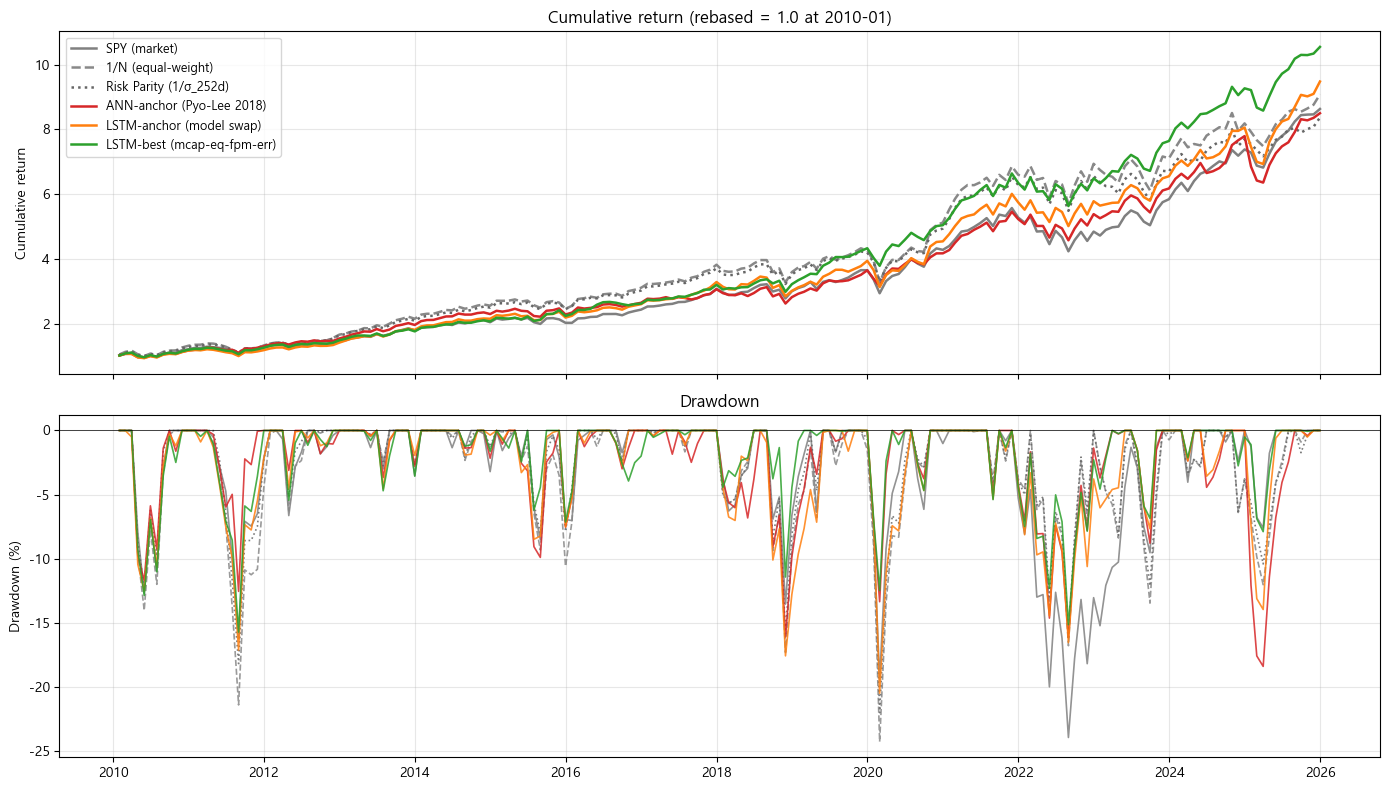

In [22]:
# ── [1b] Benchmark comparison — SPY, 1/N, Risk Parity ─────────
from pathlib import Path

CUTOFF_DT = pd.Timestamp('2025-12-31')

# anchor universe 추출 (월별 valid ticker)
_anchor_w = loaded['mat_mcap_mcap_fpm_pap']['weights']
# panel 에서 vol_252d, fwd_ret_1m 가져오기
_panel = pd.read_csv(DATA_DIR/'monthly_panel.csv', parse_dates=['date'])

def _build_naive_portfolio(weight_mode: str, tc: float = 0.002, max_w: float = 0.10):
    """
    weight_mode: '1N' or 'RP' (risk parity 1/σ_252d)
    universe: each month = anchor weights index 의 non-null ticker
    """
    rets, turns = [], []
    prev_w = None
    for dt in _anchor_w.index:
        if dt > CUTOFF_DT: continue
        # universe = anchor 의 weight 가 nan 이 아닌 종목
        anchor_row = _anchor_w.loc[dt].dropna()
        universe = anchor_row.index.tolist()
        if len(universe) < 20: continue
        # panel 에서 그 월 데이터
        p_row = _panel[(_panel['date']==dt) & (_panel['ticker'].isin(universe))]
        p_row = p_row.dropna(subset=['fwd_ret_1m'])
        if len(p_row) < 20: continue
        valid_tix = p_row['ticker'].tolist()
        ret_vec = p_row.set_index('ticker')['fwd_ret_1m']

        if weight_mode == '1N':
            n = len(valid_tix)
            w = pd.Series(1.0/n, index=valid_tix)
        elif weight_mode == 'RP':
            sig = p_row.set_index('ticker')['vol_252d'].replace(0, np.nan).dropna()
            valid_tix = sig.index.intersection(valid_tix).tolist()
            if len(valid_tix) < 20: continue
            inv = 1.0 / sig.loc[valid_tix]
            w = inv / inv.sum()
            ret_vec = ret_vec.reindex(valid_tix)
        # max weight cap (BL 와 동일)
        w = w.clip(upper=max_w)
        w = w / w.sum()
        # gross return
        ret_vec_aligned = ret_vec.reindex(w.index).fillna(0)
        gross = float((w * ret_vec_aligned).sum())
        # turnover
        if prev_w is not None:
            all_tix = w.index.union(prev_w.index)
            w_a = w.reindex(all_tix).fillna(0)
            pw_a = prev_w.reindex(all_tix).fillna(0)
            turn = float((w_a - pw_a).abs().sum())
        else:
            turn = 0.0
        net = gross - turn*tc
        rets.append((dt, net))
        turns.append((dt, turn))
        prev_w = w
    s = pd.Series({d:r for d,r in rets}).sort_index()
    return s

print('Computing 1/N and Risk Parity portfolios ...')
ret_1n = _build_naive_portfolio('1N')
ret_rp = _build_naive_portfolio('RP')
print(f'  1/N: {len(ret_1n)} months, mean={ret_1n.mean()*100:+.3f}%')
print(f'  RP : {len(ret_rp)} months, mean={ret_rp.mean()*100:+.3f}%')

# SPY return (anchor pkl 의 spy_ret)
ret_spy = loaded['mat_mcap_mcap_fpm_pap']['spy_ret'].dropna()

# BL 슬롯 return
BL_SLOTS = {
    'ANN-anchor (Pyo-Lee 2018)':      'mat_mcap_mcap_fpm_pap_ann',
    'LSTM-anchor (model swap)':       'mat_mcap_mcap_fpm_pap',
    'LSTM-best (mcap-eq-fpm-err)':   'mat_mcap_eq_fpm_pap',
}
def _bl_ret(name):
    return loaded[name]['ret'].dropna()

# Metric 계산 함수 (rf=0 가정, monthly)
PERIODS_B = [
    ('All', None, None),
    ('R1', '2010-01-01','2012-06-30'),
    ('R2', '2012-07-01','2019-12-31'),
    ('R3', '2020-01-01','2023-06-30'),
    ('R4', '2023-07-01','2025-12-31'),
]
def _metrics(s, st, et):
    r = s.dropna()
    if st: r = r[r.index>=st]
    if et: r = r[r.index<=et]
    if len(r)<6: return None
    rfa = rf.reindex(r.index).fillna(0)
    exc = r - rfa
    vol = r.std()*np.sqrt(12)
    sh  = float(exc.mean()*12/vol) if vol>0 else np.nan
    dn  = r[r<0].std()*np.sqrt(12)
    so  = float(exc.mean()*12/dn) if (dn and dn>0) else np.nan
    cum = (1+r).cumprod()
    mdd = float((cum/cum.cummax()-1).min())
    return dict(Sharpe=sh, Sortino=so, MDD=mdd)

# strategy 목록
STRATS = [
    ('SPY (market)',               ret_spy),
    ('1/N (equal-weight)',         ret_1n),
    ('Risk Parity (1/σ_252d)',     ret_rp),
] + [(lbl, _bl_ret(nm)) for lbl, nm in BL_SLOTS.items()]

# 표 출력
print('\n' + '='*100)
print('Benchmark comparison — Sharpe (Sortino) [MDD] × period')
print('='*100)
hdr = f'{"strategy":<32s}' + ''.join(f'{p:>14s}' for p,_,_ in PERIODS_B)
print(hdr); print('-'*len(hdr))
all_metrics = {}
for label, s in STRATS:
    row = []
    metrics_p = {}
    for p, st, et in PERIODS_B:
        m = _metrics(s, st, et)
        if m:
            row.append(f'{m["Sharpe"]:+.2f}({m["Sortino"]:+.2f})')
            metrics_p[p] = m
        else:
            row.append('       —     ')
    print(f'{label:<32s}' + ''.join(f'{c:>14s}' for c in row))
    all_metrics[label] = metrics_p

# MDD 별도 표
print('\n' + '='*100)
print('MDD (max drawdown) × period')
print('='*100)
print(hdr); print('-'*len(hdr))
for label, s in STRATS:
    row = []
    for p, st, et in PERIODS_B:
        m = all_metrics.get(label, {}).get(p)
        row.append(f'{m["MDD"]*100:+.2f}%' if m else '   —   ')
    print(f'{label:<32s}' + ''.join(f'{c:>14s}' for c in row))

# 누적수익률 + drawdown chart
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 8), sharex=True)
colors_map = {
    'SPY (market)':                'gray',
    '1/N (equal-weight)':          '#888888',
    'Risk Parity (1/σ_252d)':      '#666666',
    'ANN-anchor (Pyo-Lee 2018)':   '#d62728',
    'LSTM-anchor (model swap)':    '#ff7f0e',
    'LSTM-best (mcap-eq-fpm-err)': '#2ca02c',
}
linestyles = {
    'SPY (market)': '-',
    '1/N (equal-weight)': '--',
    'Risk Parity (1/σ_252d)': ':',
    'ANN-anchor (Pyo-Lee 2018)': '-',
    'LSTM-anchor (model swap)': '-',
    'LSTM-best (mcap-eq-fpm-err)': '-',
}
for label, s in STRATS:
    s2 = s[s.index<=CUTOFF_DT].dropna()
    if len(s2)<6: continue
    cum = (1+s2).cumprod()
    ax1.plot(cum.index, cum.values, lw=1.8, label=label,
              color=colors_map.get(label,'black'),
              linestyle=linestyles.get(label,'-'))
    dd = cum / cum.cummax() - 1
    ax2.plot(dd.index, dd.values*100, lw=1.2,
              color=colors_map.get(label,'black'),
              linestyle=linestyles.get(label,'-'),
              alpha=0.85)

ax1.set_title('Cumulative return (rebased = 1.0 at 2010-01)')
ax1.set_ylabel('Cumulative return')
ax1.legend(loc='upper left', fontsize=9)
ax1.grid(True, alpha=0.3)
ax2.set_title('Drawdown')
ax2.set_ylabel('Drawdown (%)')
ax2.grid(True, alpha=0.3)
ax2.axhline(0, color='black', lw=0.5)
plt.tight_layout()
plt.show()


## [1c] Benchmark comparison — 두 LSTM 슬롯 (defensive vs adaptive)

**목적**: §4.4 벤치마크 비교 — 단일 best slot 강요 대신 두 LSTM 옵션의 trade-off 제시

- **외부 baselines** (3): SPY, 1/N, Risk Parity (1/σ_252d)
- **BL portfolios** (4):
  - **ANN-anchor** (`mat_mcap_mcap_fpm_pap_ann`): Pyo-Lee 2018 원안
  - **LSTM-anchor** (`mat_mcap_mcap_fpm_pap`): 같은 slot, σ 모델만 LSTM 교체
  - **LSTM-defensive** (`mat_mcap_eq_lam_pap`): eq P + lam Q — q>0 보장, 저변동 정체성 유지
  - **LSTM-adaptive** (`mat_mcap_eq_fpm_pap`): eq P + fpm Q — peak Sharpe, regime 적응

**출력**: 6개 지표 표 (Sharpe/Sortino/MDD/AnnRet/CumRet/AnnVol) × 5 기간 (All/R1/R2/R3/R4)
+ 누적수익률(log) + Drawdown 2-panel 차트



Table 1: Sharpe ratio × period
strategy                                             All            R1            R2            R3            R4
----------------------------------------------------------------------------------------------------------------
SPY (market)                                      +0.925        +0.807        +1.227        +0.615        +1.192
1/N (equal-weight)                                +0.857        +0.785        +1.234        +0.701        +0.472
Risk Parity (1/σ_252d)                            +0.888        +0.909        +1.284        +0.671        +0.447
ANN-anchor (Pyo-Lee 2018)                         +0.945        +1.059        +1.076        +0.850        +0.712
Ensemble-anchor (σ 모델 교체)                         +0.946        +0.738        +1.287        +0.702        +0.940
Ensemble-defensive ($p^{eq}$, $q^{lam}$)          +1.067        +1.076        +1.320        +0.956        +0.638
Ensemble-defensive ($p^{rp}$, $q^{lam}$)          +1.042        

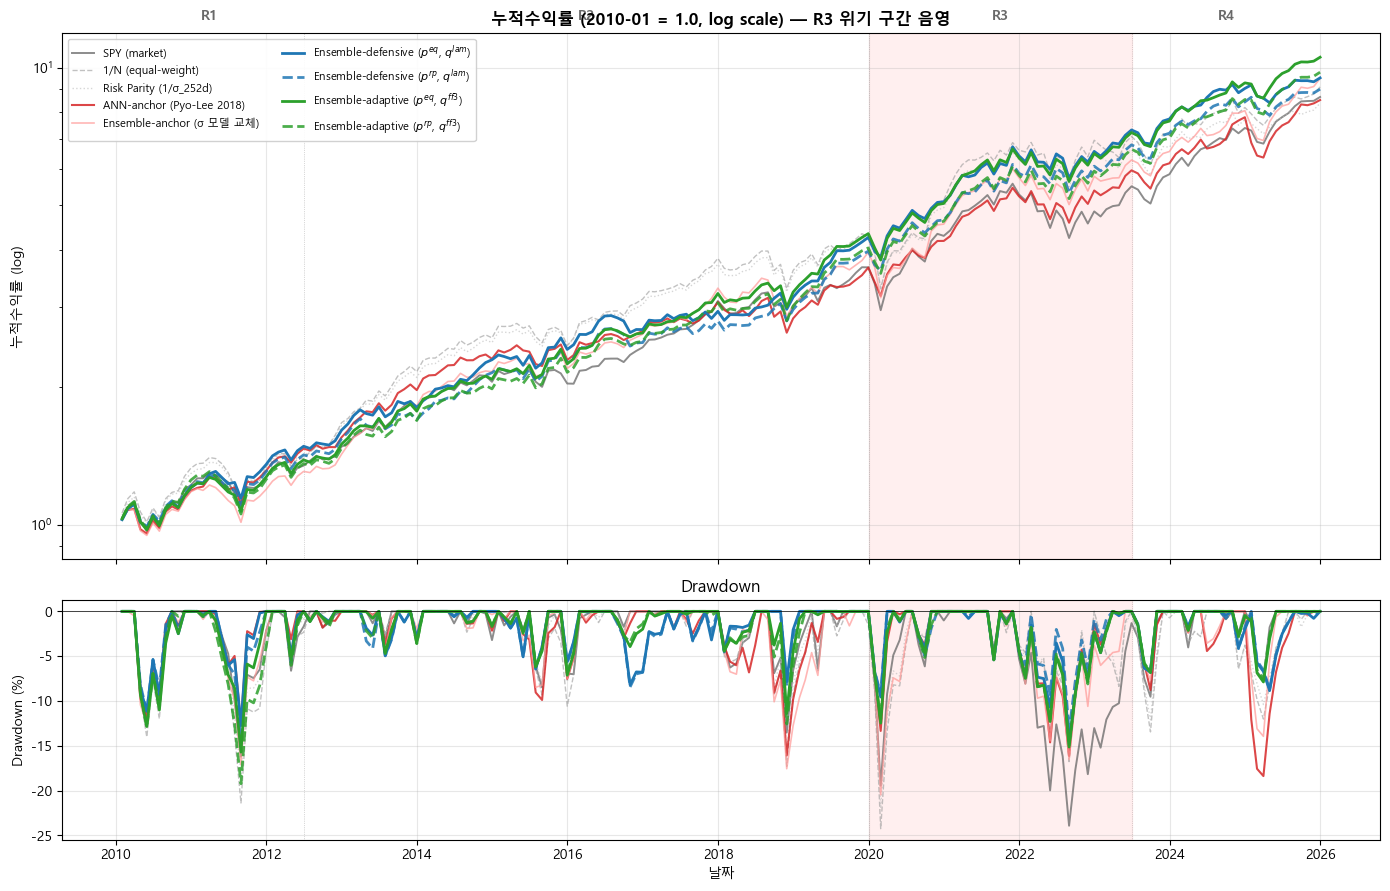

In [5]:
# ── [1c] Benchmark comparison — Ensemble defensive / adaptive + 다지표 표 + 누적수익률 그림 ───
# [1b] 인프라 재사용: loaded, rf, ret_spy, ret_1n, ret_rp
# 메시지: mcap P만 열위, EQ ≈ RP — prior choice는 P-Q 결합 대비 부차적

CUTOFF_DT = pd.Timestamp('2025-12-31')

BL_SLOTS_C = {
    'ANN-anchor (Pyo-Lee 2018)':           'mat_mcap_mcap_fpm_pap_ann',
    'Ensemble-anchor (σ 모델 교체)':         'mat_mcap_mcap_fpm_pap',
    'Ensemble-defensive ($p^{eq}$, $q^{lam}$)':    'mat_mcap_eq_lam_pap',
    'Ensemble-defensive ($p^{rp}$, $q^{lam}$)':    'mat_mcap_rp_lam_pap',
    'Ensemble-adaptive ($p^{eq}$, $q^{ff3}$)':     'mat_mcap_eq_fpm_pap',
    'Ensemble-adaptive ($p^{rp}$, $q^{ff3}$)':     'mat_mcap_rp_fpm_pap',
}

STRATS_C = [
    ('SPY (market)',               ret_spy),
    ('1/N (equal-weight)',         ret_1n),
    ('Risk Parity (1/σ_252d)',     ret_rp),
] + [(lbl, loaded[slot]['ret'].dropna()) for lbl, slot in BL_SLOTS_C.items()]

PERIODS_B = [
    ('All', None, None),
    ('R1', '2010-01-01','2012-06-30'),
    ('R2', '2012-07-01','2019-12-31'),
    ('R3', '2020-01-01','2023-06-30'),
    ('R4', '2023-07-01','2025-12-31'),
]

# 다지표 계산: AnnRet, AnnVol, Sharpe, Sortino, MDD, CumRet
def _full_metrics(s, st, et):
    r = s.dropna()
    if st: r = r[r.index >= st]
    if et: r = r[r.index <= et]
    if len(r) < 6: return None
    rfa = rf.reindex(r.index).fillna(0)
    exc = r - rfa
    ann_ret = (1+r).prod() ** (12/len(r)) - 1
    ann_vol = r.std() * np.sqrt(12)
    sh = float(exc.mean()*12/ann_vol) if ann_vol > 0 else np.nan
    dn = r[r<0].std() * np.sqrt(12)
    so = float(exc.mean()*12/dn) if (dn and dn>0) else np.nan
    cum = (1+r).cumprod()
    mdd = float((cum/cum.cummax() - 1).min())
    cum_ret = float(cum.iloc[-1] - 1)
    return dict(AnnRet=ann_ret, AnnVol=ann_vol, Sharpe=sh, Sortino=so, MDD=mdd, CumRet=cum_ret)

# 전략 × 기간 다지표 dict
metrics_data = {}
for label, s in STRATS_C:
    metrics_data[label] = {}
    for p, st, et in PERIODS_B:
        m = _full_metrics(s, st, et)
        if m: metrics_data[label][p] = m

# ───── 표 출력 (지표별) ─────
def _print_metric_table(title, key, fmt):
    print('\n' + '='*120)
    print(title)
    print('='*120)
    hdr = f'{"strategy":<42s}' + ''.join(f'{p:>14s}' for p,_,_ in PERIODS_B)
    print(hdr); print('-'*len(hdr))
    for label in metrics_data:
        row = []
        for p,_,_ in PERIODS_B:
            m = metrics_data[label].get(p)
            row.append(fmt(m[key]) if m else '   —   ')
        print(f'{label:<42s}' + ''.join(f'{c:>14s}' for c in row))

_print_metric_table('Table 1: Sharpe ratio × period',         'Sharpe',  lambda v: f'{v:+.3f}')
_print_metric_table('Table 2: Sortino ratio × period',        'Sortino', lambda v: f'{v:+.3f}')
_print_metric_table('Table 3: MDD (max drawdown) × period',   'MDD',     lambda v: f'{v*100:+.2f}%')
_print_metric_table('Table 4: Annualized return × period',    'AnnRet',  lambda v: f'{v*100:+.2f}%')
_print_metric_table('Table 5: Cumulative return × period',    'CumRet',  lambda v: f'{v*100:+.1f}%')
_print_metric_table('Table 6: Annualized volatility × period','AnnVol',  lambda v: f'{v*100:.2f}%')

# ───── 그림: 누적 수익률 (log scale) + Drawdown ─────
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 9), sharex=True,
                                gridspec_kw={'height_ratios': [2.2, 1]})

# 색상: 같은 전략 family는 같은 hue, P matrix 차이는 linestyle(EQ solid, RP dashed)로 표시
style_map = {
    'SPY (market)':                       {'color':'#666666', 'ls':'-',  'lw':1.4, 'alpha':0.75},
    '1/N (equal-weight)':                 {'color':'#999999', 'ls':'--', 'lw':1.0, 'alpha':0.6},
    'Risk Parity (1/σ_252d)':             {'color':'#bbbbbb', 'ls':':',  'lw':1.0, 'alpha':0.6},
    'ANN-anchor (Pyo-Lee 2018)':          {'color':'#d62728', 'ls':'-',  'lw':1.5, 'alpha':0.85},
    'Ensemble-anchor (σ 모델 교체)':       {'color':'#ff9896', 'ls':'-',  'lw':1.2, 'alpha':0.7},
    'Ensemble-defensive ($p^{eq}$, $q^{lam}$)':   {'color':'#1f77b4', 'ls':'-',  'lw':2.0, 'alpha':1.0},
    'Ensemble-defensive ($p^{rp}$, $q^{lam}$)':   {'color':'#1f77b4', 'ls':'--', 'lw':2.0, 'alpha':0.85},
    'Ensemble-adaptive ($p^{eq}$, $q^{ff3}$)':    {'color':'#2ca02c', 'ls':'-',  'lw':2.0, 'alpha':1.0},
    'Ensemble-adaptive ($p^{rp}$, $q^{ff3}$)':    {'color':'#2ca02c', 'ls':'--', 'lw':2.0, 'alpha':0.85},
}

REGIME_BOUNDS = [
    ('R1', pd.Timestamp('2010-01-01'), pd.Timestamp('2012-06-30')),
    ('R2', pd.Timestamp('2012-07-01'), pd.Timestamp('2019-12-31')),
    ('R3', pd.Timestamp('2020-01-01'), pd.Timestamp('2023-06-30')),
    ('R4', pd.Timestamp('2023-07-01'), pd.Timestamp('2025-12-31')),
]

# R3 음영
ax1.axvspan(pd.Timestamp('2020-01-01'), pd.Timestamp('2023-06-30'),
            color='#ffe0e0', alpha=0.5, zorder=0, label='_nolegend_')
ax2.axvspan(pd.Timestamp('2020-01-01'), pd.Timestamp('2023-06-30'),
            color='#ffe0e0', alpha=0.5, zorder=0)

# 라인 플롯
for label, s in STRATS_C:
    s2 = s[s.index <= CUTOFF_DT].dropna()
    if len(s2) < 6: continue
    cum = (1+s2).cumprod()
    style = style_map.get(label, {'color':'black','ls':'-','lw':1.0,'alpha':0.7})
    ax1.plot(cum.index, cum.values, label=label, **style)
    dd = cum / cum.cummax() - 1
    ax2.plot(dd.index, dd.values*100, **style)

# 레짐 경계 vline + 라벨
for lbl, st, et in REGIME_BOUNDS[1:]:
    ax1.axvline(st, color='gray', ls=':', lw=0.5, alpha=0.6)
    ax2.axvline(st, color='gray', ls=':', lw=0.5, alpha=0.6)
for lbl, st, et in REGIME_BOUNDS:
    mid = st + (et - st)/2
    ax1.text(mid, 1.02, lbl, transform=ax1.get_xaxis_transform(),
             ha='center', va='bottom', fontsize=10, fontweight='bold', color='dimgray')

ax1.set_title('누적수익률 (2010-01 = 1.0, log scale) — R3 위기 구간 음영', fontweight='bold')
ax1.set_ylabel('누적수익률 (log)')
ax1.set_yscale('log')
ax1.legend(loc='upper left', fontsize=8, ncol=2, framealpha=0.9)
ax1.grid(True, alpha=0.3)

ax2.set_title('Drawdown')
ax2.set_ylabel('Drawdown (%)')
ax2.set_xlabel('날짜')
ax2.axhline(0, color='black', lw=0.5)
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


## [2] 1-step variation × (전체 + 4 레짐) 통합 표

**Anchor (Pyo & Lee 2018)**: `mat_mcap_mcap_fpm_pap` (prior=mcap, p_w=mcap, q=fpm, Ω=err)

Anchor 에서 한 component 만 변경:

- **SET 1 (Q only)**: prior=mcap, p_w=mcap 고정 → q ∈ {lam, raw, inv, vsp, fpm★}
- **SET 2 (P only)**: prior=mcap, q=fpm 고정 → p_w ∈ {mcap★, eq, rp}
- **SET 3 (Prior only)**: p_w=mcap, q=fpm 고정 → prior ∈ {mcap★, eq, rp}
- **SET 4 (Omega only)**: prior=mcap, p_w=mcap, q=fpm 고정 → Ω ∈ {err★, he}

총 13 pair (★ = anchor). 

**표 구성**: 한 표에 (All + R1/R2/R3/R4) × (LSTM | ANN | Δ) 통합. 슬롯별 전체 claim 강도와 regime transmission 한눈에 비교.

- 표 1: Sharpe (risk-adjusted return)
- 표 2: Sortino (downside risk-adjusted)
- 표 3: MDD (maximum drawdown, negative; Δ > 0 = LSTM 덜 빠짐)
- 셀 색상: Δ > 0 green / Δ < 0 red (Sharpe, Sortino, MDD 모두 동일 — LSTM 우위 = green)

**Regime 길이**: R1 30mo, R2 90mo, R3 42mo, R4 30mo


In [10]:
# ── [1] 1-step variation × (All + R1/R2/R3/R4) 통합 표 ─────────────
from IPython.display import display


def _calc_metrics(name, start=None, end=None):
    """Sharpe, Sortino, MDD 계산. 기간 미지정 시 전체."""
    if name not in loaded: return None
    ret = loaded[name].get('ret')
    if not isinstance(ret, pd.Series): return None
    r = ret.dropna()
    r = r[r.index <= CUTOFF]
    if start is not None: r = r[r.index >= start]
    if end is not None:   r = r[r.index <= end]
    if len(r) < 6: return None
    rfa = rf.reindex(r.index).fillna(0)
    exc = r - rfa
    vol = r.std() * np.sqrt(12)
    sh  = float(exc.mean() * 12 / vol) if vol > 0 else np.nan
    dn  = r[r < 0].std() * np.sqrt(12)
    so  = float(exc.mean() * 12 / dn) if (dn and dn > 0) else np.nan
    cum = (1 + r).cumprod()
    mdd = float((cum / cum.cummax() - 1).min())
    return dict(Sharpe=sh, Sortino=so, MDD=mdd)


SETS = {
    'SET 1: Q (prior=mcap, p_w=mcap)': [
        ('q=lam',        'mat_mcap_mcap_lam_pap', 'mat_mcap_mcap_lam_pap_ann'),
        ('q=raw',        'mat_mcap_mcap_raw_pap', 'mat_mcap_mcap_raw_pap_ann'),
        ('q=inv',        'mat_mcap_mcap_inv_pap', 'mat_mcap_mcap_inv_pap_ann'),
        ('q=vsp',        'mat_mcap_mcap_vsp_pap', 'mat_mcap_mcap_vsp_pap_ann'),
        ('q=fpm ★',      ANCHOR_L,                ANCHOR_A),
    ],
    'SET 2: P (prior=mcap, q=fpm)': [
        ('p_w=mcap ★',   ANCHOR_L,              ANCHOR_A),
        ('p_w=eq',       'mat_mcap_eq_fpm_pap', 'mat_mcap_eq_fpm_pap_ann'),
        ('p_w=rp',       'mat_mcap_rp_fpm_pap', 'mat_mcap_rp_fpm_pap_ann'),
    ],
    'SET 3: Prior (p_w=mcap, q=fpm)': [
        ('prior=mcap ★', ANCHOR_L,              ANCHOR_A),
        ('prior=eq',     'mat_eq_mcap_fpm_pap', 'mat_eq_mcap_fpm_pap_ann'),
        ('prior=rp',     'mat_rp_mcap_fpm_pap', 'mat_rp_mcap_fpm_pap_ann'),
    ],
    'SET 4: Omega (prior=mcap, p_w=mcap, q=fpm)': [
        ('omega=err ★',  ANCHOR_L,               ANCHOR_A),
        ('omega=he',     'mat_mcap_mcap_fpm_he', 'mat_mcap_mcap_fpm_he_ann'),
    ],
}

PERIODS = [
    ('All', None,         None),
    ('R1',  '2010-01-01', '2012-06-30'),
    ('R2',  '2012-07-01', '2019-12-31'),
    ('R3',  '2020-01-01', '2023-06-30'),
    ('R4',  '2023-07-01', '2025-12-31'),
]

# 모든 슬롯 × 모든 기간 metric 수집
rows_idx, data_sh, data_so, data_md = [], [], [], []
for set_name, pairs in SETS.items():
    set_id = set_name.split(':')[0]   # 'SET 1' ...
    for label, L_name, A_name in pairs:
        rows_idx.append((set_id, label))
        row_sh, row_so, row_md = [], [], []
        for plbl, s, e in PERIODS:
            mL = _calc_metrics(L_name, s, e)
            mA = _calc_metrics(A_name, s, e)
            if mL and mA:
                row_sh.extend([mL['Sharpe'],  mA['Sharpe'],  mL['Sharpe']-mA['Sharpe']])
                row_so.extend([mL['Sortino'], mA['Sortino'], mL['Sortino']-mA['Sortino']])
                row_md.extend([mL['MDD'],     mA['MDD'],     mL['MDD']-mA['MDD']])
            else:
                row_sh.extend([np.nan]*3); row_so.extend([np.nan]*3); row_md.extend([np.nan]*3)
        data_sh.append(row_sh); data_so.append(row_so); data_md.append(row_md)

cols  = pd.MultiIndex.from_product(
            [[p for p,_,_ in PERIODS], ['L','A','Δ']], names=['period','col'])
idx   = pd.MultiIndex.from_tuples(rows_idx, names=['SET','pair'])
df_sh = pd.DataFrame(data_sh, index=idx, columns=cols)
df_so = pd.DataFrame(data_so, index=idx, columns=cols)
df_md = pd.DataFrame(data_md, index=idx, columns=cols)

period_lbls = [p for p,_,_ in PERIODS]

# ── (1) SET × 기간 LSTM 우위 카운트 (Sharpe) ────────────────────
print('='*70)
print('LSTM 우위 카운트 (Sharpe Δ > 0)')
print('='*70)
hdr = f'{"":<10s}' + ''.join(f'{p:>10s}' for p in period_lbls)
print(hdr); print('-'*len(hdr))
for set_id in ['SET 1','SET 2','SET 3','SET 4']:
    sub = df_sh.loc[set_id]; n_pair = len(sub)
    cells = [f'{int((sub[(p,"Δ")] > 0).sum())}/{n_pair}' for p in period_lbls]
    print(f'{set_id:<10s}' + ''.join(f'{c:>10s}' for c in cells))
print('-'*len(hdr))
totals = [f'{int((df_sh[(p,"Δ")] > 0).sum())}/{len(df_sh)}' for p in period_lbls]
print(f'{"합계":<8s}' + ''.join(f'{c:>10s}' for c in totals))

# 기간별 binomial p-value (one-sided)
print('\n기간별 binomial p-value (H0: p=0.5, one-sided)')
n = len(df_sh)
for p in period_lbls:
    w  = int((df_sh[(p,'Δ')] > 0).sum())
    pv = sum(math.comb(n,k) * 0.5**n for k in range(w, n+1))
    print(f'  {p:>4s}: LSTM win={w}/{n}, p={pv:.3f}')
print('='*70)

# ── (2) SET × 기간 평균 Δ (Sharpe / Sortino / MDD) ───────────────
hdr = f'{"":<10s}' + ''.join(f'{p:>11s}' for p in period_lbls)
for metric_name, df_m, fmt_str in [('Sharpe',  df_sh, '+.3f'),
                                    ('Sortino', df_so, '+.3f'),
                                    ('MDD',     df_md, '+.2%')]:
    print(f'\n평균 Δ_{metric_name} (SET × 기간)')
    print(hdr); print('-'*len(hdr))
    for set_id in ['SET 1','SET 2','SET 3','SET 4']:
        sub = df_m.loc[set_id]
        cells = [f'{sub[(p,"Δ")].mean():{fmt_str}}' for p in period_lbls]
        print(f'{set_id:<10s}' + ''.join(f'{c:>11s}' for c in cells))

# ── (3) 통합 표 (Sharpe + Sortino + MDD) ─────────────────────────
def _hl(v):
    if not isinstance(v, (int, float)) or pd.isna(v): return ''
    if v > 0: return 'background-color: #b8e0b8; color: black; font-weight: bold'
    if v < 0: return 'background-color: #f4b6b6; color: black; font-weight: bold'
    return ''

delta_cols = [(p,'Δ') for p in period_lbls]
fmt_ratio  = {col: ('{:+.3f}' if col[1]=='Δ' else '{:.3f}') for col in df_sh.columns}
fmt_pct    = {col: ('{:+.2%}' if col[1]=='Δ' else '{:.2%}') for col in df_md.columns}

print('\n[표 1] Sharpe (LSTM | ANN | Δ) × (All + R1-R4)')
display(df_sh.style.format(fmt_ratio).map(_hl, subset=delta_cols))

print('\n[표 2] Sortino (LSTM | ANN | Δ) × (All + R1-R4)')
display(df_so.style.format(fmt_ratio).map(_hl, subset=delta_cols))

print('\n[표 3] MDD (LSTM | ANN | Δ) × (All + R1-R4)  ← Δ>0 = LSTM 덜 빠짐')
df_md.style.format(fmt_pct).map(_hl, subset=delta_cols)


LSTM 우위 카운트 (Sharpe Δ > 0)
                 All        R1        R2        R3        R4
------------------------------------------------------------
SET 1            3/5       0/5       2/5       4/5       3/5
SET 2            3/3       0/3       3/3       2/3       3/3
SET 3            3/3       0/3       3/3       0/3       3/3
SET 4            1/2       0/2       2/2       0/2       1/2
------------------------------------------------------------
합계           10/13      0/13     10/13      6/13     10/13

기간별 binomial p-value (H0: p=0.5, one-sided)
   All: LSTM win=10/13, p=0.046
    R1: LSTM win=0/13, p=1.000
    R2: LSTM win=10/13, p=0.046
    R3: LSTM win=6/13, p=0.709
    R4: LSTM win=10/13, p=0.046

평균 Δ_Sharpe (SET × 기간)
                  All         R1         R2         R3         R4
-----------------------------------------------------------------
SET 1          -0.007     -0.232     -0.057     +0.188     +0.035
SET 2          +0.045     -0.159     +0.086     +0.063     +0.


[표 2] Sortino (LSTM | ANN | Δ) × (All + R1-R4)



[표 3] MDD (LSTM | ANN | Δ) × (All + R1-R4)  ← Δ>0 = LSTM 덜 빠짐


### [2] 해석 요약

1. **P 행렬 (mcap → eq, rp) — 큰 폭 상승**
   LSTM/ANN 모두 절대 Sharpe/Sortino 가 크게 상승. p_w 를 동일가중 (eq) 또는 위험가중 (rp) 으로 두면 portfolio 분산 효과 강화 → market-cap 집중 완화. SET 2 LSTM win 3/3 (All).

2. **Q (양수 view) — 금융위기 포함 레짐 (R3) 좋은 성능**
   R3 에서 SET 1 (Q 변화) mean Δ_Sharpe **+0.188** (전 SET 중 최대), LSTM win **4/5**.

3. **R1 (회복) 일관적 LSTM 약세**
   4 SET 모두 R1 LSTM win **0/n**, 합계 **0/13**, p=1.000.

4. **Prior 방향성 부재**
   prior ∈ {mcap, eq, rp} 변화는 일관된 LSTM 우위 패턴 없음. SET 3 는 All 3/3 이지만 R1=0/3, R2=3/3, R3=0/3, R4=3/3 으로 레짐별 부호 반전. Q의 fpm의 설정 부호와 동일한 것으로 보아, prior 보다는 Q와 P의 영향이 클 것으로 예상.

5. **Omega: err > He (1999)**
   대부분 슬롯에서 ω=err (realized-error: 직전월 view 예측오차 제곱) 이 ω=he 보다 좋은 절대 성능.


## [3] P 행렬 변경 (mcap, eq, rp) × 모든 슬롯 grid

**목적**: P 행렬 가중 (p_w) 을 mcap → eq → rp 로 바꿨을 때, 다른 차원 (prior, q) 의 모든 조합에서 LSTM 우위가 robust 한가?

**Grid** (45 슬롯):
- p_w ∈ {mcap, eq, rp}
- prior ∈ {mcap, eq, rp}
- q ∈ {lam, raw, inv, vsp, fpm} (fix 제외)
- omega=err 고정 (he 제거 — [2] 에서 err > he 확인됨)

전체 (All) + R1/R2/R3/R4 레짐별 Sharpe (LSTM | ANN | Δ).

**색상 규칙**: Δ > 0 (LSTM 우위) green / Δ < 0 (ANN 우위) red


In [11]:
# ── [3] P 행렬 × 모든 슬롯 grid (45 슬롯, omega=err) ───────────────
from IPython.display import display

# 차원
PRIORS    = ['mcap', 'eq', 'rp']
P_WEIGHTS = ['mcap', 'eq', 'rp']
Q_MODES   = ['lam', 'raw', 'inv', 'vsp', 'fpm']
OMEGA     = 'pap'   # 고정

# 45 슬롯 (p_w 외곽, mcap→eq→rp 순서)
slots = [(pw, pr, q)
         for pw in P_WEIGHTS
         for pr in PRIORS
         for q  in Q_MODES]

# 각 슬롯 × 기간 metric (Sharpe / Sortino / MDD)
rows_idx, data_sh, data_so, data_md = [], [], [], []
missing = []
for pw, pr, q in slots:
    L_name = f'mat_{pr}_{pw}_{q}_{OMEGA}'
    A_name = L_name + '_ann'
    if L_name not in loaded or A_name not in loaded:
        missing.append(L_name); continue
    rows_idx.append((pw, pr, q))
    row_sh, row_so, row_md = [], [], []
    for plbl, s, e in PERIODS:
        mL = _calc_metrics(L_name, s, e)
        mA = _calc_metrics(A_name, s, e)
        if mL and mA:
            row_sh.extend([mL['Sharpe'],  mA['Sharpe'],  mL['Sharpe']-mA['Sharpe']])
            row_so.extend([mL['Sortino'], mA['Sortino'], mL['Sortino']-mA['Sortino']])
            row_md.extend([mL['MDD'],     mA['MDD'],     mL['MDD']-mA['MDD']])
        else:
            row_sh.extend([np.nan]*3); row_so.extend([np.nan]*3); row_md.extend([np.nan]*3)
    data_sh.append(row_sh); data_so.append(row_so); data_md.append(row_md)

if missing:
    print(f'missing {len(missing)}: {missing[:5]} ...')
print(f'슬롯 수: {len(rows_idx)} (예상 45)')

cols_p = pd.MultiIndex.from_product(
            [[p for p,_,_ in PERIODS], ['L','A','Δ']], names=['period','col'])
idx_p  = pd.MultiIndex.from_tuples(rows_idx, names=['p_w','prior','q'])
df_p_sh = pd.DataFrame(data_sh, index=idx_p, columns=cols_p)
df_p_so = pd.DataFrame(data_so, index=idx_p, columns=cols_p)
df_p_md = pd.DataFrame(data_md, index=idx_p, columns=cols_p)
# 순서 유지 (mcap, eq, rp) — sort_index 호출 X

period_lbls = [p for p,_,_ in PERIODS]

# ── (1) p_w × 기간 LSTM 우위 카운트 (Sharpe / Sortino / MDD) ─────
print('\n' + '='*70)
print('P 행렬 × 기간 LSTM 우위 카운트 (Δ > 0)')
print('='*70)
hdr = f'{"":<14s}' + ''.join(f'{p:>10s}' for p in period_lbls)
for metric_name, df_m in [('Sharpe', df_p_sh), ('Sortino', df_p_so), ('MDD', df_p_md)]:
    print(f'\n[{metric_name}]')
    print(hdr); print('-'*len(hdr))
    for pw in P_WEIGHTS:
        sub = df_m.loc[pw]; n_pair = len(sub)
        cells = [f'{int((sub[(p,"Δ")] > 0).sum())}/{n_pair}' for p in period_lbls]
        print(f'p_w={pw:<10s}' + ''.join(f'{c:>10s}' for c in cells))
    totals = [f'{int((df_m[(p,"Δ")] > 0).sum())}/{len(df_m)}' for p in period_lbls]
    print(f'{"합계":<12s}' + ''.join(f'{c:>10s}' for c in totals))

# ── (2) p_w × 기간 평균 절대값 (LSTM | ANN) ─────────────────────
print('\n' + '='*86)
print('평균 절대값 (p_w × 기간) — LSTM | ANN')
print('='*86)
for metric_name, df_m, fmt_v in [('Sharpe',  df_p_sh, '5.3f'),
                                  ('Sortino', df_p_so, '5.3f'),
                                  ('MDD',     df_p_md, '6.2%')]:
    print(f'\n[{metric_name}]')
    hdr2 = f'{"":<14s}' + ''.join(f'{p:>16s}' for p in period_lbls)
    print(hdr2); print('-'*len(hdr2))
    for pw in P_WEIGHTS:
        sub = df_m.loc[pw]
        cells = []
        for p in period_lbls:
            mL = sub[(p,'L')].mean()
            mA = sub[(p,'A')].mean()
            cells.append(f'{mL:>{fmt_v}}|{mA:{fmt_v}}')
        print(f'p_w={pw:<10s}' + ''.join(f'{c:>16s}' for c in cells))

# ── (3) p_w × 기간 평균 Δ ───────────────────────────────────────
print('\n' + '='*70)
print('평균 Δ (p_w × 기간) — + = LSTM 우위 (MDD: Δ>0 = LSTM 덜 빠짐)')
print('='*70)
for metric_name, df_m, fmt_d in [('Sharpe',  df_p_sh, '+.3f'),
                                  ('Sortino', df_p_so, '+.3f'),
                                  ('MDD',     df_p_md, '+.2%')]:
    print(f'\n[{metric_name}]')
    hdr3 = f'{"":<14s}' + ''.join(f'{p:>11s}' for p in period_lbls)
    print(hdr3); print('-'*len(hdr3))
    for pw in P_WEIGHTS:
        sub = df_m.loc[pw]
        cells = [f'{sub[(p,"Δ")].mean():{fmt_d}}' for p in period_lbls]
        print(f'p_w={pw:<10s}' + ''.join(f'{c:>11s}' for c in cells))

# ── (4) Full grid 통합 표 (3 metric) ────────────────────────────
def _hl(v):
    if not isinstance(v, (int, float)) or pd.isna(v): return ''
    if v > 0: return 'background-color: #b8e0b8; color: black; font-weight: bold'
    if v < 0: return 'background-color: #f4b6b6; color: black; font-weight: bold'
    return ''

delta_cols_p = [(p,'Δ') for p in period_lbls]
fmt_ratio    = {col: ('{:+.3f}' if col[1]=='Δ' else '{:.3f}') for col in df_p_sh.columns}
fmt_pct      = {col: ('{:+.2%}' if col[1]=='Δ' else '{:.2%}') for col in df_p_md.columns}

print('\n[표 1] Sharpe (LSTM | ANN | Δ) × (All + R1-R4) — 45 슬롯')
display(df_p_sh.style.format(fmt_ratio).map(_hl, subset=delta_cols_p))

print('\n[표 2] Sortino (LSTM | ANN | Δ) × (All + R1-R4) — 45 슬롯')
display(df_p_so.style.format(fmt_ratio).map(_hl, subset=delta_cols_p))

print('\n[표 3] MDD (LSTM | ANN | Δ) × (All + R1-R4) — 45 슬롯  ← Δ>0 = LSTM 덜 빠짐')
df_p_md.style.format(fmt_pct).map(_hl, subset=delta_cols_p)


슬롯 수: 45 (예상 45)

P 행렬 × 기간 LSTM 우위 카운트 (Δ > 0)

[Sharpe]
                     All        R1        R2        R3        R4
----------------------------------------------------------------
p_w=mcap            5/15      0/15      5/15     12/15      7/15
p_w=eq             15/15      1/15      5/15     15/15     15/15
p_w=rp             15/15     14/15      9/15     15/15     15/15
합계               35/45     15/45     19/45     42/45     37/45

[Sortino]
                     All        R1        R2        R3        R4
----------------------------------------------------------------
p_w=mcap            4/15      0/15      3/15     12/15     10/15
p_w=eq             15/15     12/15      3/15     15/15     15/15
p_w=rp             15/15     15/15      7/15     15/15     15/15
합계               34/45     27/45     13/45     42/45     40/45

[MDD]
                     All        R1        R2        R3        R4
----------------------------------------------------------------
p_w=mcap          


[표 2] Sortino (LSTM | ANN | Δ) × (All + R1-R4) — 45 슬롯



[표 3] MDD (LSTM | ANN | Δ) × (All + R1-R4) — 45 슬롯  ← Δ>0 = LSTM 덜 빠짐


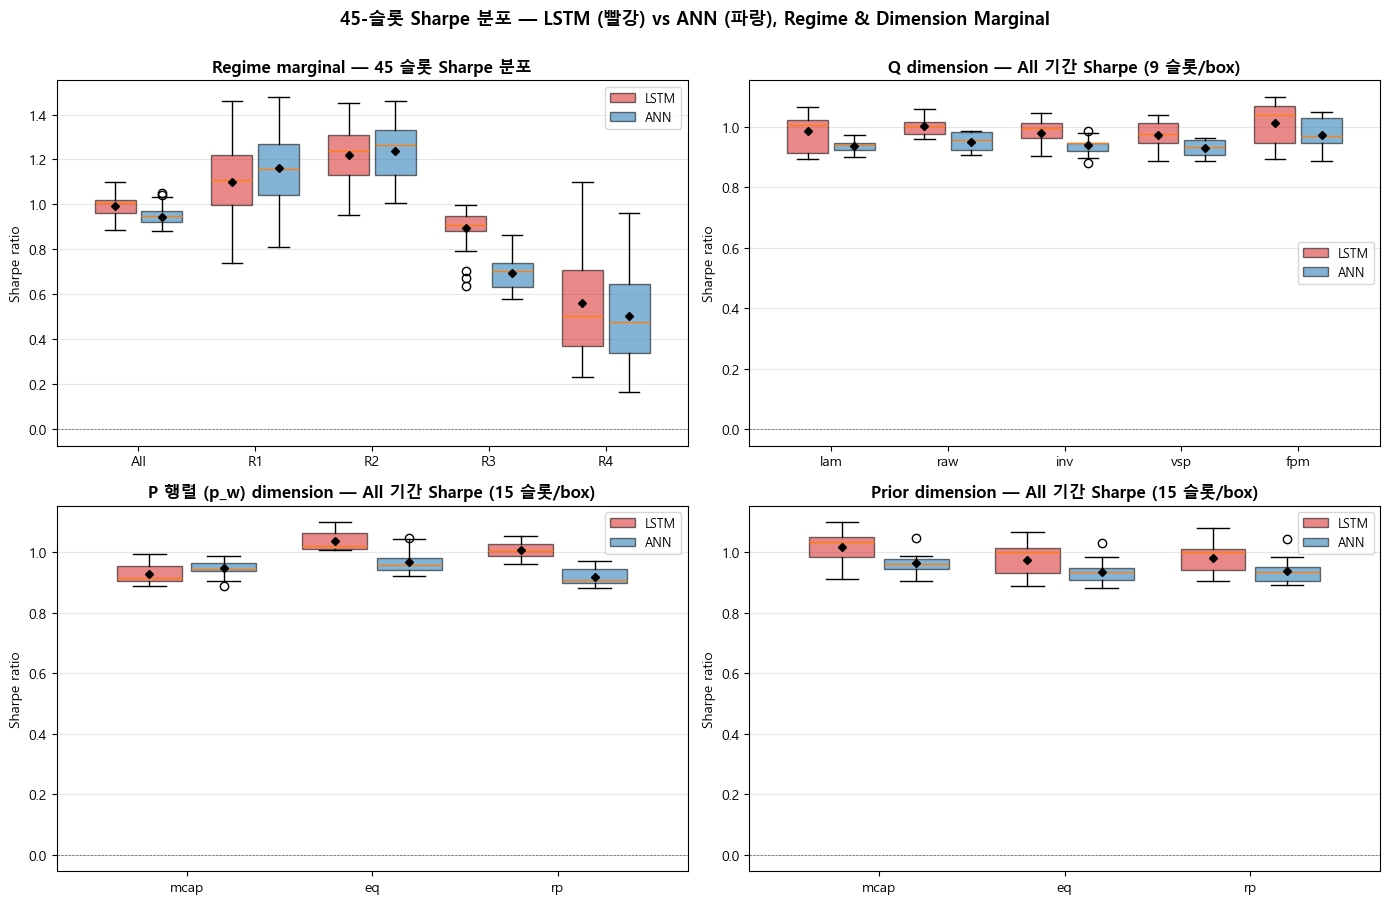

Regime별 mean Sharpe (45 슬롯 평균)
  period       LSTM mean    ANN mean    Δ mean    LSTM win
  ------------------------------------------------------
  All              0.992       0.946    +0.046   35/45   
  R1               1.102       1.162    -0.060   15/45   
  R2               1.218       1.237    -0.018   19/45   
  R3               0.896       0.696    +0.200   42/45   
  R4               0.560       0.503    +0.057   37/45   
Dimension marginal (All 기간) mean Sharpe
[Q]
  value      LSTM mean    ANN mean    Δ mean
  ------------------------------------------
  lam            0.985       0.936    +0.049
  raw            1.003       0.951    +0.052
  inv            0.981       0.939    +0.042
  vsp            0.974       0.930    +0.044
  fpm            1.014       0.973    +0.041
[P (p_w)]
  value      LSTM mean    ANN mean    Δ mean
  ------------------------------------------
  mcap           0.929       0.948    -0.019
  eq             1.038       0.970    +0.068
  rp          

In [12]:
# ── [3c] 45-슬롯 Sharpe 분포 — LSTM vs ANN, regime & dimension marginal ──
# §5.3 메인 figure: 슬롯 구성에 따른 LSTM/ANN 절대 Sharpe 및 갭을 한 장으로

_periods = list(dict.fromkeys(df_p_sh.columns.get_level_values("period")))

def _paired_box(ax, categories, data_L, data_A, title, ylabel="Sharpe ratio"):
    """category 별로 LSTM (붉은) / ANN (파랑) 박스를 side-by-side 로 그림."""
    n = len(categories)
    pos = np.arange(n)
    bpL = ax.boxplot(data_L, positions=pos - 0.2, widths=0.35, patch_artist=True,
                      showmeans=True, meanprops=dict(marker="D", markerfacecolor="black",
                      markeredgecolor="black", markersize=4))
    bpA = ax.boxplot(data_A, positions=pos + 0.2, widths=0.35, patch_artist=True,
                      showmeans=True, meanprops=dict(marker="D", markerfacecolor="black",
                      markeredgecolor="black", markersize=4))
    for patch in bpL["boxes"]: patch.set_facecolor("#d62728"); patch.set_alpha(0.55)
    for patch in bpA["boxes"]: patch.set_facecolor("#1f77b4"); patch.set_alpha(0.55)
    ax.set_xticks(pos); ax.set_xticklabels(categories)
    ax.axhline(0, color="black", lw=0.5, ls="--", alpha=0.6)
    ax.set_title(title, fontweight="bold")
    ax.set_ylabel(ylabel)
    ax.grid(True, alpha=0.3, axis="y")
    ax.legend([bpL["boxes"][0], bpA["boxes"][0]], ["LSTM", "ANN"], loc="best", fontsize=9)

fig, axes = plt.subplots(2, 2, figsize=(14, 9))

# ── (1) Regime marginal ──
data_L_r = [df_p_sh[(p, "L")].dropna().values for p in _periods]
data_A_r = [df_p_sh[(p, "A")].dropna().values for p in _periods]
_paired_box(axes[0, 0], _periods, data_L_r, data_A_r,
            "Regime marginal — 45 슬롯 Sharpe 분포")

# ── (2) Q dimension marginal (All 기준) ──
all_L = df_p_sh[("All", "L")]; all_A = df_p_sh[("All", "A")]
data_L_q = [all_L.xs(q, level="q").dropna().values for q in Q_MODES]
data_A_q = [all_A.xs(q, level="q").dropna().values for q in Q_MODES]
_paired_box(axes[0, 1], Q_MODES, data_L_q, data_A_q,
            "Q dimension — All 기간 Sharpe (9 슬롯/box)")

# ── (3) P (p_w) dimension marginal ──
data_L_p = [all_L.xs(pw, level="p_w").dropna().values for pw in P_WEIGHTS]
data_A_p = [all_A.xs(pw, level="p_w").dropna().values for pw in P_WEIGHTS]
_paired_box(axes[1, 0], P_WEIGHTS, data_L_p, data_A_p,
            "P 행렬 (p_w) dimension — All 기간 Sharpe (15 슬롯/box)")

# ── (4) Prior dimension marginal ──
data_L_pr = [all_L.xs(pr, level="prior").dropna().values for pr in PRIORS]
data_A_pr = [all_A.xs(pr, level="prior").dropna().values for pr in PRIORS]
_paired_box(axes[1, 1], PRIORS, data_L_pr, data_A_pr,
            "Prior dimension — All 기간 Sharpe (15 슬롯/box)")

plt.suptitle("45-슬롯 Sharpe 분포 — LSTM (빨강) vs ANN (파랑), Regime & Dimension Marginal",
             fontsize=13, fontweight="bold", y=1.00)
plt.tight_layout()
plt.show()

# 콘솔 요약
print("="*70)
print("Regime별 mean Sharpe (45 슬롯 평균)")
print("="*70)
print(f"  {'period':<10s}{'LSTM mean':>12s}{'ANN mean':>12s}{'Δ mean':>10s}{'LSTM win':>12s}")
print("  " + "-"*54)
for p in _periods:
    L = df_p_sh[(p, "L")].dropna(); A = df_p_sh[(p, "A")].dropna()
    d = df_p_sh[(p, "Δ")].dropna()
    win = int((d > 0).sum()); tot = len(d)
    print(f"  {p:<10s}{L.mean():>12.3f}{A.mean():>12.3f}{d.mean():>+10.3f}{win:>5d}/{tot:<5d}")

print("" + "="*70)
print("Dimension marginal (All 기간) mean Sharpe")
print("="*70)
for dim_name, dim_vals, dim_level in [("Q", Q_MODES, "q"),
                                       ("P (p_w)", P_WEIGHTS, "p_w"),
                                       ("Prior", PRIORS, "prior")]:
    print(f"[{dim_name}]")
    print(f"  {'value':<8s}{'LSTM mean':>12s}{'ANN mean':>12s}{'Δ mean':>10s}")
    print("  " + "-"*42)
    for v in dim_vals:
        L = all_L.xs(v, level=dim_level).dropna()
        A = all_A.xs(v, level=dim_level).dropna()
        print(f"  {v:<8s}{L.mean():>12.3f}{A.mean():>12.3f}{(L.mean()-A.mean()):>+10.3f}")


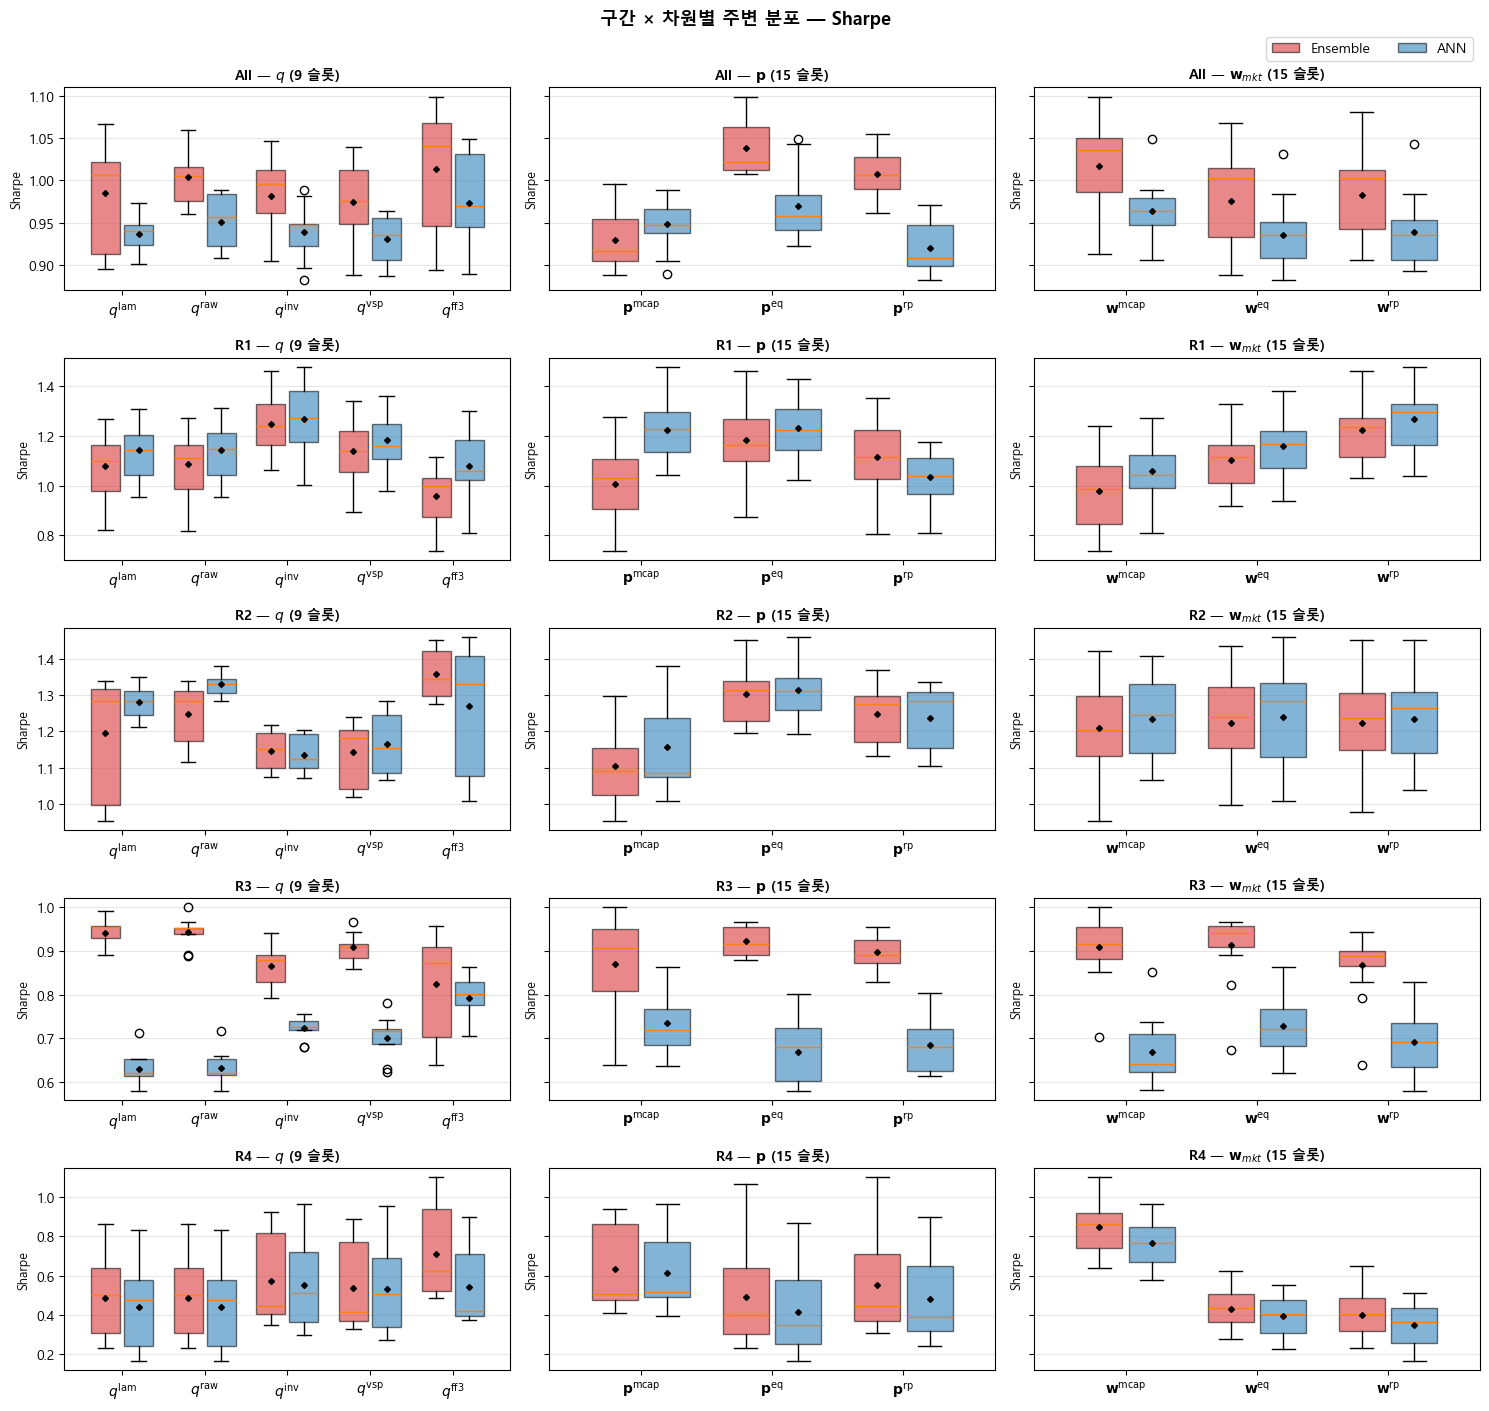

Period × Dimension × Value — mean Δ Sharpe (Ensemble − ANN)
  period            lam      raw      inv      vsp      fpm     mcap       eq       rp     mcap       eq       rp
  ---------------------------------------------------------------------------------------------------------------
  All            +0.049   +0.052   +0.042   +0.044   +0.041   -0.019   +0.068   +0.088   +0.053   +0.040   +0.044
  R1             -0.062   -0.058   -0.017   -0.042   -0.121   -0.214   -0.046   +0.081   -0.079   -0.056   -0.045
  R2             -0.087   -0.081   +0.012   -0.023   +0.089   -0.053   -0.012   +0.010   -0.026   -0.018   -0.010
  R3             +0.310   +0.309   +0.141   +0.206   +0.032   +0.134   +0.253   +0.212   +0.240   +0.185   +0.175
  R4             +0.045   +0.045   +0.018   +0.008   +0.169   +0.019   +0.076   +0.076   +0.081   +0.038   +0.052


In [13]:
# ── [3d] Period × Dimension marginal — 5 periods × 3 dimensions ──
# §5.3 보조 figure: regime별 슬롯 차원 효과를 모두 보여주는 detail view

_periods = list(dict.fromkeys(df_p_sh.columns.get_level_values("period")))

# ── 라벨 매핑 (코드명 → 논문 표기) ──
Q_DISPLAY = {
    'lam': r'$q^{\mathrm{lam}}$',
    'raw': r'$q^{\mathrm{raw}}$',
    'inv': r'$q^{\mathrm{inv}}$',
    'vsp': r'$q^{\mathrm{vsp}}$',
    'fpm': r'$q^{\mathrm{ff3}}$',   # 코드 fpm → 논문 ff3
}
P_DISPLAY = {
    'mcap': r'$\mathbf{p}^{\mathrm{mcap}}$',
    'eq':   r'$\mathbf{p}^{\mathrm{eq}}$',
    'rp':   r'$\mathbf{p}^{\mathrm{rp}}$',
}
PRIOR_DISPLAY = {
    'mcap': r'$\mathbf{w}^{\mathrm{mcap}}$',
    'eq':   r'$\mathbf{w}^{\mathrm{eq}}$',
    'rp':   r'$\mathbf{w}^{\mathrm{rp}}$',
}

def _paired_box_d(ax, categories, data_L, data_A, title, ylabel="Sharpe"):
    n = len(categories)
    pos = np.arange(n)
    bpL = ax.boxplot(data_L, positions=pos - 0.2, widths=0.35, patch_artist=True,
                      showmeans=True, meanprops=dict(marker="D", markerfacecolor="black",
                      markeredgecolor="black", markersize=3))
    bpA = ax.boxplot(data_A, positions=pos + 0.2, widths=0.35, patch_artist=True,
                      showmeans=True, meanprops=dict(marker="D", markerfacecolor="black",
                      markeredgecolor="black", markersize=3))
    for patch in bpL["boxes"]: patch.set_facecolor("#d62728"); patch.set_alpha(0.55)
    for patch in bpA["boxes"]: patch.set_facecolor("#1f77b4"); patch.set_alpha(0.55)
    ax.set_xticks(pos); ax.set_xticklabels(categories, fontsize=10)
    ax.set_title(title, fontsize=10, fontweight="bold")
    ax.set_ylabel(ylabel, fontsize=9)
    ax.grid(True, alpha=0.3, axis="y")
    return bpL, bpA

n_periods = len(_periods)
fig, axes = plt.subplots(n_periods, 3, figsize=(15, 2.8*n_periods), sharey="row")
if n_periods == 1: axes = axes.reshape(1, -1)

for r, p in enumerate(_periods):
    p_L = df_p_sh[(p, "L")]; p_A = df_p_sh[(p, "A")]

    # Q dim
    data_L = [p_L.xs(q, level="q").dropna().values for q in Q_MODES]
    data_A = [p_A.xs(q, level="q").dropna().values for q in Q_MODES]
    q_ticks = [Q_DISPLAY[q] for q in Q_MODES]
    bpL, bpA = _paired_box_d(axes[r, 0], q_ticks, data_L, data_A,
                              f"{p} — $q$ (9 슬롯)")

    # P dim
    data_L = [p_L.xs(pw, level="p_w").dropna().values for pw in P_WEIGHTS]
    data_A = [p_A.xs(pw, level="p_w").dropna().values for pw in P_WEIGHTS]
    p_ticks = [P_DISPLAY[pw] for pw in P_WEIGHTS]
    _paired_box_d(axes[r, 1], p_ticks, data_L, data_A,
                  f"{p} — $\\mathbf{{p}}$ (15 슬롯)")

    # Prior dim
    data_L = [p_L.xs(pr, level="prior").dropna().values for pr in PRIORS]
    data_A = [p_A.xs(pr, level="prior").dropna().values for pr in PRIORS]
    pr_ticks = [PRIOR_DISPLAY[pr] for pr in PRIORS]
    _paired_box_d(axes[r, 2], pr_ticks, data_L, data_A,
                  f"{p} — $\\mathbf{{w}}_{{mkt}}$ (15 슬롯)")

fig.legend([bpL["boxes"][0], bpA["boxes"][0]], ["Ensemble", "ANN"],
           loc="upper right", bbox_to_anchor=(0.99, 0.99), fontsize=10, ncol=2)
plt.suptitle("구간 × 차원별 주변 분포 — Sharpe",
             fontsize=13, fontweight="bold", y=1.005)
plt.tight_layout()
plt.show()

# 콘솔 요약: period × dimension × value 평균 Δ
print("="*78)
print("Period × Dimension × Value — mean Δ Sharpe (Ensemble − ANN)")
print("="*78)
hdr = f"  {'period':<12s}" + "".join(f"{v:>9s}" for v in (Q_MODES + P_WEIGHTS + PRIORS))
print(hdr); print("  " + "-"*(len(hdr)-2))
for p in _periods:
    p_L = df_p_sh[(p, "L")]; p_A = df_p_sh[(p, "A")]
    cells = []
    for q in Q_MODES:
        d = (p_L - p_A).xs(q, level="q").dropna()
        cells.append(f"{d.mean():>+9.3f}")
    for pw in P_WEIGHTS:
        d = (p_L - p_A).xs(pw, level="p_w").dropna()
        cells.append(f"{d.mean():>+9.3f}")
    for pr in PRIORS:
        d = (p_L - p_A).xs(pr, level="prior").dropna()
        cells.append(f"{d.mean():>+9.3f}")
    print(f"  {p:<12s}" + "".join(cells))


In [14]:
# ── [3e] P 행렬 평균 Sharpe 표 — §4.3 메인 표 (LaTeX 출력) ──
# 각 p_w 값에 대해 (Q × prior) 15 슬롯 평균 LSTM/ANN Sharpe + Δ
# 출력: (1) 콘솔 친화 (2) overleaf 바로 복붙 가능한 완성 LaTeX 표

_periods = list(dict.fromkeys(df_p_sh.columns.get_level_values("period")))

# ── 콘솔 친화 표 ──
print("="*100)
print("P 행렬 평균 Sharpe — Q 5개 × prior 3개 = 15 슬롯 평균")
print("="*100)
hdr = f"{'p_w':<6s}" + "".join(f"{p:^24s}" for p in _periods)
print(hdr); print("-"*len(hdr))
sub_hdr = "      " + "".join(f"{'L':>7s}{'A':>8s}{'Δ':>9s}" for _ in _periods)
print(sub_hdr)

results = {}
for pw in P_WEIGHTS:
    cells_text = []
    cells_data = {}
    for p in _periods:
        L = df_p_sh[(p, "L")].xs(pw, level="p_w").dropna()
        A = df_p_sh[(p, "A")].xs(pw, level="p_w").dropna()
        Lm, Am = L.mean(), A.mean()
        delta = Lm - Am
        cells_text.append(f"{Lm:>7.3f}{Am:>8.3f}{delta:>+9.3f}")
        cells_data[p] = (Lm, Am, delta)
    results[pw] = cells_data
    print(f"{pw:<6s}" + "".join(cells_text))

# ── LSTM win count (콘솔 보조) ──
print("\n" + "="*60)
print("LSTM win count (Δ>0) — 15 슬롯 중")
print("="*60)
hdr2 = f"{'p_w':<6s}" + "".join(f"{p:>10s}" for p in _periods)
print(hdr2); print("-"*len(hdr2))
for pw in P_WEIGHTS:
    cells = []
    for p in _periods:
        d = (df_p_sh[(p, "L")] - df_p_sh[(p, "A")]).xs(pw, level="p_w").dropna()
        cells.append(f"{int((d>0).sum())}/{len(d)}")
    print(f"{pw:<6s}" + "".join(f"{c:>10s}" for c in cells))

# ── 완성 LaTeX 표 (Overleaf 복붙용) ──
n_periods = len(_periods)
col_spec = "l " + " ".join(["ccc"] * n_periods)
period_hdr = " & ".join([f"\\multicolumn{{3}}{{c}}{{{p}}}" for p in _periods])
cmidrules = " ".join([f"\\cmidrule(lr){{{2 + 3*i}-{4 + 3*i}}}" for i in range(n_periods)])
sub_hdr_l = " & ".join(["L & A & $\\Delta$"] * n_periods)

latex_lines = []
latex_lines.append(r"\begin{table}[ht]")
latex_lines.append(r"\centering")
latex_lines.append(r"\caption{P 행렬 변경에 따른 평균 Sharpe 비율 ($Q$ 5개 $\times$ prior 3개 = 15 슬롯 평균, $\omega=$err 고정). LSTM(L)과 ANN(A)의 평균 Sharpe 비율 및 차이 $\Delta = \mathrm{L} - \mathrm{A}$를 전체 표본과 4개 구간(R1 회복, R2 확장, R3 위기, R4 AI랠리)에 대해 비교한다.}")
latex_lines.append(r"\label{tab:p_matrix_avg}")
latex_lines.append(r"\setlength{\tabcolsep}{3pt}")
latex_lines.append(r"\renewcommand{\arraystretch}{1.15}")
latex_lines.append(r"\footnotesize")
latex_lines.append(r"\resizebox{\textwidth}{!}{%")
latex_lines.append(f"\\begin{{tabular}}{{{col_spec}}}")
latex_lines.append(r"\toprule")
latex_lines.append(f"  & {period_hdr} \\\\")
latex_lines.append(cmidrules)
latex_lines.append(f"$p_w$ & {sub_hdr_l} \\\\")
latex_lines.append(r"\midrule")

for pw in P_WEIGHTS:
    parts = [pw]
    for p in _periods:
        Lm, Am, d = results[pw][p]
        if d > 0.001:
            d_str = f"\\cellcolor{{posgreen!50}}$+{d:.3f}$"
        elif d < -0.001:
            d_str = f"\\cellcolor{{negred!50}}${d:.3f}$"
        else:
            d_str = f"${d:+.3f}$"
        parts.extend([f"{Lm:.3f}", f"{Am:.3f}", d_str])
    latex_lines.append(" & ".join(parts) + r" \\")

latex_lines.append(r"\bottomrule")
latex_lines.append(r"\end{tabular}%")
latex_lines.append(r"}")
latex_lines.append(r"\end{table}")

print("\n" + "="*100)
print("Overleaf 복붙용 LaTeX 표")
print("="*100)
print("\n".join(latex_lines))


P 행렬 평균 Sharpe — Q 5개 × prior 3개 = 15 슬롯 평균
p_w             All                      R1                      R2                      R3                      R4           
------------------------------------------------------------------------------------------------------------------------------
            L       A        Δ      L       A        Δ      L       A        Δ      L       A        Δ      L       A        Δ
mcap    0.929   0.948   -0.019  1.008   1.222   -0.214  1.104   1.157   -0.053  0.869   0.735   +0.134  0.633   0.614   +0.019
eq      1.038   0.970   +0.068  1.184   1.230   -0.046  1.303   1.314   -0.012  0.923   0.669   +0.253  0.492   0.415   +0.076
rp      1.008   0.920   +0.088  1.114   1.034   +0.081  1.248   1.238   +0.010  0.896   0.685   +0.212  0.555   0.479   +0.076

LSTM win count (Δ>0) — 15 슬롯 중
p_w          All        R1        R2        R3        R4
--------------------------------------------------------
mcap        5/15      0/15      5/15     12/15  

## [3+] 90 슬롯 페어와이즈 SR/Sortino 검정 (Stationary Block Bootstrap)

**목적**: §4.2 (표 3, 13 슬롯 anchor 1-dim 변형) + §4.3 (표 4 marginal) + 부록 B (표 A.7~A.12, 90 슬롯 전체) 의 통계적 유의성 검정.

- **방법**: 본문 §4.1 의 정상 블록 부트스트랩 (Politis & Romano, 1994; B=10,000, 평균 블록 길이 T^(1/3)) 동일 적용
- **단위**: 슬롯별 (LSTM 월별 수익률, ANN 월별 수익률) 페어 → 월 인덱스 동시 resample → Δ_SR (또는 Δ_Sortino) 분포 → p-value + 95% CI
- **메트릭**: Sharpe, Sortino (MDD 는 path-dependent → 검정 제외)
- **MDD**: raw 값만 부록에 그대로


In [20]:
# ── [3+] 90 슬롯 × 5 기간 × 2 지표 Stationary Block Bootstrap ──
import time
from itertools import product

# 슬롯 정의 (90 = 2 omega × 3 prior × 3 p_w × 5 q)
PRIORS_A    = ['mcap', 'eq', 'rp']
P_WEIGHTS_A = ['mcap', 'eq', 'rp']
Q_MODES_A   = ['lam', 'raw', 'inv', 'vsp', 'fpm']
OMEGAS_A    = ['pap', 'he']

slots90 = [(om, pw, pr, q)
           for om in OMEGAS_A
           for pw in P_WEIGHTS_A
           for pr in PRIORS_A
           for q  in Q_MODES_A]
print(f'90 슬롯 정의: {len(slots90)}')

# 검정 기간
PERIODS_A2 = [
    ('All', None, None),
    ('R1',  '2010-01-01', '2012-06-30'),
    ('R2',  '2012-07-01', '2019-12-31'),
    ('R3',  '2020-01-01', '2023-06-30'),
    ('R4',  '2023-07-01', '2025-12-31'),
]
B_RUNS_A2 = 10_000


# ── SR / Sortino 스칼라 (관측값) ──
def _sharpe_sc(r, rfa):
    exc = r - rfa
    vol = r.std(ddof=1) * np.sqrt(12)
    return float(exc.mean() * 12 / vol) if vol > 0 else np.nan

def _sortino_sc(r, rfa):
    exc = r - rfa
    neg = r[r < 0]
    if len(neg) < 2: return np.nan
    dn = neg.std(ddof=1) * np.sqrt(12)
    return float(exc.mean() * 12 / dn) if dn > 0 else np.nan


# ── 벡터화 SR / Sortino (B × T 매트릭스) ──
def _sharpe_b(r_b, rf_b):
    exc_b = r_b - rf_b
    mean_exc = exc_b.mean(axis=1)
    std_r = r_b.std(axis=1, ddof=1)
    return np.where(std_r > 0, mean_exc * 12 / (std_r * np.sqrt(12)), np.nan)

def _sortino_b(r_b, rf_b):
    exc_b = r_b - rf_b
    mean_exc = exc_b.mean(axis=1)
    neg_mask = r_b < 0
    n_neg = neg_mask.sum(axis=1)
    sum_neg = (r_b * neg_mask).sum(axis=1)
    mean_neg = np.where(n_neg > 0, sum_neg / n_neg, 0.0)
    diff_sq = ((r_b - mean_neg[:, None]) ** 2) * neg_mask
    var_neg = np.where(n_neg > 1, diff_sq.sum(axis=1) / (n_neg - 1), 0.0)
    sd_neg = np.sqrt(var_neg) * np.sqrt(12)
    return np.where(sd_neg > 0, mean_exc * 12 / sd_neg, np.nan)


# ── 페어 SBB 검정 ──
def paired_sbb_test(rL, rA, rfa, metric='sharpe', B=10_000, seed=42):
    """페어된 월별 수익률 SBB Δ 검정.

    rL, rA: pd.Series (월별 수익률, 같은 인덱스)
    rfa: rf 정렬됨
    metric: 'sharpe' or 'sortino'
    """
    rL_arr = np.asarray(rL.values, dtype=float)
    rA_arr = np.asarray(rA.values, dtype=float)
    rf_arr = np.asarray(rfa.values, dtype=float)
    T = len(rL_arr)
    if T < 6:
        return dict(delta_obs=np.nan, ci_lo=np.nan, ci_hi=np.nan, p_two=np.nan, n=T)

    if metric == 'sharpe':
        d_obs = _sharpe_sc(rL_arr, rf_arr) - _sharpe_sc(rA_arr, rf_arr)
    else:
        d_obs = _sortino_sc(rL_arr, rf_arr) - _sortino_sc(rA_arr, rf_arr)
    if pd.isna(d_obs):
        return dict(delta_obs=np.nan, ci_lo=np.nan, ci_hi=np.nan, p_two=np.nan, n=T)

    L = max(2.0, T ** (1/3))
    rng = np.random.default_rng(seed)

    new_block = rng.random((B, T)) < (1.0 / L)
    new_block[:, 0] = True
    seg_id = np.cumsum(new_block, axis=1) - 1
    starts = rng.integers(0, T, size=(B, T))
    seg_starts = np.take_along_axis(starts, seg_id, axis=1)
    t_arr = np.broadcast_to(np.arange(T), (B, T))
    last_new = np.where(new_block, t_arr, -1)
    last_new = np.maximum.accumulate(last_new, axis=1)
    offset = t_arr - last_new
    indices = (seg_starts + offset) % T

    rL_b = rL_arr[indices]
    rA_b = rA_arr[indices]
    rf_b = rf_arr[indices]

    if metric == 'sharpe':
        sL = _sharpe_b(rL_b, rf_b)
        sA = _sharpe_b(rA_b, rf_b)
    else:
        sL = _sortino_b(rL_b, rf_b)
        sA = _sortino_b(rA_b, rf_b)

    delta_b = sL - sA
    delta_b = delta_b[~np.isnan(delta_b)]
    if len(delta_b) < 100:
        return dict(delta_obs=float(d_obs), ci_lo=np.nan, ci_hi=np.nan, p_two=np.nan, n=T)

    centered = delta_b - d_obs
    p_two = float((np.abs(centered) >= abs(d_obs)).mean())
    ci_lo, ci_hi = np.percentile(delta_b, [2.5, 97.5])

    return dict(delta_obs=float(d_obs), ci_lo=float(ci_lo), ci_hi=float(ci_hi),
                p_two=p_two, n=T)


# ── 메인 루프: 90 슬롯 × 5 기간 × 2 지표 ──
print(f'\n90 슬롯 × {len(PERIODS_A2)} 기간 × 2 지표 (Sharpe, Sortino) Bootstrap 시작...')
print(f'B={B_RUNS_A2:,}, 평균 블록 길이 T^(1/3)')

t0 = time.perf_counter()
rows = []
missing = []
for i, (om, pw, pr, q) in enumerate(slots90):
    L_name = f'mat_{pr}_{pw}_{q}_{om}'
    A_name = L_name + '_ann'
    if L_name not in loaded or A_name not in loaded:
        missing.append(L_name); continue

    rL_full = loaded[L_name].get('ret')
    rA_full = loaded[A_name].get('ret')
    if not isinstance(rL_full, pd.Series) or not isinstance(rA_full, pd.Series):
        missing.append(L_name); continue

    rL_full = rL_full.dropna()
    rA_full = rA_full.dropna()
    rL_full = rL_full[rL_full.index <= CUTOFF]
    rA_full = rA_full[rA_full.index <= CUTOFF]
    common = rL_full.index.intersection(rA_full.index)
    rL_full = rL_full.loc[common]
    rA_full = rA_full.loc[common]

    for plbl, s, e in PERIODS_A2:
        rL = rL_full; rA = rA_full
        if s is not None:
            rL = rL[rL.index >= s]; rA = rA[rA.index >= s]
        if e is not None:
            rL = rL[rL.index <= e]; rA = rA[rA.index <= e]
        if len(rL) < 6:
            continue
        rfa = rf.reindex(rL.index).fillna(0)

        for metric in ['sharpe', 'sortino']:
            r = paired_sbb_test(rL, rA, rfa, metric=metric, B=B_RUNS_A2, seed=42)
            p = r['p_two']
            sig = ('***' if pd.notna(p) and p < 0.001 else
                   '**'  if pd.notna(p) and p < 0.01  else
                   '*'   if pd.notna(p) and p < 0.05  else '')
            rows.append({
                'omega': om, 'p_w': pw, 'prior': pr, 'q': q,
                'period': plbl, 'metric': metric,
                **r, 'sig': sig,
            })

    if (i + 1) % 15 == 0:
        elapsed = time.perf_counter() - t0
        remain = elapsed * (len(slots90) / (i + 1) - 1)
        print(f'  {i+1:>3d}/{len(slots90)} 슬롯 완료 ({elapsed:.0f}s, 예상 잔여 {remain:.0f}s)')

if missing:
    print(f'\n⚠ 누락 슬롯 {len(missing)}: {missing[:5]}...')

bs90 = pd.DataFrame(rows)
print(f'\n완료: {time.perf_counter()-t0:.1f}s | 결과 {len(bs90)} 행 ({bs90.groupby(["omega","p_w","prior","q"]).ngroups} 슬롯)')

# 저장
bs90_path = OUT_DIR / 'bs90_per_slot.pkl'
bs90.to_pickle(bs90_path)
print(f'  저장: {bs90_path}')

# 요약: omega 별 유의 셀 수 (Sharpe)
print('\n[Sharpe] omega 별 유의 (* 이상) 셀 카운트:')
for om in OMEGAS_A:
    sub = bs90[(bs90['omega']==om) & (bs90['metric']=='sharpe')]
    total = len(sub)
    sig_count = (sub['sig'] != '').sum()
    print(f'  omega={om}: {sig_count}/{total} 유의')


90 슬롯 정의: 90

90 슬롯 × 5 기간 × 2 지표 (Sharpe, Sortino) Bootstrap 시작...
B=10,000, 평균 블록 길이 T^(1/3)
   15/90 슬롯 완료 (10s, 예상 잔여 52s)
   30/90 슬롯 완료 (21s, 예상 잔여 41s)
   45/90 슬롯 완료 (31s, 예상 잔여 31s)
   60/90 슬롯 완료 (41s, 예상 잔여 20s)
   75/90 슬롯 완료 (51s, 예상 잔여 10s)
   90/90 슬롯 완료 (61s, 예상 잔여 0s)

완료: 60.9s | 결과 900 행 (90 슬롯)
  저장: c:\Users\서윤범\Desktop\temp\finance_project\final_pt\outputs\99_main_analysis\bs90_per_slot.pkl

[Sharpe] omega 별 유의 (* 이상) 셀 카운트:
  omega=pap: 36/225 유의
  omega=he: 7/225 유의


## [3++] §4.3 표 4 marginal Bootstrap — p별 평균 Δ_SR

**목적**: 표 4 의 3 p × 5 기간 = 15 셀 marginal 평균 Δ_SR 의 통계적 유의성 검정.

- **단위**: 각 (p, 기간) 에 대해 15 슬롯 (prior 3 × q 5, ω=err 고정) 의 평균 Δ_SR
- **핵심**: 월 인덱스 SBB 를 15 슬롯에 **동시 적용** → 슬롯 간 시장 환경 상관 보존
- **출력**: marginal Δ_SR + 95% CI + p


In [16]:
# ── [3++] 표 4 marginal Bootstrap (3 p × 5 기간) ──
def marginal_sbb(slot_pairs, rfa, metric='sharpe', B=10_000, seed=42):
    """월 인덱스 공유 SBB. 15 슬롯의 페어 SR 평균에 대해 검정.

    slot_pairs: list of (rL_series, rA_series) — 모두 같은 월 인덱스
    """
    n_slots = len(slot_pairs)
    T = len(slot_pairs[0][0])
    if T < 6:
        return dict(delta_obs=np.nan, ci_lo=np.nan, ci_hi=np.nan, p_two=np.nan, n=T, n_slots=n_slots)

    rL_mat = np.array([np.asarray(rL.values, dtype=float) for rL, rA in slot_pairs])  # (n_slots, T)
    rA_mat = np.array([np.asarray(rA.values, dtype=float) for rL, rA in slot_pairs])
    rf_arr = np.asarray(rfa.values, dtype=float)

    # observed: per slot SR 계산 후 평균
    obs_L = np.array([_sharpe_sc(rL_mat[s], rf_arr) if metric=='sharpe' else _sortino_sc(rL_mat[s], rf_arr)
                      for s in range(n_slots)])
    obs_A = np.array([_sharpe_sc(rA_mat[s], rf_arr) if metric=='sharpe' else _sortino_sc(rA_mat[s], rf_arr)
                      for s in range(n_slots)])
    d_obs = np.nanmean(obs_L) - np.nanmean(obs_A)
    if pd.isna(d_obs):
        return dict(delta_obs=np.nan, ci_lo=np.nan, ci_hi=np.nan, p_two=np.nan, n=T, n_slots=n_slots)

    L = max(2.0, T ** (1/3))
    rng = np.random.default_rng(seed)
    new_block = rng.random((B, T)) < (1.0 / L)
    new_block[:, 0] = True
    seg_id = np.cumsum(new_block, axis=1) - 1
    starts = rng.integers(0, T, size=(B, T))
    seg_starts = np.take_along_axis(starts, seg_id, axis=1)
    t_arr = np.broadcast_to(np.arange(T), (B, T))
    last_new = np.where(new_block, t_arr, -1)
    last_new = np.maximum.accumulate(last_new, axis=1)
    offset = t_arr - last_new
    indices = (seg_starts + offset) % T  # (B, T) 공유

    rf_b = rf_arr[indices]  # (B, T)

    delta_b_per_slot = np.zeros((n_slots, B))
    for s in range(n_slots):
        rL_b = rL_mat[s][indices]
        rA_b = rA_mat[s][indices]
        if metric == 'sharpe':
            sL = _sharpe_b(rL_b, rf_b)
            sA = _sharpe_b(rA_b, rf_b)
        else:
            sL = _sortino_b(rL_b, rf_b)
            sA = _sortino_b(rA_b, rf_b)
        delta_b_per_slot[s] = sL - sA

    delta_b_mean = np.nanmean(delta_b_per_slot, axis=0)
    delta_b_mean = delta_b_mean[~np.isnan(delta_b_mean)]
    if len(delta_b_mean) < 100:
        return dict(delta_obs=float(d_obs), ci_lo=np.nan, ci_hi=np.nan, p_two=np.nan, n=T, n_slots=n_slots)

    centered = delta_b_mean - d_obs
    p_two = float((np.abs(centered) >= abs(d_obs)).mean())
    ci_lo, ci_hi = np.percentile(delta_b_mean, [2.5, 97.5])

    return dict(delta_obs=float(d_obs), ci_lo=float(ci_lo), ci_hi=float(ci_hi),
                p_two=p_two, n=T, n_slots=n_slots)


# 표 4: ω=err (pap) 고정, 각 p_w 에 대해 15 슬롯 marginal Bootstrap (Sharpe 만)
print('\n표 4 marginal Bootstrap (3 p × 5 기간 × Sharpe) 시작...')
import time
t0 = time.perf_counter()
marg_rows = []
for pw in P_WEIGHTS_A:
    pair_full = []
    for pr in PRIORS_A:
        for q in Q_MODES_A:
            L_name = f'mat_{pr}_{pw}_{q}_pap'
            A_name = L_name + '_ann'
            if L_name not in loaded or A_name not in loaded:
                continue
            rL = loaded[L_name].get('ret').dropna()
            rA = loaded[A_name].get('ret').dropna()
            rL = rL[rL.index <= CUTOFF]
            rA = rA[rA.index <= CUTOFF]
            common = rL.index.intersection(rA.index)
            if len(common) < 6: continue
            pair_full.append((rL.loc[common], rA.loc[common]))
    print(f'  p_w={pw}: {len(pair_full)} 슬롯 (prior×q)')

    for plbl, s, e in PERIODS_A2:
        pair_period = []
        for rL, rA in pair_full:
            r1 = rL; r2 = rA
            if s is not None:
                r1 = r1[r1.index >= s]; r2 = r2[r2.index >= s]
            if e is not None:
                r1 = r1[r1.index <= e]; r2 = r2[r2.index <= e]
            common = r1.index.intersection(r2.index)
            if len(common) < 6: continue
            pair_period.append((r1.loc[common], r2.loc[common]))
        if not pair_period: continue

        rfa = rf.reindex(pair_period[0][0].index).fillna(0)
        r = marginal_sbb(pair_period, rfa, metric='sharpe', B=B_RUNS_A2, seed=42)
        p = r['p_two']
        sig = ('***' if pd.notna(p) and p < 0.001 else
               '**'  if pd.notna(p) and p < 0.01  else
               '*'   if pd.notna(p) and p < 0.05  else '')
        marg_rows.append({'p_w': pw, 'period': plbl, 'metric': 'sharpe',
                          **r, 'sig': sig})

bs_marg = pd.DataFrame(marg_rows)
print(f'\n완료: {time.perf_counter()-t0:.1f}s | {len(bs_marg)} 행')
bs_marg.to_pickle(OUT_DIR / 'bs_marginal_table4.pkl')

print('\n표 4 marginal Bootstrap 결과:')
print(bs_marg.to_string(index=False,
    formatters={'delta_obs': '{:+.4f}'.format, 'ci_lo': '{:+.4f}'.format,
                'ci_hi': '{:+.4f}'.format, 'p_two': '{:.4f}'.format}))



표 4 marginal Bootstrap (3 p × 5 기간 × Sharpe) 시작...
  p_w=mcap: 15 슬롯 (prior×q)
  p_w=eq: 15 슬롯 (prior×q)
  p_w=rp: 15 슬롯 (prior×q)

완료: 4.8s | 15 행

표 4 marginal Bootstrap 결과:
 p_w period metric delta_obs   ci_lo   ci_hi  p_two   n  n_slots sig
mcap    All sharpe   -0.0187 -0.1258 +0.0909 0.7396 192       15    
mcap     R1 sharpe   -0.2142 -0.4569 -0.0620 0.0381  30       15   *
mcap     R2 sharpe   -0.0530 -0.2248 +0.1360 0.5549  90       15    
mcap     R3 sharpe   +0.1343 -0.0941 +0.3827 0.2719  42       15    
mcap     R4 sharpe   +0.0186 -0.1107 +0.1019 0.7284  30       15    
  eq    All sharpe   +0.0681 -0.0405 +0.1766 0.2184 192       15    
  eq     R1 sharpe   -0.0463 -0.1941 +0.0480 0.3815  30       15    
  eq     R2 sharpe   -0.0115 -0.2338 +0.2186 0.9214  90       15    
  eq     R3 sharpe   +0.2532 +0.0862 +0.4887 0.0200  42       15   *
  eq     R4 sharpe   +0.0765 -0.0667 +0.2531 0.3414  30       15    
  rp    All sharpe   +0.0875 -0.0248 +0.2022 0.1281 192       15

## [3+++] Bootstrap 결과 진단 — bs90 확인

본 셀은 `bs90_per_slot.pkl` 로드해 4가지 관점에서 결과 확인:

1. **요약 통계** — omega × 기간 × metric 별 유의 셀 카운트
2. **omega=err Sharpe 전체** — 45 슬롯 × 5 기간 (Δ + sig 별표)
3. **omega=he Sharpe 전체** — 동일
4. **narrative 인용 셀 lookup** — 본문에서 인용한 핵심 셀 결과
5. **상위 유의 셀 top 20** — |Δ_SR| 큰 순서 + p-value


In [18]:
# ── [3+++] bs90 결과 진단 ──
from IPython.display import display
bs90 = pd.read_pickle(OUT_DIR / 'bs90_per_slot.pkl')
print(f'로드 완료: {len(bs90)} 행 ({bs90["omega"].nunique()} omega × {bs90["p_w"].nunique()} p_w × {bs90["prior"].nunique()} prior × {bs90["q"].nunique()} q × {bs90["period"].nunique()} period × {bs90["metric"].nunique()} metric)')

# ── (1) 요약: omega × metric × period 유의 카운트 ──
print('\n' + '='*70)
print('(1) 유의 셀 카운트 (p<.05)')
print('='*70)
for met in ['sharpe', 'sortino']:
    print(f'\n[{met.upper()}]')
    sub = bs90[bs90['metric'] == met]
    summary = sub.assign(is_sig=(sub['sig'] != '').astype(int)).groupby(['omega', 'period'])['is_sig'].agg(['sum', 'count'])
    summary['ratio'] = (summary['sum'] / summary['count'] * 100).round(1)
    summary.columns = ['유의셀', '전체', '비율(%)']
    print(summary.to_string())


# ── (2) omega=err Sharpe 표 (45 슬롯 × 5 기간, Δ + sig) ──
print('\n' + '='*100)
print('(2) ω=err (pap) Sharpe: 45 슬롯 × 5 기간 — Δ + sig')
print('='*100)
sub_err = bs90[(bs90['omega']=='pap') & (bs90['metric']=='sharpe')].copy()
sub_err['cell'] = sub_err.apply(
    lambda r: '' if pd.isna(r['delta_obs']) else f"{r['delta_obs']:+.3f}{r['sig']:<3s}",
    axis=1,
)
tab_err = sub_err.pivot_table(index=['p_w','prior','q'], columns='period',
                                values='cell', aggfunc='first')
# 기간 순서
tab_err = tab_err[['All','R1','R2','R3','R4']]
# slot 순서 (mcap→eq→rp, mcap→eq→rp, lam→raw→inv→vsp→fpm)
pw_order = ['mcap','eq','rp']; pr_order = ['mcap','eq','rp']; q_order = ['lam','raw','inv','vsp','fpm']
idx_order = [(pw, pr, q) for pw in pw_order for pr in pr_order for q in q_order]
tab_err = tab_err.reindex(idx_order)
print(tab_err.to_string())


# ── (3) omega=he Sharpe 표 ──
print('\n' + '='*100)
print('(3) ω=he Sharpe: 45 슬롯 × 5 기간 — Δ + sig')
print('='*100)
sub_he = bs90[(bs90['omega']=='he') & (bs90['metric']=='sharpe')].copy()
sub_he['cell'] = sub_he.apply(
    lambda r: '' if pd.isna(r['delta_obs']) else f"{r['delta_obs']:+.3f}{r['sig']:<3s}",
    axis=1,
)
tab_he = sub_he.pivot_table(index=['p_w','prior','q'], columns='period',
                              values='cell', aggfunc='first')
tab_he = tab_he[['All','R1','R2','R3','R4']]
tab_he = tab_he.reindex(idx_order)
print(tab_he.to_string())


# ── (4) Narrative 인용 셀 lookup ──
print('\n' + '='*100)
print('(4) Narrative 인용 셀 (본문 §4.2 / §4.3 인용 슬롯)')
print('='*100)

# 본문 4.2 인용 슬롯들 — (omega, p_w, prior, q, period, metric)
narrative_cells = [
    # q 변형 분석 (anchor: mcap_mcap, omega=pap)
    ('pap', 'mcap', 'mcap', 'lam', 'R3', 'sharpe', 'q=lam R3 (q≥0 부호 안정)'),
    ('pap', 'mcap', 'mcap', 'raw', 'R3', 'sharpe', 'q=raw R3'),
    ('pap', 'mcap', 'mcap', 'inv', 'R3', 'sharpe', 'q=inv R3'),
    ('pap', 'mcap', 'mcap', 'vsp', 'R3', 'sharpe', 'q=vsp R3'),
    ('pap', 'mcap', 'mcap', 'fpm', 'R3', 'sharpe', 'q=fpm R3 (anchor, 부호 유동)'),
    # p 변형 분석
    ('pap', 'mcap', 'mcap', 'fpm', 'All', 'sharpe', 'p=mcap All (anchor)'),
    ('pap', 'eq',   'mcap', 'fpm', 'All', 'sharpe', 'p=eq All'),
    ('pap', 'rp',   'mcap', 'fpm', 'All', 'sharpe', 'p=rp All'),
    # w_mkt 변형 (R1, R3 ANN 우위 vs R2, R4 LSTM 우위)
    ('pap', 'mcap', 'mcap', 'fpm', 'R1', 'sharpe', 'anchor R1'),
    ('pap', 'mcap', 'mcap', 'fpm', 'R3', 'sharpe', 'anchor R3'),
    ('pap', 'mcap', 'mcap', 'fpm', 'R2', 'sharpe', 'anchor R2'),
    ('pap', 'mcap', 'mcap', 'fpm', 'R4', 'sharpe', 'anchor R4'),
    # omega 변형 (omega=he vs omega=err)
    ('he',  'mcap', 'mcap', 'fpm', 'All', 'sharpe', 'omega=he All (vs anchor)'),
]
print(f'{"슬롯 설명":<40s} {"Δ_SR":>9s} {"95% CI":>22s} {"p_two":>8s} {"sig":>5s}')
print('-' * 90)
for om, pw, pr, q, period, met, label in narrative_cells:
    row = bs90[(bs90['omega']==om) & (bs90['p_w']==pw) & (bs90['prior']==pr) &
               (bs90['q']==q) & (bs90['period']==period) & (bs90['metric']==met)]
    if row.empty:
        print(f'{label:<40s} (not found)')
        continue
    r = row.iloc[0]
    ci_str = f'[{r["ci_lo"]:+.3f}, {r["ci_hi"]:+.3f}]'
    print(f'{label:<40s} {r["delta_obs"]:>+9.4f} {ci_str:>22s} {r["p_two"]:>8.4f} {r["sig"]:>5s}')


# ── (5) 상위 유의 셀 top 20 (|Δ_SR| 기준) ──
print('\n' + '='*100)
print('(5) |Δ_SR| 큰 순서 상위 20 셀 (Sharpe, sig ≠ "")')
print('='*100)
sub = bs90[(bs90['metric']=='sharpe') & (bs90['sig'] != '')].copy()
sub['abs_d'] = sub['delta_obs'].abs()
top = sub.nlargest(20, 'abs_d')[['omega','p_w','prior','q','period','delta_obs','ci_lo','ci_hi','p_two','sig']]
print(top.to_string(index=False,
    formatters={'delta_obs':'{:+.4f}'.format, 'ci_lo':'{:+.4f}'.format,
                'ci_hi':'{:+.4f}'.format, 'p_two':'{:.4f}'.format}))


로드 완료: 900 행 (2 omega × 3 p_w × 3 prior × 5 q × 5 period × 2 metric)

(1) 유의 셀 카운트 (p<.05)

[SHARPE]
              유의셀  전체  비율(%)
omega period                
he    All       0  45    0.0
      R1        3  45    6.7
      R2        0  45    0.0
      R3        4  45    8.9
      R4        0  45    0.0
pap   All       0  45    0.0
      R1       11  45   24.4
      R2        0  45    0.0
      R3       25  45   55.6
      R4        0  45    0.0

[SORTINO]
              유의셀  전체  비율(%)
omega period                
he    All       0  45    0.0
      R1        0  45    0.0
      R2        0  45    0.0
      R3        0  45    0.0
      R4        0  45    0.0
pap   All       3  45    6.7
      R1        0  45    0.0
      R2        0  45    0.0
      R3        0  45    0.0
      R4        0  45    0.0

(2) ω=err (pap) Sharpe: 45 슬롯 × 5 기간 — Δ + sig
period                All         R1         R2         R3         R4
p_w  prior q                                                         
mcap

## [3++++] 표 출력: 본문 표 3 + 부록 표 A.7-A.12 (TSV)

bs90 + raw 메트릭 결합 → 7개 표 TSV 형식 출력.

**Word paste 방법**:
1. 각 TSV 블록 전체 복사 (헤더 포함)
2. 워드에서 "선택하여 붙여넣기 > 서식 없는 텍스트"
3. 붙여넣은 텍스트 블록 선택 → "삽입 > 표 > 텍스트를 표로 변환" (구분자: **탭**)
4. 헤더 행 (1, 2행) 의 빈 셀 수동 병합 (period 헤더 spanning)

**셀 형식**:
- Sharpe/Sortino: `E값`, `A값`, `Δ+sig` (예: `+0.353*`)
- MDD: `E%`, `A%`, `Δ%` (sig 없음 — 경로 의존적이라 부트스트랩 미적용)


In [19]:
# ── [3++++] 본문 표 3 + 부록 표 A.7-A.12 TSV 출력 ──
# 1) raw E/A/Δ 계산 (90 슬롯 × 5 기간 × 3 지표)
# 2) bs90 sig 와 merge
# 3) TSV 블록 7개 출력

PERIODS_OUT = [
    ('All', None, None),
    ('R1', '2010-01-01', '2012-06-30'),
    ('R2', '2012-07-01', '2019-12-31'),
    ('R3', '2020-01-01', '2023-06-30'),
    ('R4', '2023-07-01', '2025-12-31'),
]
PER_LBL = ['All','R1','R2','R3','R4']


def _calc_3metrics(name, start, end):
    if name not in loaded: return None
    ret = loaded[name].get('ret')
    if not isinstance(ret, pd.Series): return None
    r = ret.dropna()
    r = r[r.index <= CUTOFF]
    if start is not None: r = r[r.index >= start]
    if end is not None:   r = r[r.index <= end]
    if len(r) < 6: return None
    rfa = rf.reindex(r.index).fillna(0)
    exc = r - rfa
    vol = r.std(ddof=1) * np.sqrt(12)
    sh = float(exc.mean() * 12 / vol) if vol > 0 else np.nan
    neg = r[r < 0]
    dn = neg.std(ddof=1) * np.sqrt(12) if len(neg) >= 2 else np.nan
    so = float(exc.mean() * 12 / dn) if (dn and dn > 0) else np.nan
    cum = (1 + r).cumprod()
    mdd = float((cum / cum.cummax() - 1).min())
    return {'sharpe': sh, 'sortino': so, 'mdd': mdd}


# 90 슬롯 raw 계산
raw_rows = []
for om in ['pap', 'he']:
    for pw in ['mcap','eq','rp']:
        for pr in ['mcap','eq','rp']:
            for q in ['lam','raw','inv','vsp','fpm']:
                L_name = f'mat_{pr}_{pw}_{q}_{om}'
                A_name = L_name + '_ann'
                for plbl, s, e in PERIODS_OUT:
                    mL = _calc_3metrics(L_name, s, e)
                    mA = _calc_3metrics(A_name, s, e)
                    if not mL or not mA: continue
                    for met in ['sharpe','sortino','mdd']:
                        raw_rows.append({
                            'omega': om, 'p_w': pw, 'prior': pr, 'q': q,
                            'period': plbl, 'metric': met,
                            'E': mL[met], 'A': mA[met],
                            'delta': mL[met] - mA[met],
                        })
raw_df = pd.DataFrame(raw_rows)

# bs90 sig merge
bs90 = pd.read_pickle(OUT_DIR / 'bs90_per_slot.pkl')
merged = raw_df.merge(
    bs90[['omega','p_w','prior','q','period','metric','sig']],
    on=['omega','p_w','prior','q','period','metric'], how='left',
)
merged['sig'] = merged['sig'].fillna('')
print(f'raw + sig merge: {len(merged)} 행')


# ── 셀 포맷 헬퍼 ──
def _cell_sr(row):
    if pd.isna(row['delta']): return ('', '', '')
    return (f"{row['E']:.3f}", f"{row['A']:.3f}", f"{row['delta']:+.3f}{row['sig']}")

def _cell_mdd(row):
    if pd.isna(row['delta']): return ('', '', '')
    return (f"{row['E']*100:.2f}%", f"{row['A']*100:.2f}%", f"{row['delta']*100:+.2f}%")


def _lookup(omega, pw, pr, q, period, metric):
    row = merged[(merged['omega']==omega) & (merged['p_w']==pw) & (merged['prior']==pr) &
                 (merged['q']==q) & (merged['period']==period) & (merged['metric']==metric)]
    return row.iloc[0] if not row.empty else None


# ── 출력 1: 본문 표 3 ──
print('\n' + '='*120)
print('<표 3> 본문 — 13 슬롯 Sharpe (anchor 1-dim 변형, TSV)')
print('='*120)
print('주: ★ = 기준 슬롯 (mcap_mcap_fpm_pap = Pyo & Lee 2018 기준)')
print()

# 헤더 2줄
hdr1 = '\t\t' + '\t'.join(f'{p}\t\t' for p in PER_LBL)
hdr2 = '차원\t슬롯\t' + '\t'.join('E\tA\tΔ' for _ in PER_LBL)
print(hdr1)
print(hdr2)

SLOTS_T3 = [
    ('SET 1 (q)',    'qlam',       'mcap','mcap','lam','pap'),
    ('SET 1 (q)',    'qraw',       'mcap','mcap','raw','pap'),
    ('SET 1 (q)',    'qinv',       'mcap','mcap','inv','pap'),
    ('SET 1 (q)',    'qvsp',       'mcap','mcap','vsp','pap'),
    ('SET 1 (q)',    'qff3 ★',     'mcap','mcap','fpm','pap'),
    ('SET 2 (p)',    'pmcap ★',    'mcap','mcap','fpm','pap'),
    ('SET 2 (p)',    'peq',        'mcap','eq',  'fpm','pap'),
    ('SET 2 (p)',    'prp',        'mcap','rp',  'fpm','pap'),
    ('SET 3 (wmkt)', 'wmcap ★',    'mcap','mcap','fpm','pap'),
    ('SET 3 (wmkt)', 'weq',        'eq',  'mcap','fpm','pap'),
    ('SET 3 (wmkt)', 'wrp',        'rp',  'mcap','fpm','pap'),
    ('SET 4 (ω)',    'ωerr ★',     'mcap','mcap','fpm','pap'),
    ('SET 4 (ω)',    'ωhe',        'mcap','mcap','fpm','he'),
]

for dim, slot, pr, pw, q, om in SLOTS_T3:
    cells = [dim, slot]
    for plbl in PER_LBL:
        r = _lookup(om, pw, pr, q, plbl, 'sharpe')
        if r is None:
            cells.extend(['', '', ''])
        else:
            E, A, D = _cell_sr(r)
            cells.extend([E, A, D])
    print('\t'.join(cells))


# ── 출력 2~7: 부록 표 A.7~A.12 ──
def print_appendix(metric, omega, table_name, omega_label):
    note = ''
    if metric == 'mdd':
        note = ' — sig 없음 (MDD 경로 의존적, 부트스트랩 미적용)'
    print('\n' + '='*120)
    print(f'<{table_name}> 부록 — 45 슬롯 {metric.capitalize()}, ω={omega_label}{note} (TSV)')
    print('='*120)

    hdr1 = '\t\t\t' + '\t'.join(f'{p}\t\t' for p in PER_LBL)
    hdr2 = 'p\twmkt\tq\t' + '\t'.join('E\tA\tΔ' for _ in PER_LBL)
    print(hdr1)
    print(hdr2)

    for pw in ['mcap','eq','rp']:
        for pr in ['mcap','eq','rp']:
            for q in ['lam','raw','inv','vsp','fpm']:
                # ★ 표시 (anchor: pmcap wmcap qff3 only)
                anchor_mark = ' ★' if (pw=='mcap' and pr=='mcap' and q=='fpm') else ''
                cells = [f'p{pw}', f'w{pr}', f'q{q}{anchor_mark}']
                for plbl in PER_LBL:
                    r = _lookup(omega, pw, pr, q, plbl, metric)
                    if r is None:
                        cells.extend(['', '', ''])
                    else:
                        E, A, D = _cell_mdd(r) if metric == 'mdd' else _cell_sr(r)
                        cells.extend([E, A, D])
                print('\t'.join(cells))


print_appendix('sharpe',  'pap', '표 A.7',  'err')
print_appendix('sortino', 'pap', '표 A.8',  'err')
print_appendix('mdd',     'pap', '표 A.9',  'err')
print_appendix('sharpe',  'he',  '표 A.10', 'he')
print_appendix('sortino', 'he',  '표 A.11', 'he')
print_appendix('mdd',     'he',  '표 A.12', 'he')


print('\n' + '='*120)
print('완료 — 위 7개 TSV 블록을 워드에 paste 하세요.')
print('  방법: TSV 복사 → 워드 "선택하여 붙여넣기 > 서식 없는 텍스트" → "삽입 > 표 > 텍스트를 표로 변환 (탭)"')
print('  헤더 1행 (period spanning) 빈 셀은 워드에서 수동 셀 병합')
print('='*120)


# ── 표 각주 안내 (워드 표 아래 작은 글씨) ──
print('\n' + '='*120)
print('각 표 각주 (워드 표 아래 9pt 작은 글씨)')
print('='*120)
print("""
[본문 표 3 각주]
주: ★ = Pyo & Lee (2018) 기준 슬롯 (mcap_mcap_fpm_pap). E = 앙상블, A = ANN, Δ = E - A.
   별표는 본문 §4.1 에서 설명한 정상 블록 부트스트랩 검정 결과 (* p<.05, ** p<.01, *** p<.001).
   페어된 월별 수익률을 동시 재추출하여 페어링 및 자기상관 구조를 보존 (B = 10,000).

[부록 표 A.7~A.8, A.10~A.11 각주 — Sharpe/Sortino]
주: p = P 행렬 가중 방식, wmkt = 사전 분포, q = 뷰 산출 방식. E = 앙상블, A = ANN, Δ = E - A.
   별표는 본문 §4.1 동일 정상 블록 부트스트랩 검정 결과 (* p<.05, ** p<.01, *** p<.001).
   ★ = Pyo & Lee (2018) 기준 슬롯.

[부록 표 A.9, A.12 각주 — MDD]
주: MDD = 최대낙폭. 음수가 손실이므로 Δ > 0 이 앙상블이 덜 빠진 경우.
   MDD 는 경로 의존적 통계량이므로 부트스트랩 추론을 적용하지 않으며, 본 표에서는 raw 값과 차이만 보고.
""")


raw + sig merge: 1350 행

<표 3> 본문 — 13 슬롯 Sharpe (anchor 1-dim 변형, TSV)
주: ★ = 기준 슬롯 (mcap_mcap_fpm_pap = Pyo & Lee 2018 기준)

		All			R1			R2			R3			R4		
차원	슬롯	E	A	Δ	E	A	Δ	E	A	Δ	E	A	Δ	E	A	Δ
SET 1 (q)	qlam	0.913	0.952	-0.038	0.821	1.041	-0.220*	0.953	1.213	-0.260	0.991	0.638	+0.353*	0.864	0.833	+0.030
SET 1 (q)	qraw	0.976	0.988	-0.012	0.818	1.044	-0.226*	1.115	1.332	-0.217	0.999	0.643	+0.357*	0.864	0.833	+0.030
SET 1 (q)	qinv	0.995	0.982	+0.014	1.061	1.244	-0.183	1.100	1.084	+0.016	0.894	0.738	+0.156	0.915	0.963	-0.048
SET 1 (q)	qvsp	0.949	0.948	+0.000	0.894	1.105	-0.211*	1.030	1.067	-0.037	0.943	0.720	+0.223	0.891	0.958	-0.067
SET 1 (q)	qff3 ★	0.946	0.945	+0.000	0.738	1.059	-0.321*	1.287	1.076	+0.212	0.702	0.850	-0.148	0.940	0.712	+0.228
SET 2 (p)	pmcap ★	0.946	0.945	+0.000	0.738	1.059	-0.321*	1.287	1.076	+0.212	0.702	0.850	-0.148	0.940	0.712	+0.228
SET 2 (p)	peq	1.099	1.049	+0.050	0.872	1.024	-0.152	1.421	1.408	+0.013	0.888	0.705	+0.183	1.066	0.868	+0.198
SET 2 (p)	prp	1.054	0.970	+0.

## [3b] P 행렬 × 모든 슬롯 grid — R1-R3 sample (R4 제외)

**목적**: [3] 의 동일 분석을 **R4 (AI 랠리, 2023-07~2025-12) 제외** 한 sample (2010-01~2023-06, 162 months) 에서 재확인.

- R4 의 구조적 특수성 (AI 랠리 / Mag7 집중) 이 grid 패턴에 미치는 영향 확인용
- main 본문엔 안 들어감 (sample cutting). discussion / appendix evidence 로만 사용


In [11]:
# ── [3b] P 행렬 × 모든 슬롯 grid — R1-R3 sample (R4 제외) ───────
from IPython.display import display

PERIODS_R13 = [
    ('All_R1-R3', '2010-01-01', '2023-06-30'),
    ('R1',        '2010-01-01', '2012-06-30'),
    ('R2',        '2012-07-01', '2019-12-31'),
    ('R3',        '2020-01-01', '2023-06-30'),
]

PRIORS    = ['mcap', 'eq', 'rp']
P_WEIGHTS = ['mcap', 'eq', 'rp']
Q_MODES   = ['lam', 'raw', 'inv', 'vsp', 'fpm']
OMEGA     = 'pap'

slots = [(pw, pr, q)
         for pw in P_WEIGHTS
         for pr in PRIORS
         for q  in Q_MODES]

rows_idx, data_sh, data_so, data_md = [], [], [], []
for pw, pr, q in slots:
    L_name = f'mat_{pr}_{pw}_{q}_{OMEGA}'
    A_name = L_name + '_ann'
    if L_name not in loaded or A_name not in loaded: continue
    rows_idx.append((pw, pr, q))
    row_sh, row_so, row_md = [], [], []
    for plbl, s, e in PERIODS_R13:
        mL = _calc_metrics(L_name, s, e)
        mA = _calc_metrics(A_name, s, e)
        if mL and mA:
            row_sh.extend([mL['Sharpe'],  mA['Sharpe'],  mL['Sharpe']-mA['Sharpe']])
            row_so.extend([mL['Sortino'], mA['Sortino'], mL['Sortino']-mA['Sortino']])
            row_md.extend([mL['MDD'],     mA['MDD'],     mL['MDD']-mA['MDD']])
        else:
            row_sh.extend([np.nan]*3); row_so.extend([np.nan]*3); row_md.extend([np.nan]*3)
    data_sh.append(row_sh); data_so.append(row_so); data_md.append(row_md)

print(f'슬롯 수: {len(rows_idx)} (예상 45)')

cols_p = pd.MultiIndex.from_product(
            [[p for p,_,_ in PERIODS_R13], ['L','A','Δ']], names=['period','col'])
idx_p  = pd.MultiIndex.from_tuples(rows_idx, names=['p_w','prior','q'])
df_p_sh = pd.DataFrame(data_sh, index=idx_p, columns=cols_p)
df_p_so = pd.DataFrame(data_so, index=idx_p, columns=cols_p)
df_p_md = pd.DataFrame(data_md, index=idx_p, columns=cols_p)

period_lbls = [p for p,_,_ in PERIODS_R13]

# (1) p_w × 기간 LSTM 우위 카운트
print('\n' + '='*70)
print('P 행렬 × 기간 LSTM 우위 카운트 (Δ > 0) — R4 제외 sample')
print('='*70)
hdr = f'{"":<14s}' + ''.join(f'{p:>12s}' for p in period_lbls)
for metric_name, df_m in [('Sharpe', df_p_sh), ('Sortino', df_p_so), ('MDD', df_p_md)]:
    print(f'\n[{metric_name}]')
    print(hdr); print('-'*len(hdr))
    for pw in P_WEIGHTS:
        sub = df_m.loc[pw]; n_pair = len(sub)
        cells = [f'{int((sub[(p,"Δ")] > 0).sum())}/{n_pair}' for p in period_lbls]
        print(f'p_w={pw:<10s}' + ''.join(f'{c:>12s}' for c in cells))
    totals = [f'{int((df_m[(p,"Δ")] > 0).sum())}/{len(df_m)}' for p in period_lbls]
    print(f'{"합계":<12s}' + ''.join(f'{c:>12s}' for c in totals))

# (2) p_w × 기간 평균 절대값
print('\n' + '='*86)
print('평균 절대값 (p_w × 기간) — LSTM | ANN — R4 제외')
print('='*86)
for metric_name, df_m, fmt_v in [('Sharpe',  df_p_sh, '5.3f'),
                                  ('Sortino', df_p_so, '5.3f'),
                                  ('MDD',     df_p_md, '6.2%')]:
    print(f'\n[{metric_name}]')
    hdr2 = f'{"":<14s}' + ''.join(f'{p+" L":>10s}{p+" A":>10s}{p+" Δ":>10s}' for p in period_lbls)
    print(hdr2); print('-'*len(hdr2))
    for pw in P_WEIGHTS:
        sub = df_m.loc[pw]
        cells = []
        for p in period_lbls:
            mL_avg = sub[(p,"L")].mean()
            mA_avg = sub[(p,"A")].mean()
            mD_avg = sub[(p,"Δ")].mean()
            cells.append(f'{mL_avg:>+10.3f}{mA_avg:>+10.3f}{mD_avg:>+10.3f}'
                          if metric_name != 'MDD'
                          else f'{mL_avg:>+10.2%}{mA_avg:>+10.2%}{mD_avg:>+10.2%}')
        print(f'p_w={pw:<10s}' + ''.join(cells))

# (3) 표시용 styled table — Sharpe
def _hl(v):
    if not isinstance(v, (int, float)) or pd.isna(v): return ''
    if v > 0: return 'background-color: #b8e0b8; color: black; font-weight: bold'
    if v < 0: return 'background-color: #f4b6b6; color: black; font-weight: bold'
    return ''

delta_cols = [(p,'Δ') for p in period_lbls]
fmt_ratio  = {col: ('{:+.3f}' if col[1]=='Δ' else '{:.3f}') for col in df_p_sh.columns}
fmt_pct    = {col: ('{:+.2%}' if col[1]=='Δ' else '{:.2%}') for col in df_p_md.columns}

print('\n[표 1] Sharpe (LSTM | ANN | Δ) × (All_R1-R3 + R1/R2/R3)')
display(df_p_sh.style.format(fmt_ratio).map(_hl, subset=delta_cols))

print('\n[표 2] Sortino (LSTM | ANN | Δ)')
display(df_p_so.style.format(fmt_ratio).map(_hl, subset=delta_cols))

print('\n[표 3] MDD (LSTM | ANN | Δ)  ← Δ>0 = LSTM 덜 빠짐')
df_p_md.style.format(fmt_pct).map(_hl, subset=delta_cols)


슬롯 수: 45 (예상 45)

P 행렬 × 기간 LSTM 우위 카운트 (Δ > 0) — R4 제외 sample

[Sharpe]
                 All_R1-R3          R1          R2          R3
--------------------------------------------------------------
p_w=mcap              2/15        0/15        5/15       12/15
p_w=eq               15/15        1/15        5/15       15/15
p_w=rp               15/15       14/15        9/15       15/15
합계                 32/45       15/45       19/45       42/45

[Sortino]
                 All_R1-R3          R1          R2          R3
--------------------------------------------------------------
p_w=mcap              5/15        0/15        3/15       12/15
p_w=eq               15/15       12/15        3/15       15/15
p_w=rp               15/15       15/15        7/15       15/15
합계                 35/45       27/45       13/45       42/45

[MDD]
                 All_R1-R3          R1          R2          R3
--------------------------------------------------------------
p_w=mcap              1/15     


[표 2] Sortino (LSTM | ANN | Δ)



[표 3] MDD (LSTM | ANN | Δ)  ← Δ>0 = LSTM 덜 빠짐


## [4] Low-vol anomaly per regime check

**목적**: BL framework 의 "long low-vol / short high-vol" view 가 작동하려면 sample 내 low-vol anomaly 가 존재해야 함. SP500 sample 2010-2025 에서 anomaly 가 실제 있는지 확인.

- 매월 cross-sectional 로 σ 상위 30% (high-vol) vs 하위 30% (low-vol) bucket 평균 수익률 비교
- L-H spread (low minus high) 가 양수면 anomaly 작동, null/음수면 부재


In [12]:
# ── [4] Low-vol anomaly per regime (top/bottom 30%) ──────────────
panel = pd.read_csv(DATA_DIR / 'monthly_panel.csv', parse_dates=['date'])
print(f'panel: {len(panel):,} obs')

def _anomaly_lh(df, q=0.30):
    lows, highs = [], []
    for dt, g in df.groupby('date'):
        g = g.dropna(subset=['vol_252d','fwd_ret_1m'])
        if len(g) < 50: continue
        n = max(1, int(len(g)*q))
        lo = g.nsmallest(n,'vol_252d')['fwd_ret_1m'].mean()
        hi = g.nlargest(n, 'vol_252d')['fwd_ret_1m'].mean()
        lows.append(lo); highs.append(hi)
    if not lows: return np.nan, np.nan, np.nan
    L = np.mean(lows); H = np.mean(highs)
    return L, H, L - H

PERIODS_A = [
    ('All',    None,         None),
    ('R1',     '2010-01-01', '2012-06-30'),
    ('R2',     '2012-07-01', '2019-12-31'),
    ('R3',     '2020-01-01', '2023-06-30'),
    ('R4',     '2023-07-01', '2025-12-31'),
]

print('\n' + '='*70)
print('Low-vol anomaly check — SP500 sample, σ_252d 기준 top/bottom 30%')
print('  L-H spread > 0  → low-vol anomaly 작동')
print('  L-H spread ≈ 0  → null')
print('  L-H spread < 0  → 역 anomaly (high-vol 우위)')
print('='*70)
print(f'{"period":<8s}{"Low avg":>12s}{"High avg":>12s}{"L-H spread":>14s}{"n months":>12s}')
print('-'*60)
for lbl, s, e in PERIODS_A:
    sub = panel
    if s: sub = sub[sub['date'] >= s]
    if e: sub = sub[sub['date'] <= e]
    L, H, spr = _anomaly_lh(sub)
    n_mo = sub['date'].nunique() if len(sub) > 0 else 0
    print(f'{lbl:<8s}{L*100:>+11.3f}%{H*100:>+11.3f}%{spr*100:>+13.3f}%{n_mo:>12d}')

print('\n→ SP500 2010-2025 에서 low-vol anomaly null (또는 negative spread).')
print('→ LSTM 의 portfolio 우위가 anomaly capture 로 인한 것이 아님을 시사 (spurious 가설 배제).')


panel: 103,878 obs

Low-vol anomaly check — SP500 sample, σ_252d 기준 top/bottom 30%
  L-H spread > 0  → low-vol anomaly 작동
  L-H spread ≈ 0  → null
  L-H spread < 0  → 역 anomaly (high-vol 우위)
period       Low avg    High avg    L-H spread    n months
------------------------------------------------------------
All          +0.882%     +1.418%       -0.536%         252
R1           +1.342%     +1.296%       +0.046%          30
R2           +1.207%     +1.382%       -0.174%          90
R3           +0.876%     +2.193%       -1.316%          42
R4           +0.616%     +1.250%       -0.633%          30

→ SP500 2010-2025 에서 low-vol anomaly null (또는 negative spread).
→ LSTM 의 portfolio 우위가 anomaly capture 로 인한 것이 아님을 시사 (spurious 가설 배제).


## [5] R1 catastrophic months 분해 (calendar 정렬)

**가설**: R1 LSTM 약세 (특히 mcap p_w) 는 단일 catastrophic month (2011-08 S&P downgrade) 가 dominant.

- pkl 의 ret 는 construction date 기준 indexed → +1 MonthEnd shift 해서 calendar (realization) date 로 정렬
- 45 슬롯 × R1 월별 LSTM-ANN return 차이 분해
- worst 5 months, top 5 worst 제거 시 R1 누적 gap 변화 확인


R1 (calendar) 월 수: 29, 슬롯 수: 45

R1 월별 LSTM-ANN return 차이 (p_w 별 15-슬롯 평균, calendar 기준)
month               mcap            eq            rp        All 45
------------------------------------------------------------------
2010-02          -0.0026       -0.0013       -0.0193       -0.0077
2010-03          -0.0011       +0.0009       +0.0101       +0.0033
2010-04          -0.0082       +0.0013       +0.0037       -0.0011
2010-05          -0.0010       +0.0086       +0.0350       +0.0142
2010-06          +0.0038       -0.0074       +0.0111       +0.0025
2010-07          -0.0027       -0.0012       -0.0053       -0.0031
2010-08          -0.0051       -0.0064       -0.0086       -0.0067
2010-09          +0.0011       +0.0012       +0.0004       +0.0009
2010-10          -0.0004       +0.0007       +0.0006       +0.0003
2010-11          +0.0028       -0.0012       +0.0031       +0.0015
2010-12          +0.0023       +0.0036       +0.0071       +0.0043
2011-01          -0.0003       -0.0010   

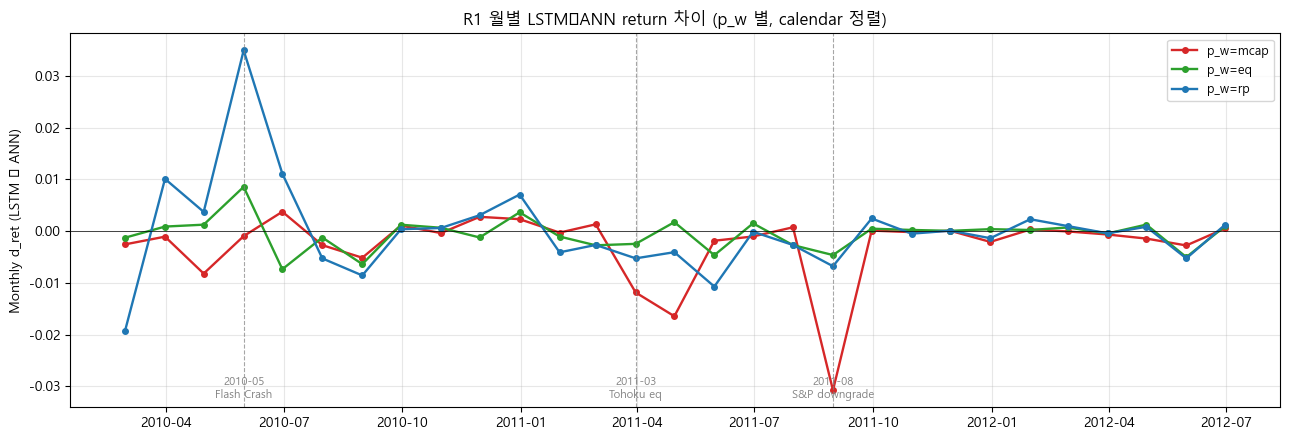

In [13]:
# ── [5] R1 catastrophic months 분해 (calendar 정렬) ─────────────
R1_START = pd.Timestamp('2010-01-31')
R1_END   = pd.Timestamp('2012-06-30')

PRIORS=['mcap','eq','rp']; PW=['mcap','eq','rp']; Q=['lam','raw','inv','vsp','fpm']

diff_data = {}
for pw in PW:
    for pr in PRIORS:
        for q in Q:
            L = f'mat_{pr}_{pw}_{q}_pap'; A = L + '_ann'
            if L not in loaded or A not in loaded: continue
            rL = loaded[L]['ret'].dropna()
            rA = loaded[A]['ret'].dropna()
            common = rL.index.intersection(rA.index)
            d = rL.loc[common] - rA.loc[common]
            d.index = d.index + pd.offsets.MonthEnd(1)
            mask = (d.index >= R1_START) & (d.index <= R1_END)
            diff_data[(pw, pr, q)] = d[mask]

df_diff = pd.DataFrame(diff_data)
print(f'R1 (calendar) 월 수: {len(df_diff)}, 슬롯 수: {df_diff.shape[1]}')

pw_avg  = {pw: df_diff[[c for c in df_diff.columns if c[0]==pw]].mean(axis=1) for pw in PW}
all_avg = df_diff.mean(axis=1)

print('\n' + '='*78)
print('R1 월별 LSTM-ANN return 차이 (p_w 별 15-슬롯 평균, calendar 기준)')
print('='*78)
hdr = f'{"month":<10s}' + ''.join(f'{pw:>14s}' for pw in PW) + f'{"All 45":>14s}'
print(hdr); print('-'*len(hdr))
for dt in df_diff.index:
    row = [pw_avg[pw][dt] for pw in PW]
    print(f'{dt.strftime("%Y-%m"):<10s}' + ''.join(f'{v:>+14.4f}' for v in row) + f'{all_avg[dt]:>+14.4f}')

print('\n' + '='*78)
print('p_w 별 LSTM 최악 월 — worst 5 (calendar month, mean d_ret across 15 slots)')
print('='*78)
for pw in PW:
    worst5 = pw_avg[pw].nsmallest(5)
    print(f'\n[p_w={pw}]')
    for dt, v in worst5.items():
        print(f'  {dt.strftime("%Y-%m"):<10s}: {v:+.4f}')

print('\n' + '='*78)
print('R1 cumulative LSTM-ANN gap — catastrophic months 의 기여도')
print('='*78)
print(f'{"제거 대상":<28s}{"mcap":>12s}{"eq":>12s}{"rp":>12s}')
print('-'*64)

scenarios = [
    ('전체 (제거 없음)',           []),
    ('2011-08 (S&P downgrade)',    ['2011-08']),
    ('2011-08 + 2011-04 + 2011-03', ['2011-08','2011-04','2011-03']),
]
for label, excl_ym in scenarios:
    cells = []
    for pw in PW:
        s = pw_avg[pw]
        if not excl_ym:
            total = s.sum()
        else:
            kept = s[~s.index.strftime('%Y-%m').isin(excl_ym)]
            total = kept.sum()
        cells.append(f'{total:+12.4f}')
    print(f'{label:<28s}' + ''.join(cells))

cells = []
for pw in PW:
    s = pw_avg[pw]
    worst5_idx = s.nsmallest(5).index
    kept = s.drop(worst5_idx)
    cells.append(f'{kept.sum():+12.4f}')
print(f'{"top 5 worst (per p_w) 제거":<28s}' + ''.join(cells))

fig, ax = plt.subplots(figsize=(13, 4.5))
for pw, color in zip(PW, ['#d62728', '#2ca02c', '#1f77b4']):
    ax.plot(pw_avg[pw].index, pw_avg[pw].values, label=f'p_w={pw}',
            color=color, lw=1.7, marker='o', markersize=4)
ax.axhline(0, color='black', lw=0.5)

events = [('2010-05','Flash Crash'),('2011-03','Tohoku eq'),('2011-08','S&P downgrade')]
ylim = ax.get_ylim()
for ym, lbl in events:
    matches = [dt for dt in pw_avg['mcap'].index if dt.strftime('%Y-%m') == ym]
    if matches:
        dt = matches[0]
        ax.axvline(dt, color='gray', ls='--', lw=0.8, alpha=0.7)
        ax.annotate(f'{ym}\n{lbl}', xy=(dt, ylim[0]*0.95),
                    fontsize=8, ha='center', color='gray')

ax.set_title('R1 월별 LSTM−ANN return 차이 (p_w 별, calendar 정렬)')
ax.set_ylabel('Monthly d_ret (LSTM − ANN)')
ax.legend(loc='best', fontsize=9)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


## [6] Q × regime × p_w timeline grid

regime 별로 5 Q 가 세로 stacked, 각 subplot 에 p_w 3 라인. event annotation 포함.

- 5 row (Q: lam/raw/inv/vsp/fpm) × 4 regime (R1/R2/R3/R4) figure
- 각 subplot 의 3 라인 = p_w (mcap/eq/rp) 의 3-prior 평균
- 모든 시간 축은 **calendar 정렬** (+1 MonthEnd shift)


Q × regime 월평균 LSTM−ANN return  (각 셀: 3 prior × 3 p_w = 9 슬롯 평균)
Q                     R1              R2              R3              R4     all (10y)
--------------------------------------------------------------------------------------
lam              -0.0011         -0.0008         +0.0046         +0.0007       +0.0006
raw              -0.0010         -0.0008         +0.0046         +0.0007       +0.0006
inv              -0.0007         -0.0000         +0.0024         +0.0004       +0.0005
vsp              -0.0010         -0.0003         +0.0031         +0.0002       +0.0004
fpm              -0.0016         +0.0011         +0.0014         +0.0012       +0.0008


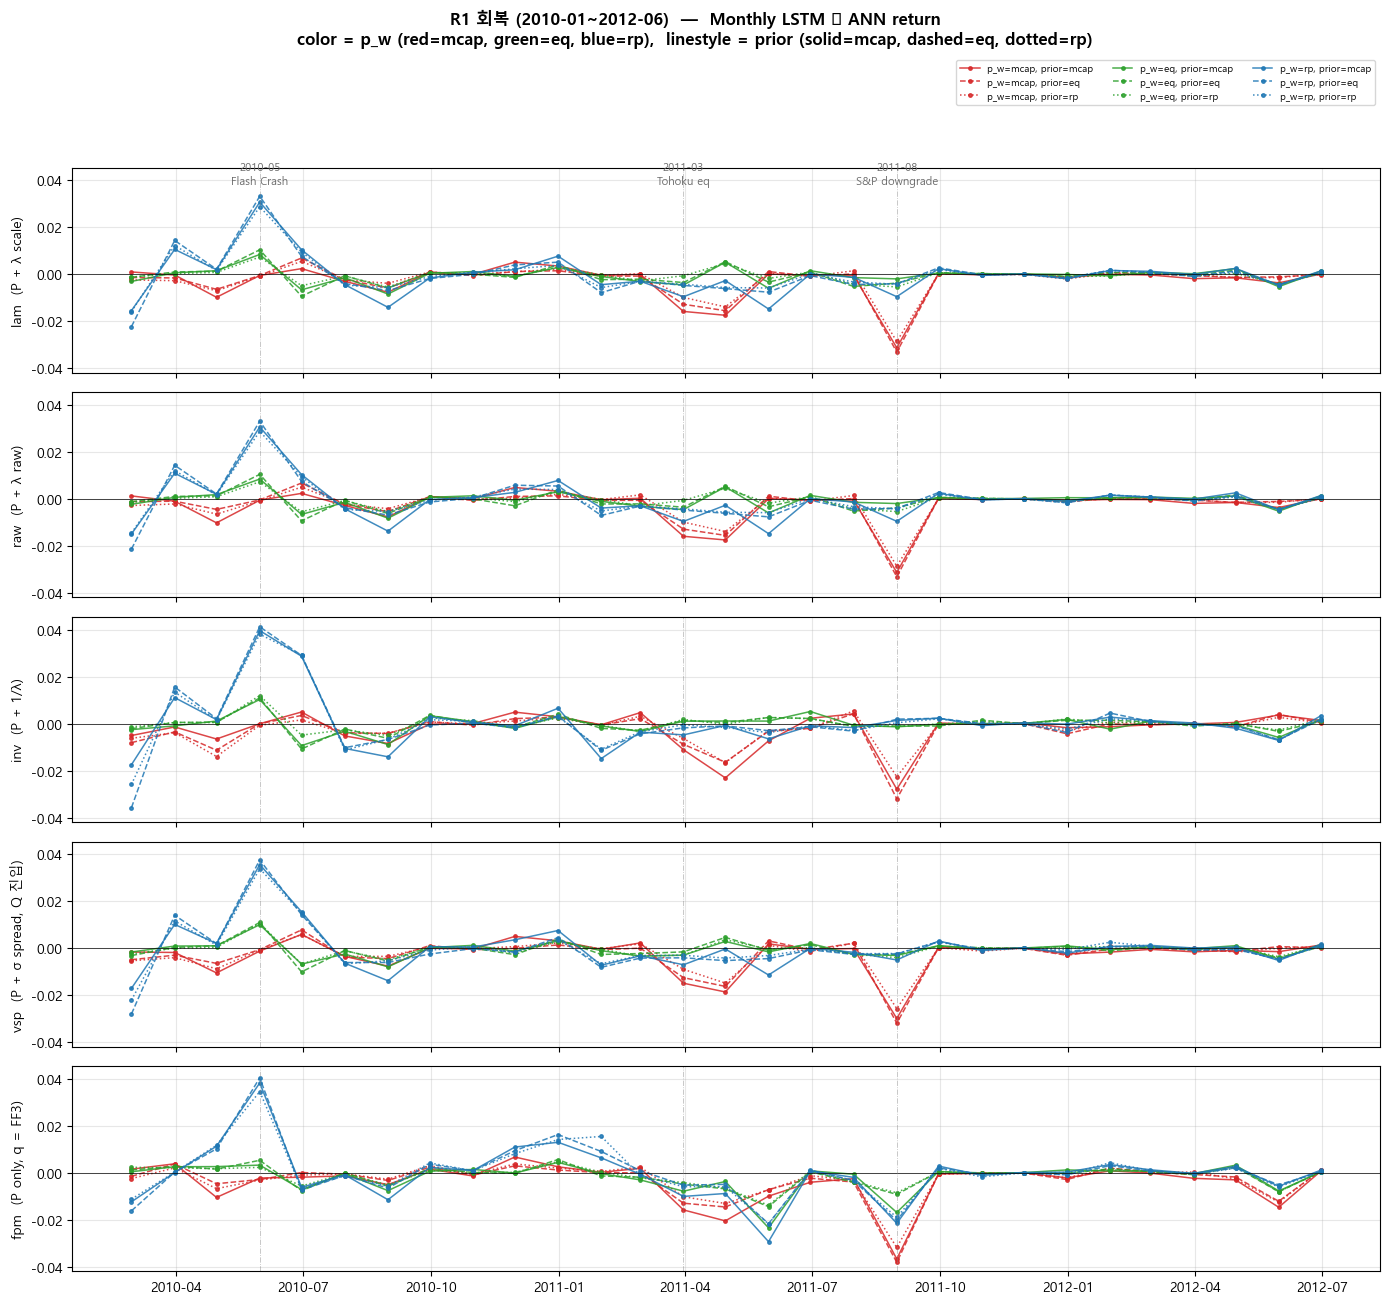

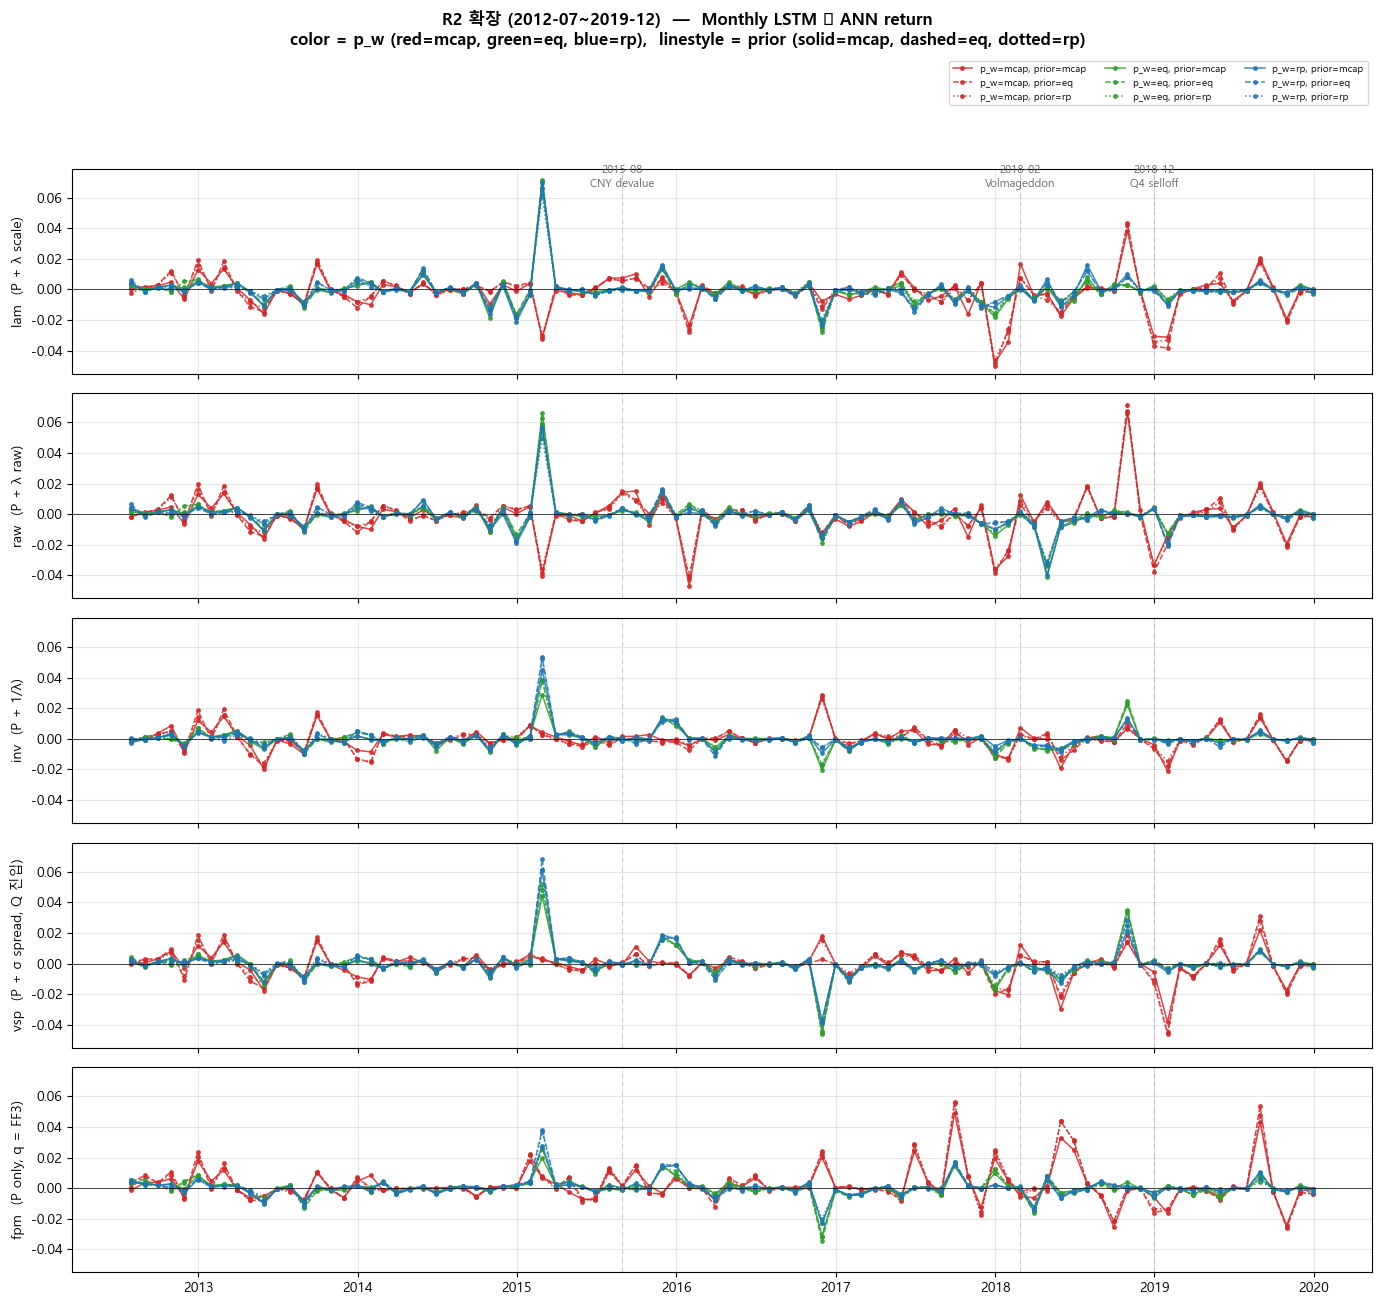

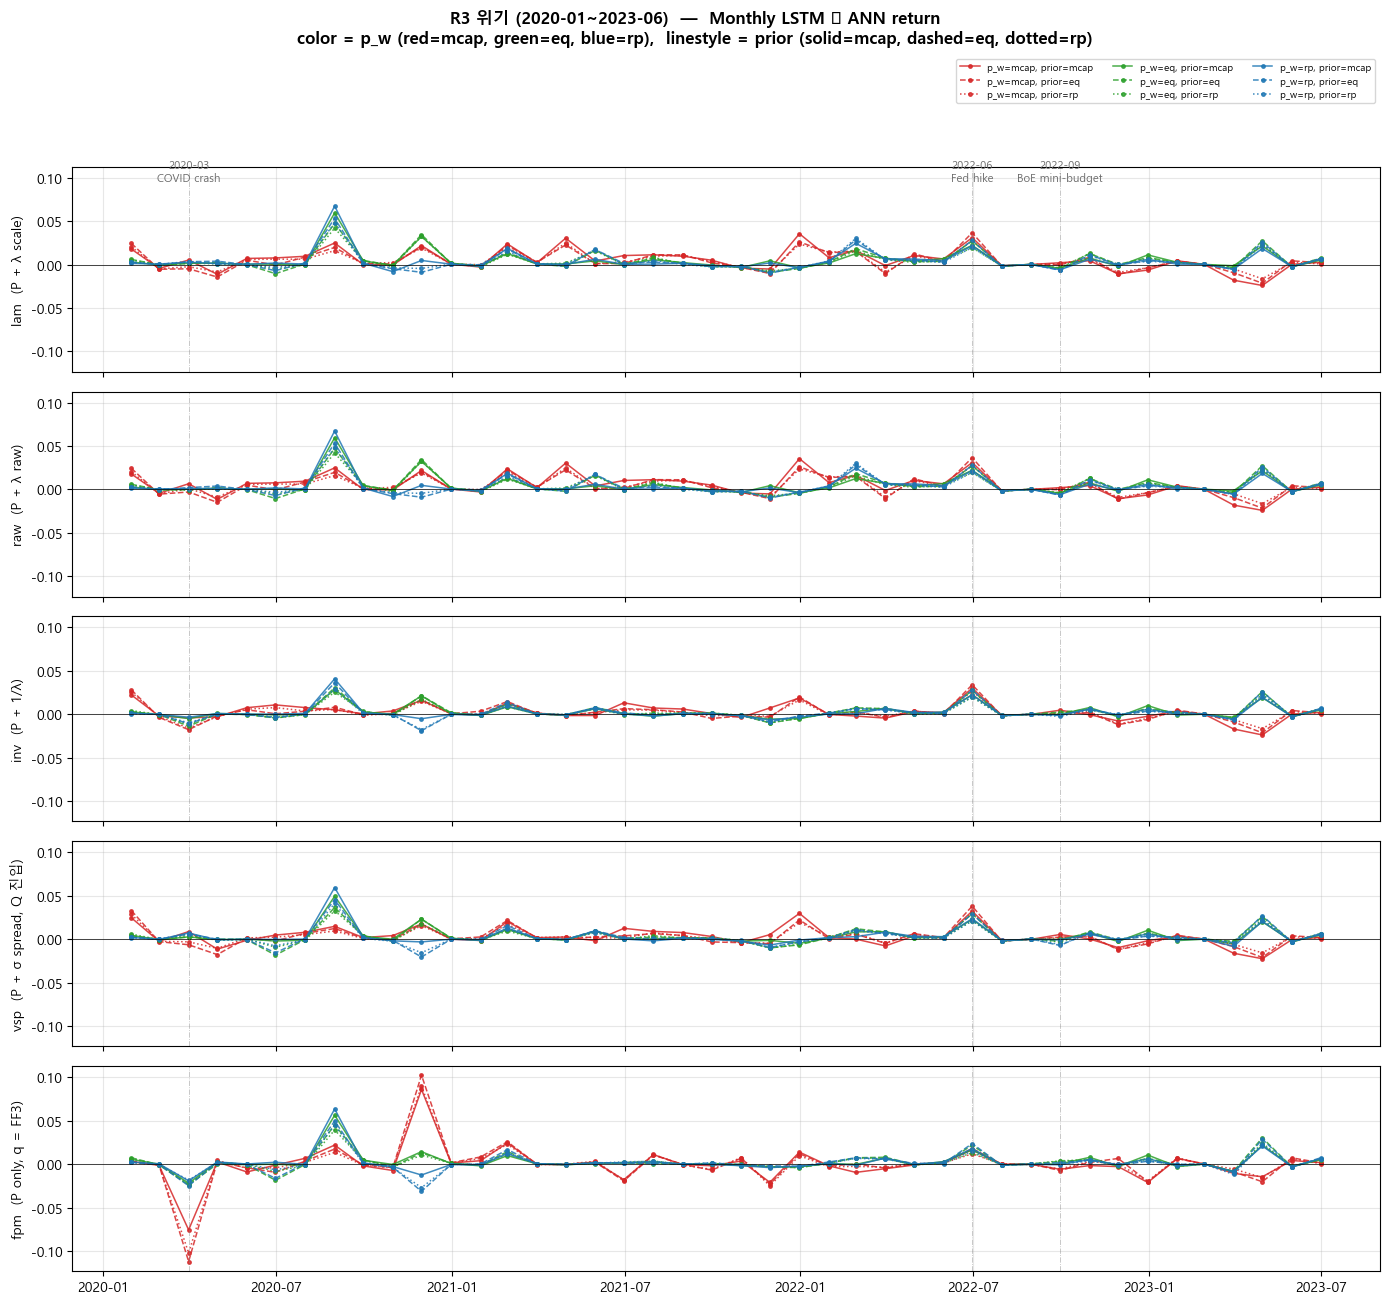

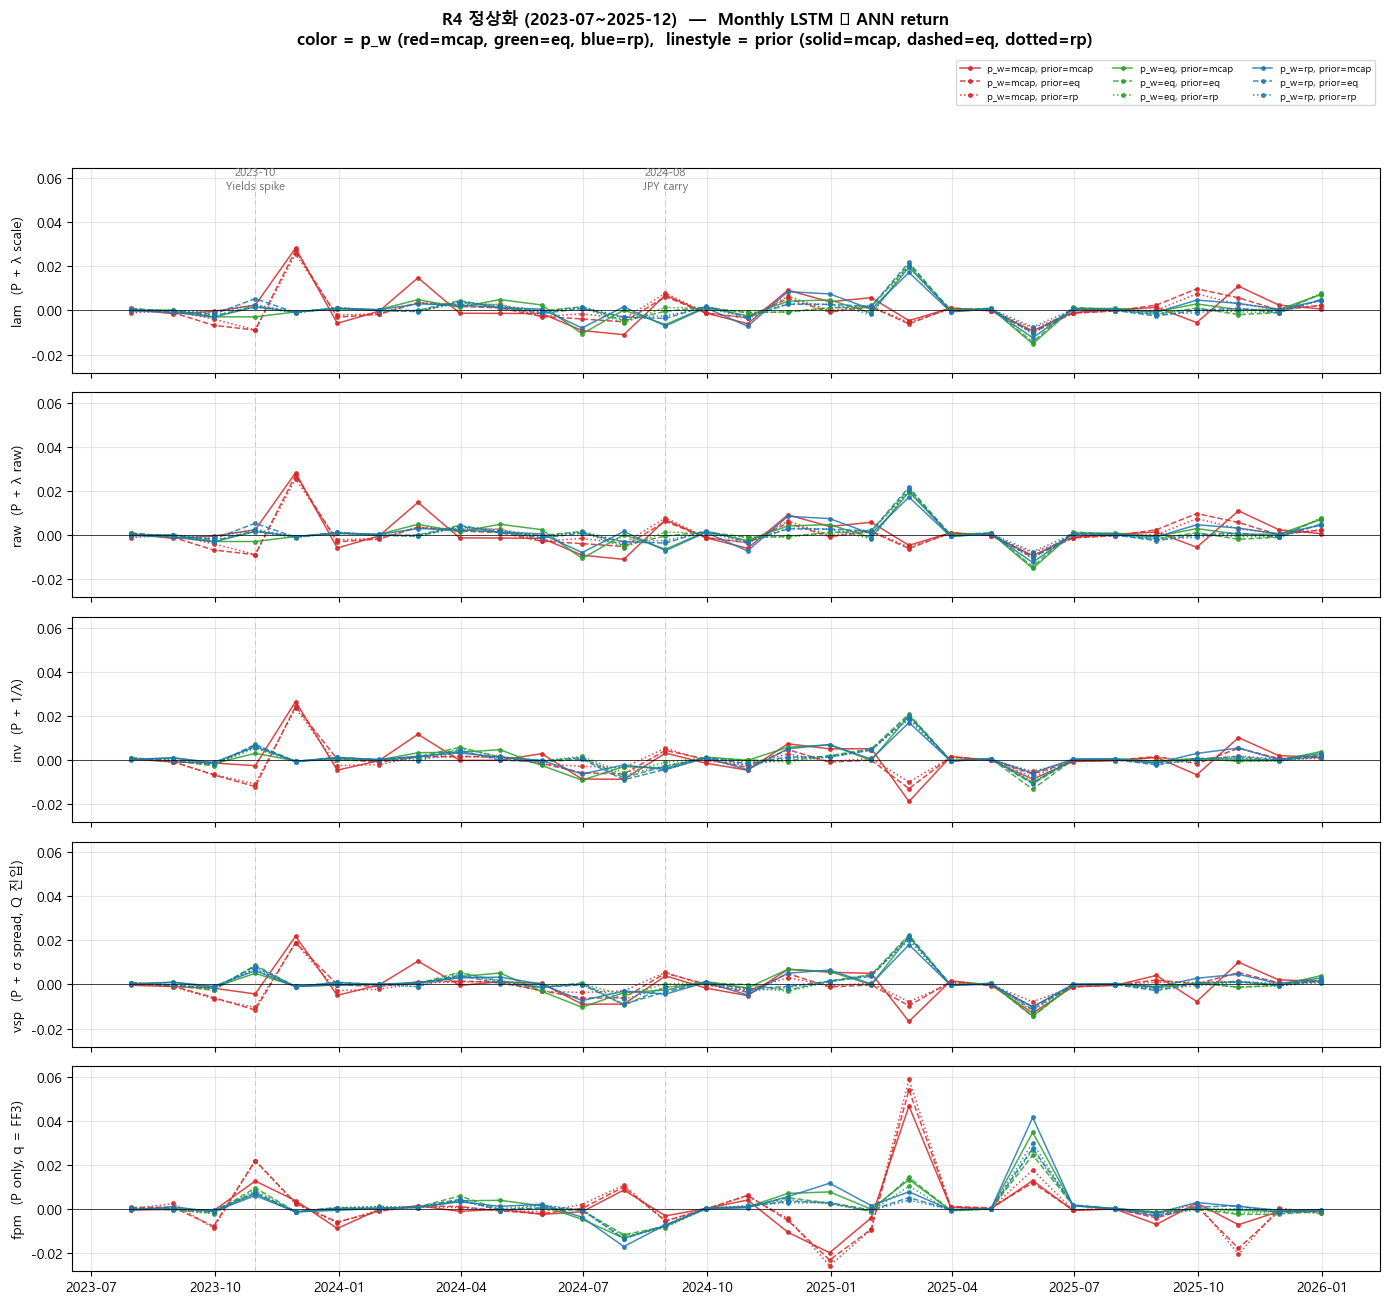

In [14]:
# ── [6] Q × regime × (prior × p_w) timeline — 9 라인 per subplot ──
REGIME_PERIODS = {
    'R1 회복 (2010-01~2012-06)':    (pd.Timestamp('2010-01-31'), pd.Timestamp('2012-06-30')),
    'R2 확장 (2012-07~2019-12)':    (pd.Timestamp('2012-07-31'), pd.Timestamp('2019-12-31')),
    'R3 위기 (2020-01~2023-06)':    (pd.Timestamp('2020-01-31'), pd.Timestamp('2023-06-30')),
    'R4 정상화 (2023-07~2025-12)':  (pd.Timestamp('2023-07-31'), pd.Timestamp('2025-12-31')),
}
REGIME_EVENTS = {
    'R1 회복 (2010-01~2012-06)': [('2010-05','Flash Crash'),('2011-03','Tohoku eq'),('2011-08','S&P downgrade')],
    'R2 확장 (2012-07~2019-12)': [('2015-08','CNY devalue'),('2018-02','Volmageddon'),('2018-12','Q4 selloff')],
    'R3 위기 (2020-01~2023-06)': [('2020-03','COVID crash'),('2022-06','Fed hike'),('2022-09','BoE mini-budget')],
    'R4 정상화 (2023-07~2025-12)': [('2023-10','Yields spike'),('2024-08','JPY carry')],
}
PRIORS=['mcap','eq','rp']; PW=['mcap','eq','rp']; Q=['lam','raw','inv','vsp','fpm']
Q_LABEL = {'lam':'lam  (P + λ scale)','raw':'raw  (P + λ raw)',
           'inv':'inv  (P + 1/λ)','vsp':'vsp  (P + σ spread, Q 진입)',
           'fpm':'fpm  (P only, q = FF3)'}
pw_colors = {'mcap':'#d62728', 'eq':'#2ca02c', 'rp':'#1f77b4'}
prior_styles = {'mcap':'-', 'eq':'--', 'rp':':'}   # solid / dashed / dotted

def build_one(start, end, q, pw, pr):
    L = f'mat_{pr}_{pw}_{q}_pap'; A = L + '_ann'
    if L not in loaded or A not in loaded: return pd.Series(dtype=float)
    rL = loaded[L]['ret'].dropna(); rA = loaded[A]['ret'].dropna()
    common = rL.index.intersection(rA.index)
    d = rL.loc[common] - rA.loc[common]
    d.index = d.index + pd.offsets.MonthEnd(1)
    return d[(d.index>=start)&(d.index<=end)]

# 평균표 (전체 9 슬롯 평균; reference)
print('='*86)
print('Q × regime 월평균 LSTM−ANN return  (각 셀: 3 prior × 3 p_w = 9 슬롯 평균)')
print('='*86)
print(f'{"Q":<8s}' + ''.join(f'{r.split()[0]:>16s}' for r in REGIME_PERIODS) + f'{"all (10y)":>14s}')
print('-'*86)
for q in Q:
    cells = []
    for label, (s, e) in REGIME_PERIODS.items():
        vals = []
        for pw in PW:
            for pr in PRIORS:
                vals.append(build_one(s,e,q,pw,pr).mean())
        cells.append(np.nanmean(vals))
    all_vals = []
    for pw in PW:
        for pr in PRIORS:
            L = f'mat_{pr}_{pw}_{q}_pap'; A = L+'_ann'
            if L not in loaded or A not in loaded: continue
            rL = loaded[L]['ret'].dropna(); rA = loaded[A]['ret'].dropna()
            common = rL.index.intersection(rA.index)
            all_vals.append((rL.loc[common]-rA.loc[common]).mean())
    print(f'{q:<8s}' + ''.join(f'{v:>+16.4f}' for v in cells) + f'{np.mean(all_vals):>+14.4f}')

# regime 별 figure — 5 Q rows × 1 col, 각 subplot 에 9 라인 (3 prior × 3 p_w)
for rlabel, (s, e) in REGIME_PERIODS.items():
    series = {q: {pw: {pr: build_one(s,e,q,pw,pr) for pr in PRIORS} for pw in PW} for q in Q}
    all_vals = [v for q in Q for pw in PW for pr in PRIORS for v in series[q][pw][pr].values]
    ymin, ymax = min(all_vals)*1.1, max(all_vals)*1.1

    fig, axes = plt.subplots(len(Q), 1, figsize=(14, 13), sharex=True)
    for i, q in enumerate(Q):
        ax = axes[i]
        for pw in PW:
            for pr in PRIORS:
                ser = series[q][pw][pr]
                if len(ser)==0: continue
                label = (f'p_w={pw}, prior={pr}' if i==0 else None)
                ax.plot(ser.index, ser.values,
                        color=pw_colors[pw], linestyle=prior_styles[pr],
                        lw=1.1, marker='o', markersize=2.5, alpha=0.85,
                        label=label)
        ax.axhline(0, color='black', lw=0.5)
        ax.set_ylim(ymin, ymax)
        ax.set_ylabel(Q_LABEL[q], fontsize=10)
        ax.grid(True, alpha=0.3)
        for ym, ev in REGIME_EVENTS.get(rlabel, []):
            matches = [dt for dt in series[q]['mcap']['mcap'].index if dt.strftime('%Y-%m') == ym]
            if matches:
                dt = matches[0]
                ax.axvline(dt, color='gray', ls='-.', lw=0.6, alpha=0.5)
                if i == 0:
                    ax.annotate(f'{ym}\n{ev}', xy=(dt, ymax*0.85),
                                fontsize=8, ha='center', color='dimgray')

    axes[0].legend(loc='upper right', fontsize=7, ncol=3,
                    bbox_to_anchor=(1.0, 1.55))
    fig.suptitle(f'{rlabel}  —  Monthly LSTM − ANN return\n'
                  f'color = p_w (red=mcap, green=eq, blue=rp),  '
                  f'linestyle = prior (solid=mcap, dashed=eq, dotted=rp)',
                  fontsize=12, fontweight='bold', y=1.00)
    plt.tight_layout()
    plt.show()


R3 (2020-01~2023-06)  —  LSTM vs ANN vs SPY  누적수익률 & SPY 부호별 평균
slot                                  n_up     L_up     A_up     Δ_up  n_dn     L_dn     A_dn     Δ_dn    cumL    cumA
----------------------------------------------------------------------------------------------------
anchor — mcap/mcap/fpm                  26   +4.70%   +4.22%  +0.478%    16   -4.20%   -3.42%  -0.781%   1.615   1.650
LSTM-best — mcap/eq/fpm                 26   +4.31%   +3.89%  +0.416%    16   -3.56%   -3.63%  +0.062%   1.651   1.471
rp/rp/lam (Q=lam, sign-fixed)           26   +4.03%   +3.58%  +0.447%    16   -3.09%   -3.38%  +0.292%   1.654   1.407
eq/eq/fpm (eq prior + fpm)              26   +4.45%   +4.11%  +0.339%    16   -3.36%   -3.50%  +0.135%   1.752   1.574


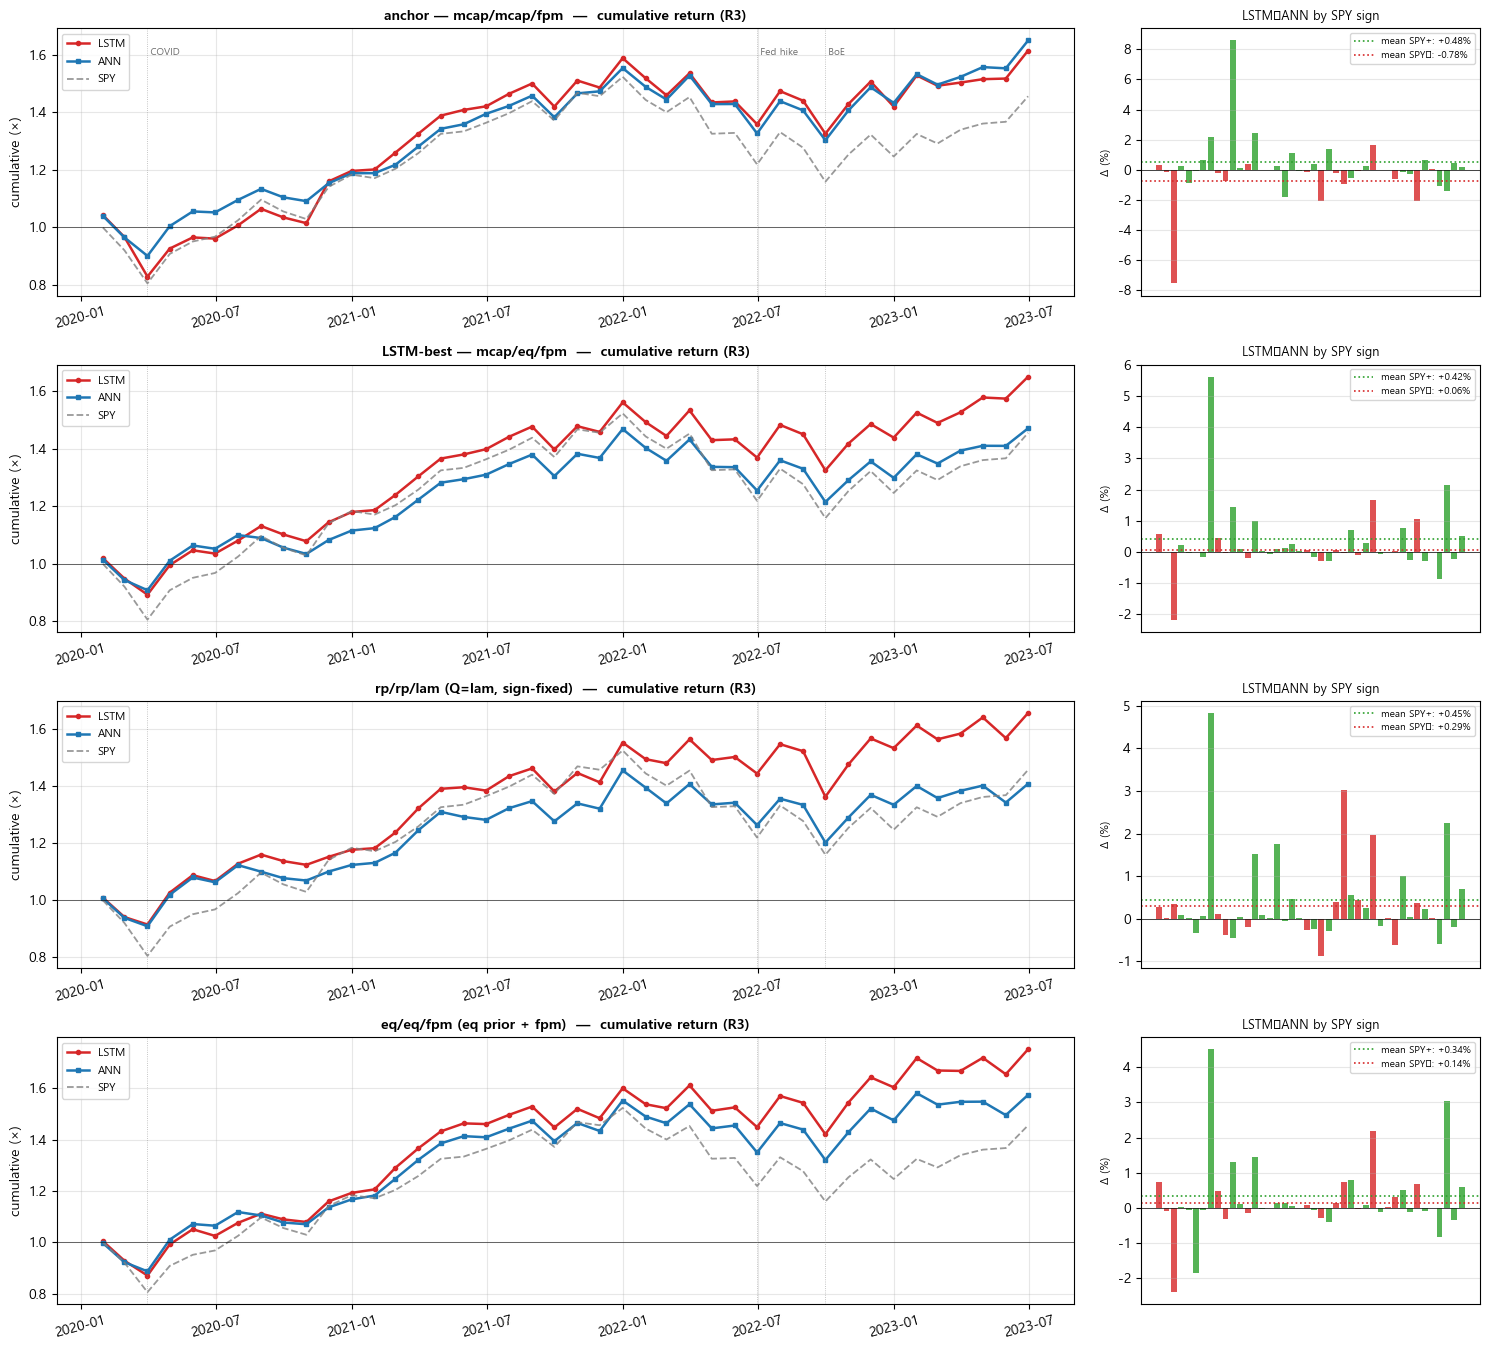

In [15]:
# ── [6b] R3 누적수익률 — LSTM vs ANN vs SPY (4 슬롯, Q 다양화) ─────
# [6] 의 LSTM−ANN 차이가 반등 캡처에서 오는지 / 하락 방어에서 오는지 구분
# Q 가 다르면 (fpm vs lam) 방어 패턴이 달라질 수 있음 → 함께 비교
R3_S = pd.Timestamp('2020-01-31')
R3_E = pd.Timestamp('2023-06-30')

R3_SLOTS = {
    'anchor — mcap/mcap/fpm':           'mat_mcap_mcap_fpm_pap',
    'LSTM-best — mcap/eq/fpm':          'mat_mcap_eq_fpm_pap',
    'rp/rp/lam (Q=lam, sign-fixed)':    'mat_rp_rp_lam_pap',
    'eq/eq/fpm (eq prior + fpm)':       'mat_eq_eq_fpm_pap',
}

def _shifted_ret(name):
    """ pkl ret (construction date) → calendar end date ([6] 과 동일 shift). """
    r = loaded[name]['ret'].dropna()
    r.index = r.index + pd.offsets.MonthEnd(1)
    return r

# SPY 동일 shift
spy_full = loaded['mat_mcap_mcap_fpm_pap']['spy_ret'].dropna()
spy_full.index = spy_full.index + pd.offsets.MonthEnd(1)

fig, axes = plt.subplots(len(R3_SLOTS), 2, figsize=(15, 3.4*len(R3_SLOTS)),
                          gridspec_kw={'width_ratios':[3, 1]})
if len(R3_SLOTS)==1: axes = axes.reshape(1, -1)

print('='*100)
print('R3 (2020-01~2023-06)  —  LSTM vs ANN vs SPY  누적수익률 & SPY 부호별 평균')
print('='*100)
print(f'{"slot":<36s}{"n_up":>6s}{"L_up":>9s}{"A_up":>9s}{"Δ_up":>9s}'
      f'{"n_dn":>6s}{"L_dn":>9s}{"A_dn":>9s}{"Δ_dn":>9s}{"cumL":>8s}{"cumA":>8s}')
print('-'*100)

for i, (label, slot_name) in enumerate(R3_SLOTS.items()):
    if slot_name not in loaded or (slot_name + '_ann') not in loaded:
        print(f'[skip] {slot_name} not loaded'); continue
    rL = _shifted_ret(slot_name); rA = _shifted_ret(slot_name + '_ann')
    common = rL.index.intersection(rA.index).intersection(spy_full.index)
    common_r3 = common[(common>=R3_S) & (common<=R3_E)]
    rL_r3 = rL.loc[common_r3]; rA_r3 = rA.loc[common_r3]; rS_r3 = spy_full.loc[common_r3]

    cumL = (1+rL_r3).cumprod(); cumA = (1+rA_r3).cumprod(); cumS = (1+rS_r3).cumprod()
    diff = rL_r3 - rA_r3

    rL_up = rL_r3[rS_r3>0]; rA_up = rA_r3[rS_r3>0]
    rL_dn = rL_r3[rS_r3<0]; rA_dn = rA_r3[rS_r3<0]
    d_up = (rL_up-rA_up).mean()*100; d_dn = (rL_dn-rA_dn).mean()*100
    print(f'{label:<36s}{len(rL_up):>6d}{rL_up.mean()*100:>+8.2f}%{rA_up.mean()*100:>+8.2f}%{d_up:>+8.3f}%'
          f'{len(rL_dn):>6d}{rL_dn.mean()*100:>+8.2f}%{rA_dn.mean()*100:>+8.2f}%{d_dn:>+8.3f}%'
          f'{cumL.iloc[-1]:>8.3f}{cumA.iloc[-1]:>8.3f}')

    # 좌측: 누적수익률
    ax = axes[i, 0]
    ax.plot(cumL.index, cumL.values, lw=1.8, color='#d62728', label='LSTM', marker='o', markersize=3)
    ax.plot(cumA.index, cumA.values, lw=1.8, color='#1f77b4', label='ANN',  marker='s', markersize=3)
    ax.plot(cumS.index, cumS.values, lw=1.3, color='gray',    label='SPY',  linestyle='--', alpha=0.8)
    ax.axhline(1.0, color='black', lw=0.4)
    for ym, ev in [('2020-03','COVID'),('2022-06','Fed hike'),('2022-09','BoE')]:
        matches = [dt for dt in common_r3 if dt.strftime('%Y-%m')==ym]
        if matches:
            ax.axvline(matches[0], color='gray', ls=':', lw=0.6, alpha=0.6)
            if i==0:
                ax.text(matches[0], ax.get_ylim()[1]*0.96, f' {ev}',
                        fontsize=7, color='dimgray', va='top')
    ax.set_title(f'{label}  —  cumulative return (R3)', fontsize=10, fontweight='bold')
    ax.set_ylabel('cumulative (×)')
    ax.legend(loc='upper left', fontsize=8)
    ax.grid(True, alpha=0.3)
    ax.tick_params(axis='x', rotation=15)

    # 우측: SPY sign 별 LSTM−ANN bar
    ax = axes[i, 1]
    colors = ['#2ca02c' if s>0 else '#d62728' for s in rS_r3]
    ax.bar(range(len(diff)), diff.values*100, color=colors, alpha=0.8)
    ax.axhline(0, color='black', lw=0.5)
    ax.axhline(d_up, color='#2ca02c', ls=':', lw=1.2, label=f'mean SPY+: {d_up:+.2f}%')
    ax.axhline(d_dn, color='#d62728', ls=':', lw=1.2, label=f'mean SPY−: {d_dn:+.2f}%')
    ax.set_title('LSTM−ANN by SPY sign', fontsize=9)
    ax.set_ylabel('Δ (%)', fontsize=8)
    ax.set_xticks([]); ax.grid(True, alpha=0.3, axis='y')
    ax.legend(loc='best', fontsize=7)

plt.tight_layout()
plt.show()


## [7] fpm Q 시계열 분석 — sign behavior

**목적**: 양수 제약 Q (lam/raw/inv/vsp) 와 fpm 의 본질적 차이를 데이터로 입증.

- 양수 제약 Q: 구조적으로 q 항상 양수 ("long low-vol / short high-vol" view 고정)
- fpm: FF3 OLS 평균으로 q 산출, **sign-flexible** (regime 따라 view 방향 바뀜)

**가설**:
- R4 (AI 랠리) 에서 fpm 우위 = q 가 음수로 → high-vol view 가 AI 종목 강세에 적합
- R3 에서 mcap-mcap-fpm 부진 = 위기에 high-vol view 가 손해

`mat_mcap_mcap_fpm_pap` 의 `meta['Q']` 시계열로 확인.


q^ff3 value sign distribution by regime (calendar 정렬)
  q > 0 = long low-vol / short high-vol view
  q < 0 = long high-vol / short low-vol view (sign flip)
regime          n_mo      mean q      median     % q<0         min         max
------------------------------------------------------------------------------
All              192    -0.00224    -0.00127     63.0%    -0.02185    +0.01025
------------------------------------------------------------------------------
R1 회복             30    +0.00012    +0.00047     43.3%    -0.00414    +0.00460
R2 확장             90    -0.00105    -0.00121     61.1%    -0.00903    +0.00926
R3 위기             42    -0.00091    -0.00162     69.0%    -0.00960    +0.01025
R4 정상화            30    -0.01003    -0.01350     80.0%    -0.02185    +0.00479

참고: q^lam (lambda_q-based) 의 음수 비율
  All: 0.0%, mean=+0.00588
  → lambda_q-based 는 구조상 항상 양수, q^ff3 만 sign-flexible


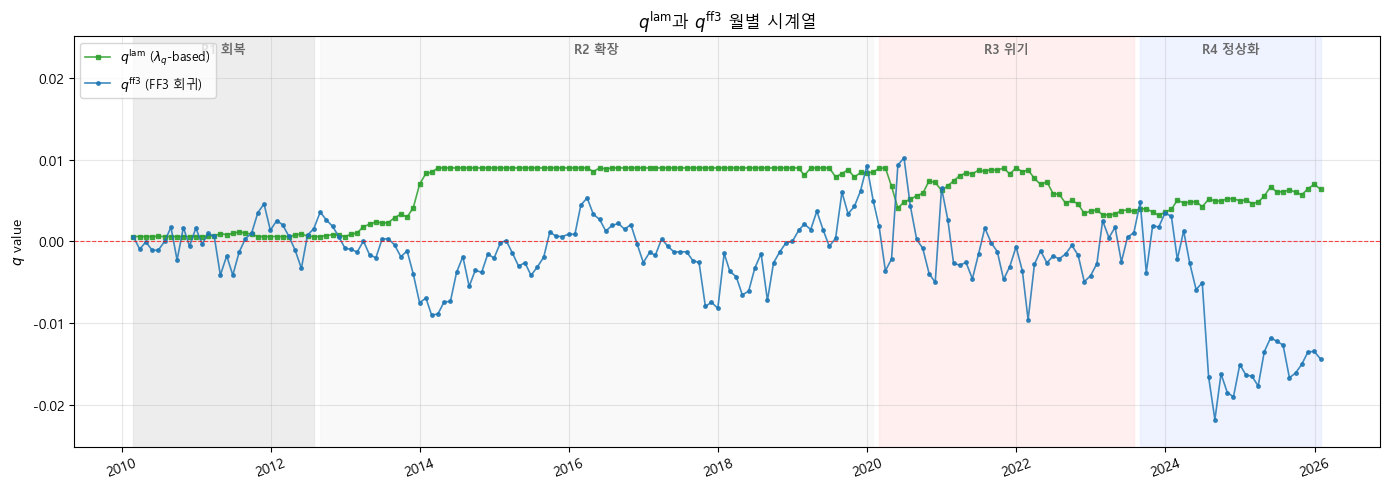

In [16]:
# ── [7] q^lam vs q^ff3 시계열 sign analysis ────────────────────
fpm_meta = loaded['mat_mcap_mcap_fpm_pap']['meta']
q_fpm = fpm_meta['Q'].copy()
q_fpm_cal = q_fpm.copy()
q_fpm_cal.index = q_fpm_cal.index + pd.offsets.MonthEnd(1)

REGIMES_T = {
    'R1 회복':   (pd.Timestamp('2010-02-28'), pd.Timestamp('2012-07-31')),
    'R2 확장':   (pd.Timestamp('2012-08-31'), pd.Timestamp('2020-01-31')),
    'R3 위기':   (pd.Timestamp('2020-02-29'), pd.Timestamp('2023-07-31')),
    'R4 정상화': (pd.Timestamp('2023-08-31'), pd.Timestamp('2026-01-31')),
}

print('='*80)
print('q^ff3 value sign distribution by regime (calendar 정렬)')
print('  q > 0 = long low-vol / short high-vol view')
print('  q < 0 = long high-vol / short low-vol view (sign flip)')
print('='*80)
print(f'{"regime":<14s}{"n_mo":>6s}{"mean q":>12s}{"median":>12s}{"% q<0":>10s}{"min":>12s}{"max":>12s}')
print('-'*78)
all_neg = (q_fpm_cal < 0).mean()*100
print(f'{"All":<14s}{len(q_fpm_cal):>6d}{q_fpm_cal.mean():>+12.5f}{q_fpm_cal.median():>+12.5f}{all_neg:>9.1f}%{q_fpm_cal.min():>+12.5f}{q_fpm_cal.max():>+12.5f}')
print('-'*78)
for lbl, (s, e) in REGIMES_T.items():
    sub = q_fpm_cal[(q_fpm_cal.index>=s)&(q_fpm_cal.index<=e)]
    if len(sub)==0: continue
    neg_pct = (sub<0).mean()*100
    print(f'{lbl:<14s}{len(sub):>6d}{sub.mean():>+12.5f}{sub.median():>+12.5f}{neg_pct:>9.1f}%{sub.min():>+12.5f}{sub.max():>+12.5f}')

lam_meta = loaded['mat_mcap_mcap_lam_pap']['meta']
q_lam = lam_meta['Q'].copy()
q_lam_cal = q_lam.copy(); q_lam_cal.index = q_lam_cal.index + pd.offsets.MonthEnd(1)
print('\n참고: q^lam (lambda_q-based) 의 음수 비율')
print(f'  All: {(q_lam_cal<0).mean()*100:.1f}%, mean={q_lam_cal.mean():+.5f}')
print(f'  → lambda_q-based 는 구조상 항상 양수, q^ff3 만 sign-flexible')

# ── 그림: q^lam vs q^ff3 timeline (단일 panel) ──
fig, ax = plt.subplots(1, 1, figsize=(14, 5))

regime_colors = {'R1 회복':'#dddddd', 'R2 확장':'#f5f5f5', 'R3 위기':'#ffe0e0', 'R4 정상화':'#e0e8ff'}
ylim_buf = max(abs(q_fpm_cal.min()), abs(q_fpm_cal.max()),
               abs(q_lam_cal.min()), abs(q_lam_cal.max())) * 1.15

for lbl, (s, e) in REGIMES_T.items():
    ax.axvspan(s, e, color=regime_colors[lbl], alpha=0.5, zorder=0)
    mid = s + (e - s)/2
    ax.text(mid, ylim_buf*0.92, lbl, ha='center', fontsize=9, color='dimgray', fontweight='bold')

ax.plot(q_lam_cal.index, q_lam_cal.values, color='#2ca02c', lw=1.2, marker='s',
        markersize=2.5, label=r'$q^{\mathrm{lam}}$ ($\lambda_q$-based)', alpha=0.85)
ax.plot(q_fpm_cal.index, q_fpm_cal.values, color='#1f77b4', lw=1.2, marker='o',
        markersize=2.5, label=r'$q^{\mathrm{ff3}}$ (FF3 회귀)', alpha=0.85)
ax.axhline(0, color='red', lw=0.8, ls='--', alpha=0.7)

ax.set_ylabel(r'$q$ value')
ax.set_title(r'$q^{\mathrm{lam}}$과 $q^{\mathrm{ff3}}$ 월별 시계열')
ax.set_ylim(-ylim_buf, ylim_buf)
ax.legend(loc='upper left', fontsize=9)
ax.grid(True, alpha=0.3)
ax.tick_params(axis='x', rotation=20)

plt.tight_layout()
# plt.savefig('Figure/r4_fpm_lam.png', dpi=150, bbox_inches='tight')
plt.show()


## [9] R4 mechanism — fpm q 부호별 bucket weight + AI 섹터 노출

**가설**:
1. **fpm q 음수 ↔ portfolio 가 high-vol 종목 over-weight** (BL view flip → long high-vol short low-vol)
2. **mcap prior → AI/Tech 섹터 over-weight** (대형주가 IT/Communication 섹터에 집중)

**확인 방법**:
1. fpm 슬롯 (`mat_mcap_mcap_fpm_pap`) 의 월별 q 값 (meta) + 그달 portfolio 의 low-vol bucket weight 합, high-vol bucket weight 합 → q<0 month 에서 high > low 인지 직접 확인
2. R4 의 각 prior (mcap/eq/rp) 별 fpm 슬롯 portfolio 의 **IT + Tech + Communication Services 섹터 weight 합** → prior=mcap 가 가장 높은지 확인


(1) fpm q 부호별 bucket weight — slot = mat_mcap_mcap_fpm_pap
    R4 (2023-07~2025-12) 의 월별 q 값과 portfolio 의 σ bucket weight
month         q_fpm  q sign   low30%w    hi30%w    hi−low
------------------------------------------------------------
2023-07    +0.00479   양 (+)    46.21%    10.33%   -35.88%
2023-08    -0.00382   음 (−)    34.86%    30.03%    -4.83%
2023-09    +0.00192   양 (+)    62.60%     0.51%   -62.09%
2023-10    +0.00177   양 (+)    46.24%    21.40%   -24.84%
2023-11    +0.00349   양 (+)    58.95%     6.08%   -52.87%
2023-12    +0.00305   양 (+)    44.09%    15.60%   -28.49%
2024-01    -0.00219   음 (−)    37.59%    22.43%   -15.16%
2024-02    +0.00129   양 (+)    54.92%    15.90%   -39.02%
2024-03    -0.00269   음 (−)    43.43%    11.94%   -31.49%
2024-04    -0.00590   음 (−)    25.98%    29.16%    +3.18%
2024-05    -0.00507   음 (−)    33.79%    21.05%   -12.74%
2024-06    -0.01656   음 (−)     8.99%    55.25%   +46.26%
2024-07    -0.02185   음 (−)    17.29%    37.86%   +20.57%
2024-

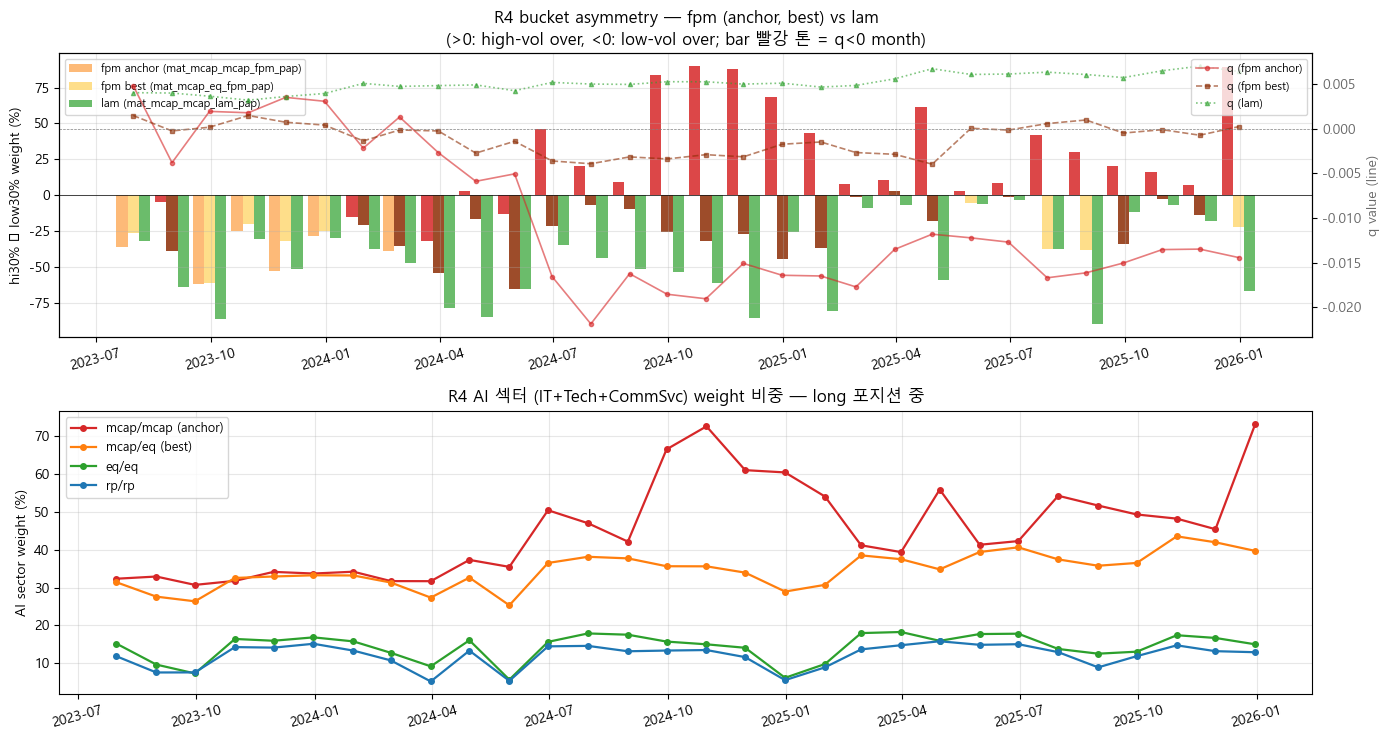

In [17]:
# ── [9] R4 mechanism — fpm q sign + AI 섹터 노출 ──────────────
R4_S = pd.Timestamp('2023-07-31')
R4_E = pd.Timestamp('2025-12-31')

# 데이터 준비
_lstm_raw = pd.read_csv(DATA_DIR/'03b_lstm/data/ensemble_predictions_stockwise.csv',
                          parse_dates=['date'])[['date','ticker','y_pred_ensemble']]
_lstm_raw['ym'] = _lstm_raw['date'].dt.to_period('M')
_lstm_m = _lstm_raw.sort_values('date').groupby(['ym','ticker'], as_index=False).last()
_lstm_m['date'] = _lstm_m['ym'].dt.to_timestamp(how='end').apply(
    lambda d: pd.Timestamp(d.year, d.month, 1) + pd.offsets.MonthEnd(0))
_lstm_pivot = _lstm_m.pivot(index='date', columns='ticker', values='y_pred_ensemble')

_panel_full = pd.read_csv(DATA_DIR/'monthly_panel.csv', parse_dates=['date'])
_panel_full['ym'] = _panel_full['date'].dt.to_period('M')
AI_SECTORS = {'Information Technology', 'Technology', 'Communication Services'}
_sector_map = (_panel_full.dropna(subset=['gics_sector'])
                 .groupby('ticker')['gics_sector']
                 .agg(lambda s: s.mode().iloc[0] if len(s.mode())>0 else 'Unknown')
                 .to_dict())

# ── (1) fpm Q 부호별 bucket weight — slot = mat_mcap_mcap_fpm_pap (anchor) ──
slot = 'mat_mcap_mcap_fpm_pap'
w_all = loaded[slot]['weights']
meta = loaded[slot]['meta']
q_series = meta['Q']
w_r4 = w_all[(w_all.index>=R4_S)&(w_all.index<=R4_E)]

print('='*72)
print(f'(1) fpm q 부호별 bucket weight — slot = {slot}')
print(f'    R4 (2023-07~2025-12) 의 월별 q 값과 portfolio 의 σ bucket weight')
print('='*72)
print(f'{"month":<9s}{"q_fpm":>10s}{"q sign":>8s}{"low30%w":>10s}{"hi30%w":>10s}{"hi−low":>10s}')
print('-'*60)

q_sign_rows = []
for dt in w_r4.index:
    wt = w_r4.loc[dt].dropna()
    sig = _lstm_pivot.loc[dt] if dt in _lstm_pivot.index else None
    q_val = q_series.get(dt, np.nan)
    if sig is None or pd.isna(q_val): continue
    common = wt.index.intersection(sig.dropna().index)
    if len(common) < 10: continue
    sig_c = sig.loc[common]
    n_b = max(1, int(len(sig_c)*0.30))
    w_lo = wt.loc[sig_c.nsmallest(n_b).index].sum()
    w_hi = wt.loc[sig_c.nlargest(n_b).index].sum()
    qsg = '음 (−)' if q_val < 0 else '양 (+)'
    print(f'{dt.strftime("%Y-%m"):<9s}{q_val:>+10.5f}{qsg:>8s}{w_lo*100:>9.2f}%{w_hi*100:>9.2f}%{(w_hi-w_lo)*100:>+9.2f}%')
    q_sign_rows.append(dict(date=dt, q=q_val, w_lo=w_lo, w_hi=w_hi))

qdf = pd.DataFrame(q_sign_rows)
neg = qdf[qdf['q']<0]; pos = qdf[qdf['q']>=0]
print(f'\n  q<0 month (n={len(neg)}): avg hi−low = {(neg["w_hi"]-neg["w_lo"]).mean()*100:+.2f}%  ← 음수 q → high-vol over')
print(f'  q≥0 month (n={len(pos)}): avg hi−low = {(pos["w_hi"]-pos["w_lo"]).mean()*100:+.2f}%  ← 양수 q → low-vol over')

# ── (1.5) LSTM-best slot — mat_mcap_eq_fpm_pap ─────────────
slot_me = 'mat_mcap_eq_fpm_pap'
w_me_all = loaded[slot_me]['weights']
meta_me = loaded[slot_me]['meta']
q_me_series = meta_me['Q']
w_me_r4 = w_me_all[(w_me_all.index>=R4_S)&(w_me_all.index<=R4_E)]

print('\n' + '='*72)
print(f'(1.5) LSTM-best slot — slot = {slot_me}  (prior=mcap, p_w=eq)')
print(f'      anchor 와 같은 Q (fpm) 이지만 p_w 가 eq 라 q magnitude 작음')
print('='*72)
print(f'{"month":<9s}{"q_fpm":>10s}{"q sign":>8s}{"low30%w":>10s}{"hi30%w":>10s}{"hi−low":>10s}')
print('-'*60)

me_rows = []
for dt in w_me_r4.index:
    wt = w_me_r4.loc[dt].dropna()
    sig = _lstm_pivot.loc[dt] if dt in _lstm_pivot.index else None
    q_val = q_me_series.get(dt, np.nan)
    if sig is None or pd.isna(q_val): continue
    common = wt.index.intersection(sig.dropna().index)
    if len(common) < 10: continue
    sig_c = sig.loc[common]
    n_b = max(1, int(len(sig_c)*0.30))
    w_lo = wt.loc[sig_c.nsmallest(n_b).index].sum()
    w_hi = wt.loc[sig_c.nlargest(n_b).index].sum()
    qsg = '음 (−)' if q_val < 0 else '양 (+)'
    print(f'{dt.strftime("%Y-%m"):<9s}{q_val:>+10.5f}{qsg:>8s}{w_lo*100:>9.2f}%{w_hi*100:>9.2f}%{(w_hi-w_lo)*100:>+9.2f}%')
    me_rows.append(dict(date=dt, q=q_val, w_lo=w_lo, w_hi=w_hi))

medf = pd.DataFrame(me_rows)
me_neg = medf[medf['q']<0]; me_pos = medf[medf['q']>=0]
print(f'\n  q<0 month (n={len(me_neg)}): avg hi−low = {(me_neg["w_hi"]-me_neg["w_lo"]).mean()*100:+.2f}%')
print(f'  q≥0 month (n={len(me_pos)}): avg hi−low = {(me_pos["w_hi"]-me_pos["w_lo"]).mean()*100:+.2f}%')
print(f'  비교 (anchor mcap_mcap vs best mcap_eq):')
print(f'    q magnitude: anchor mean {qdf["q"].mean():+.5f},  best mean {medf["q"].mean():+.5f}  ({abs(qdf["q"].mean()/medf["q"].mean()):.1f}x 차이)')
print(f'    → best slot 의 view 가 약해서 prior 효과 흡수, q sign 이 bucket 방향 못 뒤집음')

# ── (1b) 대조: λ-based Q (lam) — same family ───────────────
slot_lam = 'mat_mcap_mcap_lam_pap'
w_lam_all = loaded[slot_lam]['weights']
meta_lam = loaded[slot_lam]['meta']
q_lam_series = meta_lam['Q']
w_lam_r4 = w_lam_all[(w_lam_all.index>=R4_S)&(w_lam_all.index<=R4_E)]

print('\n' + '='*72)
print(f'(1b) 대조 — λ-based Q (lam) slot = {slot_lam}')
print(f'      lam Q 는 λ scaling 으로 항상 q>0 → long low-vol view 유지')
print('='*72)
print(f'{"month":<9s}{"q_lam":>10s}{"q sign":>8s}{"low30%w":>10s}{"hi30%w":>10s}{"hi−low":>10s}')
print('-'*60)

lam_rows = []
for dt in w_lam_r4.index:
    wt = w_lam_r4.loc[dt].dropna()
    sig = _lstm_pivot.loc[dt] if dt in _lstm_pivot.index else None
    q_val = q_lam_series.get(dt, np.nan)
    if sig is None or pd.isna(q_val): continue
    common = wt.index.intersection(sig.dropna().index)
    if len(common) < 10: continue
    sig_c = sig.loc[common]
    n_b = max(1, int(len(sig_c)*0.30))
    w_lo = wt.loc[sig_c.nsmallest(n_b).index].sum()
    w_hi = wt.loc[sig_c.nlargest(n_b).index].sum()
    qsg = '양 (+)' if q_val >= 0 else '음 (−)'
    print(f'{dt.strftime("%Y-%m"):<9s}{q_val:>+10.5f}{qsg:>8s}{w_lo*100:>9.2f}%{w_hi*100:>9.2f}%{(w_hi-w_lo)*100:>+9.2f}%')
    lam_rows.append(dict(date=dt, q=q_val, w_lo=w_lo, w_hi=w_hi))

lamdf = pd.DataFrame(lam_rows)
print(f'\n  R4 평균 hi−low = {(lamdf["w_hi"]-lamdf["w_lo"]).mean()*100:+.2f}%  ← 양수 q → low-vol over 유지')
print('\n  요약 — fpm sign-flexibility vs lam sign-fixed:')
print(f'    fpm q<0:  hi−low = {(neg["w_hi"]-neg["w_lo"]).mean()*100:+.2f}%  (long high-vol)')
print(f'    fpm q≥0:  hi−low = {(pos["w_hi"]-pos["w_lo"]).mean()*100:+.2f}%  (long low-vol)')
print(f'    lam (q+): hi−low = {(lamdf["w_hi"]-lamdf["w_lo"]).mean()*100:+.2f}%  (long low-vol)')

# ── (1c) 대표 R4 month 의 top 10 weighted 종목 — fpm vs lam ──
target_dt = qdf.loc[qdf['q'].idxmin(), 'date']
target_q = qdf['q'].min()
w_fpm_t = w_r4.loc[target_dt].dropna().sort_values(ascending=False)
w_lam_t = w_lam_r4.loc[target_dt].dropna().sort_values(ascending=False)
sig_t = _lstm_pivot.loc[target_dt] if target_dt in _lstm_pivot.index else pd.Series()
next_ym = (target_dt + pd.offsets.MonthEnd(1)).to_period('M')
real_ret = _panel_full[_panel_full['ym']==next_ym].set_index('ticker')['fwd_ret_1m']

print('\n' + '='*72)
print(f'(1c) 대표 month = {target_dt.strftime("%Y-%m")}  (fpm q={target_q:+.5f}, R4 최저)')
print(f'     top 10 long weighted 종목 — fpm vs lam 비교')
print('='*72)
def _print_top(label, w_series):
    print(f'\n[{label}]')
    print(f'  {"ticker":<8s}{"weight":>9s}{"σ_pred":>10s}{"sector":>26s}{"next_ret":>11s}')
    for tk, w in w_series.head(10).items():
        sig_v = sig_t.get(tk, np.nan)
        sec = _sector_map.get(tk, 'Unknown')[:26]
        r = real_ret.get(tk, np.nan)
        r_str = f'{r*100:+.2f}%' if not pd.isna(r) else '  —  '
        print(f'  {tk:<8s}{w*100:>8.2f}%{sig_v:>10.4f}{sec:>26s}{r_str:>11s}')

_print_top(f'fpm slot ({slot})', w_fpm_t)
_print_top(f'lam slot ({slot_lam})', w_lam_t)
ovl = set(w_fpm_t.head(10).index) & set(w_lam_t.head(10).index)
print(f'\n  top10 overlap: {len(ovl)} 종목 — {sorted(ovl)}')
print(f'  fpm only: {sorted(set(w_fpm_t.head(10).index) - set(w_lam_t.head(10).index))}')
print(f'  lam only: {sorted(set(w_lam_t.head(10).index) - set(w_fpm_t.head(10).index))}')

# ── (2) prior 별 AI 섹터 노출 — fpm 4 슬롯 ─────────────────
fpm_slots = {
    'mat_mcap_mcap_fpm_pap': 'mcap/mcap (anchor)',
    'mat_mcap_eq_fpm_pap':   'mcap/eq (best)',
    'mat_eq_eq_fpm_pap':     'eq/eq',
    'mat_rp_rp_fpm_pap':     'rp/rp',
}
print('\n' + '='*72)
print('(2) prior/p_w 별 AI 섹터 (IT+Tech+CommSvc) weight 비중 — R4 fpm 슬롯')
print('='*72)
ai_by_slot = {}
for sn, lbl in fpm_slots.items():
    if sn not in loaded: continue
    ws = loaded[sn]['weights']
    wr = ws[(ws.index>=R4_S)&(ws.index<=R4_E)]
    shares = []
    for dt in wr.index:
        wt = wr.loc[dt].dropna()
        pos_w = wt[wt>0]
        ai = pos_w[[t for t in pos_w.index if _sector_map.get(t,'') in AI_SECTORS]]
        shares.append((dt, ai.sum()/pos_w.sum() if pos_w.sum()>0 else 0))
    ai_by_slot[sn] = shares
    print(f'  {lbl:<22s}: R4 평균 AI 섹터 비중 = {np.mean([s for _,s in shares])*100:.1f}%')

# ── 시각화: 2 panel ─────────────────────────────────────────
fig, axes = plt.subplots(2, 1, figsize=(14, 7.5))

ax = axes[0]
w_days = 9
qdf_s = qdf.sort_values('date'); medf_s = medf.sort_values('date'); lamdf_s = lamdf.sort_values('date')
ax.bar(qdf_s['date'] - pd.Timedelta(days=w_days),
       (qdf_s['w_hi']-qdf_s['w_lo'])*100, width=w_days,
       color=['#d62728' if q<0 else '#fdae61' for q in qdf_s['q']],
       alpha=0.85, label=f'fpm anchor ({slot})')
ax.bar(medf_s['date'],
       (medf_s['w_hi']-medf_s['w_lo'])*100, width=w_days,
       color=['#8c2d04' if q<0 else '#fed976' for q in medf_s['q']],
       alpha=0.85, label=f'fpm best ({slot_me})')
ax.bar(lamdf_s['date'] + pd.Timedelta(days=w_days),
       (lamdf_s['w_hi']-lamdf_s['w_lo'])*100, width=w_days,
       color='#2ca02c', alpha=0.7, label=f'lam ({slot_lam})')
ax.axhline(0, color='black', lw=0.5)
ax.set_ylabel('hi30% − low30% weight (%)')
ax.legend(loc='upper left', fontsize=8)
ax.grid(True, alpha=0.3)
ax.tick_params(axis='x', rotation=15)
ax.set_title('R4 bucket asymmetry — fpm (anchor, best) vs lam\n'
             '(>0: high-vol over, <0: low-vol over; bar 빨강 톤 = q<0 month)')

# q 값 secondary axis overlay
ax2 = ax.twinx()
ax2.plot(qdf_s['date'], qdf_s['q'], color='#d62728', lw=1.2, marker='o', markersize=3,
          alpha=0.6, label='q (fpm anchor)')
ax2.plot(medf_s['date'], medf_s['q'], color='#8c2d04', lw=1.2, marker='s', markersize=3,
          alpha=0.6, linestyle='--', label='q (fpm best)')
ax2.plot(lamdf_s['date'], lamdf_s['q'], color='#2ca02c', lw=1.2, marker='^', markersize=3,
          alpha=0.6, linestyle=':', label='q (lam)')
ax2.axhline(0, color='gray', lw=0.5, ls='--')
ax2.set_ylabel('q value (line)', color='dimgray')
ax2.tick_params(axis='y', labelcolor='dimgray')
ax2.legend(loc='upper right', fontsize=8)

ax = axes[1]
colors_p = {'mat_mcap_mcap_fpm_pap':'#d62728', 'mat_mcap_eq_fpm_pap':'#ff7f0e',
            'mat_eq_eq_fpm_pap':'#2ca02c', 'mat_rp_rp_fpm_pap':'#1f77b4'}
for sn, lbl in fpm_slots.items():
    if sn not in ai_by_slot: continue
    dts = [d for d,_ in ai_by_slot[sn]]
    vals = [v*100 for _,v in ai_by_slot[sn]]
    ax.plot(dts, vals, lw=1.6, marker='o', markersize=4,
             color=colors_p.get(sn,'gray'), label=lbl)
ax.set_title('R4 AI 섹터 (IT+Tech+CommSvc) weight 비중 — long 포지션 중')
ax.set_ylabel('AI sector weight (%)')
ax.legend(fontsize=9, loc='best')
ax.grid(True, alpha=0.3)
ax.tick_params(axis='x', rotation=15)

plt.tight_layout()
plt.show()


## [4+] 4.4 벤치마크 비교 — 페어 SBB 검정 (5 BL × 4 comparator)

표 6 의 5 BL 슬롯 (Ensemble-anchor + 4 Ens 옵션) vs 4 comparator (ANN-anchor, SPY, 1/N, Risk Parity)
페어 부트스트랩 SR 검정.

**검정 방법**: 4.2/4.3 과 동일 (Stationary Block Bootstrap, B=10,000, 평균 블록 길이 T^(1/3))

**페어 정의**: Δ_SR = base (BL) − comparator. Δ > 0 면 BL 우위.

**결과**:
- 5 × 4 페어 × 5 기간 = 100 검정 (Sharpe 만; Sortino 는 부록 E 보조 raw)
- `bs100_strategy.pkl` 저장
- 표 6 paste 용 TSV (sig 별표 ANN-anchor 대비)
- 외부 벤치마크 (SPY/1N/RP) 대비 sig 도 별도 출력

**의존성**: 셀 [3+] 의 `paired_sbb_test`, `_sharpe_sc`, `_sharpe_b` 함수가 동일 커널에서 이미 정의되어 있어야 함.


In [23]:
# ── [4+] 4.4 벤치마크 비교 페어 SBB ──
import time

BASE_SLOTS_44 = {
    'Ensemble-anchor':                    'mat_mcap_mcap_fpm_pap',
    'Ensemble-defensive (p^eq, q^lam)':   'mat_mcap_eq_lam_pap',
    'Ensemble-defensive (p^rp, q^lam)':   'mat_mcap_rp_lam_pap',
    'Ensemble-adaptive (p^eq, q^ff3)':    'mat_mcap_eq_fpm_pap',
    'Ensemble-adaptive (p^rp, q^ff3)':    'mat_mcap_rp_fpm_pap',
}

ANN_ANCHOR_KEY = 'mat_mcap_mcap_fpm_pap_ann'

COMPARATORS_44 = [
    ('ANN-anchor',   loaded[ANN_ANCHOR_KEY]['ret']),
    ('SPY',          ret_spy),
    ('1/N',          ret_1n),
    ('Risk Parity',  ret_rp),
]

PERIODS_44 = [
    ('All', None, None),
    ('R1',  '2010-01-01', '2012-06-30'),
    ('R2',  '2012-07-01', '2019-12-31'),
    ('R3',  '2020-01-01', '2023-06-30'),
    ('R4',  '2023-07-01', '2025-12-31'),
]

B_44 = 10_000
n_test = len(BASE_SLOTS_44) * len(COMPARATORS_44) * len(PERIODS_44)
print(f'{len(BASE_SLOTS_44)} BL × {len(COMPARATORS_44)} comparator × {len(PERIODS_44)} 기간 = {n_test} 검정')
print(f'SBB B={B_44:,}, 평균 블록 T^(1/3)')

t0 = time.perf_counter()
rows = []
for base_name, base_key in BASE_SLOTS_44.items():
    rB_full = loaded[base_key].get('ret')
    if not isinstance(rB_full, pd.Series):
        print(f'⚠ 누락: {base_name}'); continue
    rB_full = rB_full.dropna()
    rB_full = rB_full[rB_full.index <= CUTOFF]

    for comp_name, rC_raw in COMPARATORS_44:
        rC_full = rC_raw.dropna()
        rC_full = rC_full[rC_full.index <= CUTOFF]
        common = rB_full.index.intersection(rC_full.index)
        rB_c = rB_full.loc[common]
        rC_c = rC_full.loc[common]

        for plbl, s, e in PERIODS_44:
            rB = rB_c; rC = rC_c
            if s is not None:
                rB = rB[rB.index >= s]; rC = rC[rC.index >= s]
            if e is not None:
                rB = rB[rB.index <= e]; rC = rC[rC.index <= e]
            if len(rB) < 6:
                continue
            rfa = rf.reindex(rB.index).fillna(0)
            r = paired_sbb_test(rB, rC, rfa, metric='sharpe', B=B_44, seed=42)
            p = r['p_two']
            sig = ('***' if pd.notna(p) and p < 0.001 else
                   '**'  if pd.notna(p) and p < 0.01  else
                   '*'   if pd.notna(p) and p < 0.05  else '')
            rows.append({
                'base': base_name, 'comparator': comp_name,
                'period': plbl, **r, 'sig': sig,
            })

print(f'완료: {time.perf_counter()-t0:.1f}s, 결과 {len(rows)} 행')

bs100 = pd.DataFrame(rows)
bs100_path = OUT_DIR / 'bs100_strategy.pkl'
bs100.to_pickle(bs100_path)
print(f'저장: {bs100_path}')


# ── (1) base × period 표 (comparator 별) ──
print('\n' + '='*100)
print('(1) Sharpe Δ + sig — base × period (comparator 별)')
print('='*100)
for comp_name in [c[0] for c in COMPARATORS_44]:
    print(f'\n[vs {comp_name}]')
    sub = bs100[bs100['comparator']==comp_name].copy()
    sub['cell'] = sub.apply(lambda r: f"{r['delta_obs']:+.3f}{r['sig']:<3s}" if pd.notna(r['delta_obs']) else '', axis=1)
    tab = sub.pivot_table(index='base', columns='period', values='cell', aggfunc='first')
    tab = tab[['All','R1','R2','R3','R4']]
    tab = tab.reindex(list(BASE_SLOTS_44.keys()))
    print(tab.to_string())


# ── (2) 유의 셀 카운트 ──
print('\n' + '='*100)
print('(2) 유의 셀 카운트 — comparator × period')
print('='*100)
summary = bs100.assign(is_sig=(bs100['sig']!='').astype(int)).groupby(['comparator','period'])['is_sig'].agg(['sum','count'])
summary['ratio(%)'] = (summary['sum']/summary['count']*100).round(1)
summary.columns = ['유의셀','전체','비율(%)']
print(summary.to_string())


# ── (3) 표 6 paste 용 TSV (Sharpe + ANN-anchor 대비 sig) ──
print('\n' + '='*100)
print('(3) 표 6 paste 용 TSV — raw Sharpe (Ens 행은 ANN-anchor 대비 sig 별표)')
print('='*100)

def _sharpe_period(ret_s, s, e):
    r = ret_s.dropna(); r = r[r.index <= CUTOFF]
    if s is not None: r = r[r.index >= s]
    if e is not None: r = r[r.index <= e]
    if len(r) < 6: return np.nan
    rfa = rf.reindex(r.index).fillna(0)
    exc = r - rfa
    vol = r.std(ddof=1) * np.sqrt(12)
    return float(exc.mean()*12/vol) if vol>0 else np.nan


def _sig_vs_ann(base_name, period):
    row = bs100[(bs100['base']==base_name) & (bs100['comparator']=='ANN-anchor') & (bs100['period']==period)]
    if row.empty: return ''
    return row.iloc[0]['sig']

# 표 6 행 정의 (사용자 원본 순서)
ROW_DEFS = [
    ('SPY (market)',                  ret_spy,                                                         None),
    ('1/N (equal-weight)',            ret_1n,                                                          None),
    ('Risk Parity (1/σ)',             ret_rp,                                                          None),
    ('ANN-anchor (Pyo & Lee, 2018)',  loaded[ANN_ANCHOR_KEY]['ret'],                                  None),
    ('Ensemble-anchor (σ 모형 교체)',  loaded[BASE_SLOTS_44['Ensemble-anchor']]['ret'],                'Ensemble-anchor'),
    ('Ensemble-defensive (peq,qlam)', loaded[BASE_SLOTS_44['Ensemble-defensive (p^eq, q^lam)']]['ret'],'Ensemble-defensive (p^eq, q^lam)'),
    ('Ensemble-defensive (prp,qlam)', loaded[BASE_SLOTS_44['Ensemble-defensive (p^rp, q^lam)']]['ret'],'Ensemble-defensive (p^rp, q^lam)'),
    ('Ensemble-adaptive (peq,qff3)',  loaded[BASE_SLOTS_44['Ensemble-adaptive (p^eq, q^ff3)']]['ret'], 'Ensemble-adaptive (p^eq, q^ff3)'),
    ('Ensemble-adaptive (prp,qff3)',  loaded[BASE_SLOTS_44['Ensemble-adaptive (p^rp, q^ff3)']]['ret'], 'Ensemble-adaptive (p^rp, q^ff3)'),
]

print('Strategy\tAll\tR1\tR2\tR3\tR4')
for row_name, ret_s, base_lookup in ROW_DEFS:
    cells = [row_name]
    for plbl, s, e in PERIODS_44:
        v = _sharpe_period(ret_s, s, e)
        s_star = _sig_vs_ann(base_lookup, plbl) if base_lookup else ''
        cells.append(f'{v:.2f}{s_star}' if not np.isnan(v) else '')
    print('\t'.join(cells))


# ── (4) 외부 벤치마크 대비 sig 셀 별도 표 ──
print('\n' + '='*100)
print('(4) 외부 벤치마크 대비 (5 BL × 3 외부 × 5 기간) — Δ + sig')
print('='*100)
for ext in ['SPY','1/N','Risk Parity']:
    print(f'\n[vs {ext}]')
    sub = bs100[bs100['comparator']==ext].copy()
    sub['cell'] = sub.apply(lambda r: f"{r['delta_obs']:+.3f}{r['sig']:<3s}" if pd.notna(r['delta_obs']) else '', axis=1)
    tab = sub.pivot_table(index='base', columns='period', values='cell', aggfunc='first')
    tab = tab[['All','R1','R2','R3','R4']]
    tab = tab.reindex(list(BASE_SLOTS_44.keys()))
    print(tab.to_string())


# ── (5) Narrative 인용 핵심 셀 lookup ──
print('\n' + '='*100)
print('(5) Narrative 인용 핵심 셀 — Ensemble-anchor vs ANN-anchor (Para 4 동률 입증)')
print('='*100)
print(f'{"period":>6s} {"Δ_SR":>9s} {"95% CI":>22s} {"p_two":>8s} {"sig":>5s}')
print('-'*55)
for plbl, _, _ in PERIODS_44:
    row = bs100[(bs100['base']=='Ensemble-anchor') & (bs100['comparator']=='ANN-anchor') & (bs100['period']==plbl)]
    if row.empty: continue
    r = row.iloc[0]
    ci_str = f'[{r["ci_lo"]:+.3f}, {r["ci_hi"]:+.3f}]'
    print(f'{plbl:>6s} {r["delta_obs"]:>+9.4f} {ci_str:>22s} {r["p_two"]:>8.4f} {r["sig"]:>5s}')


5 BL × 4 comparator × 5 기간 = 100 검정
SBB B=10,000, 평균 블록 T^(1/3)
완료: 6.0s, 결과 100 행
저장: c:\Users\서윤범\Desktop\temp\finance_project\final_pt\outputs\99_main_analysis\bs100_strategy.pkl

(1) Sharpe Δ + sig — base × period (comparator 별)

[vs ANN-anchor]
period                                  All         R1         R2         R3         R4
base                                                                                   
Ensemble-anchor                   +0.000     -0.321*    +0.212     -0.148     +0.228   
Ensemble-defensive (p^eq, q^lam)  +0.122     +0.016     +0.244     +0.106     -0.074   
Ensemble-defensive (p^rp, q^lam)  +0.096     -0.082     +0.199     +0.103     -0.003   
Ensemble-adaptive (p^eq, q^ff3)   +0.154     -0.187     +0.346     +0.038     +0.355   
Ensemble-adaptive (p^rp, q^ff3)   +0.109     -0.253     +0.268     +0.019     +0.390   

[vs SPY]
period                                  All         R1         R2         R3         R4
base                                

## [6+] HAC Studentized SBB — Ledoit & Wolf (2008) 정확 구현

**방법론 (Ledoit-Wolf 2008 정확 권장)**:
1. **SBB** (Politis & Romano, 1994): 평균 블록 길이 T^(1/3), B = 10,000
2. **Studentized 통계량**: t = (Δ_SR − Δ_obs) / SE_paired
3. **HAC SE**: Newey-West Bartlett kernel, lag = ⌊T^(1/3)⌋
   - z_t = (e_L,t, e_A,t, e_L,t², e_A,t²) 벡터, e = r − rf
   - Ψ_HAC = Γ_0 + Σ_h w_h · (Γ_h + Γ_h′)
   - Delta method: SE² = ∇f′ · Ψ_HAC · ∇f / T
4. **Bootstrap-t critical value**: t_b 분포의 2.5%, 97.5% percentile

**대체 이유**:
- 기존 [5+] 의 Memmel (2003) IID SE 는 이변량 정규성 가정 → heavy tails + volatility clustering 무시
- Ledoit-Wolf 지적: Memmel 은 fat-tail 또는 GARCH 데이터에서 over-reject (liberal)
- HAC 는 자기상관 + 조건부 이분산 모두 보정

**출력**:
- bs90_hac.pkl, bs100_hac.pkl
- percentile vs studentized(IID) vs studentized(HAC) 3 방법 비교


In [25]:
# ── [6+] HAC studentized SBB (Ledoit-Wolf 2008 정확 구현) ──
import time


# ── Newey-West Bartlett HAC covariance (single) ──
def _hac_cov(z, lag):
    """z: (T, k) array. Returns (k, k) HAC covariance (long-run variance)."""
    T = z.shape[0]
    z_dm = z - z.mean(axis=0)
    Gamma = z_dm.T @ z_dm / T
    for h in range(1, lag + 1):
        w = 1.0 - h / (lag + 1)  # Bartlett weight
        Gamma_h = z_dm[h:].T @ z_dm[:-h] / T
        Gamma = Gamma + w * (Gamma_h + Gamma_h.T)
    return Gamma


# ── Newey-West Bartlett HAC covariance (batch, vectorized) ──
def _hac_cov_batch(z_b, lag):
    """z_b: (B, T, k). Returns (B, k, k) HAC covariance for each batch."""
    B, T, k = z_b.shape
    z_dm = z_b - z_b.mean(axis=1, keepdims=True)   # (B, T, k)
    # Gamma_0: (B, k, k)
    Gamma = np.einsum('bti,btj->bij', z_dm, z_dm) / T
    for h in range(1, lag + 1):
        w = 1.0 - h / (lag + 1)
        Gamma_h = np.einsum('bti,btj->bij', z_dm[:, h:, :], z_dm[:, :-h, :]) / T
        Gamma = Gamma + w * (Gamma_h + Gamma_h.transpose(0, 2, 1))
    return Gamma


# ── SR gradient (Delta method) for excess return formulation ──
def _sr_gradient(mu_L, mu_A, gam_L, gam_A, s_L, s_A):
    """Gradient of Δ_SR = μ_L/s_L − μ_A/s_A w.r.t. (μ_L, μ_A, γ_L, γ_A).

    Uses identity s² = γ − μ² so gradient closed form.
    """
    return np.array([
         gam_L / s_L**3,           # ∂/∂μ_L
        -gam_A / s_A**3,           # ∂/∂μ_A
        -mu_L / (2 * s_L**3),      # ∂/∂γ_L
         mu_A / (2 * s_A**3),      # ∂/∂γ_A
    ])


def paired_sbb_hac(rL, rA, rfa, B=10_000, seed=42):
    """Ledoit & Wolf (2008) HAC studentized paired SBB for SR difference."""
    rL_arr = np.asarray(rL.values, dtype=float)
    rA_arr = np.asarray(rA.values, dtype=float)
    rf_arr = np.asarray(rfa.values, dtype=float)
    T = len(rL_arr)
    nan_ret = dict(delta_obs=np.nan, t_obs=np.nan, se_obs=np.nan,
                   ci_lo=np.nan, ci_hi=np.nan, p_two=np.nan, n=T, hac_lag=0)
    if T < 6:
        return nan_ret

    # observed annualized SR difference
    SR_L = _sharpe_sc(rL_arr, rf_arr)
    SR_A = _sharpe_sc(rA_arr, rf_arr)
    d_obs = SR_L - SR_A
    if pd.isna(d_obs):
        return nan_ret

    # HAC lag (T^(1/3), min 1)
    lag = max(int(np.floor(T ** (1/3))), 1)

    # ── Observed SE via HAC ──
    eL = rL_arr - rf_arr
    eA = rA_arr - rf_arr
    mu_L = eL.mean();  mu_A = eA.mean()
    gam_L = (eL**2).mean();  gam_A = (eA**2).mean()
    s_L2 = gam_L - mu_L**2;  s_A2 = gam_A - mu_A**2
    if s_L2 <= 0 or s_A2 <= 0:
        return {**nan_ret, 'delta_obs': float(d_obs), 'hac_lag': lag}
    s_L = np.sqrt(s_L2);  s_A = np.sqrt(s_A2)

    z_obs = np.column_stack([eL, eA, eL**2, eA**2])
    Psi_obs = _hac_cov(z_obs, lag)

    g_obs = _sr_gradient(mu_L, mu_A, gam_L, gam_A, s_L, s_A)
    var_m_obs = float(g_obs @ Psi_obs @ g_obs) / T
    if var_m_obs <= 0:
        return {**nan_ret, 'delta_obs': float(d_obs), 'hac_lag': lag}
    SE_obs = np.sqrt(var_m_obs) * np.sqrt(12)   # annualized
    t_obs = d_obs / SE_obs

    # ── SBB indices (B, T) ──
    L_block = max(2.0, T ** (1/3))
    rng = np.random.default_rng(seed)
    new_block = rng.random((B, T)) < (1.0 / L_block)
    new_block[:, 0] = True
    seg_id = np.cumsum(new_block, axis=1) - 1
    starts = rng.integers(0, T, size=(B, T))
    seg_starts = np.take_along_axis(starts, seg_id, axis=1)
    t_arr = np.broadcast_to(np.arange(T), (B, T))
    last_new = np.where(new_block, t_arr, -1)
    last_new = np.maximum.accumulate(last_new, axis=1)
    offset = t_arr - last_new
    indices = (seg_starts + offset) % T

    rL_b = rL_arr[indices]    # (B, T)
    rA_b = rA_arr[indices]
    rf_b = rf_arr[indices]
    eL_b = rL_b - rf_b
    eA_b = rA_b - rf_b

    # ── Batch SR ──
    sL_b = _sharpe_b(rL_b, rf_b)
    sA_b = _sharpe_b(rA_b, rf_b)
    delta_b = sL_b - sA_b

    # ── Batch HAC SE ──
    mu_L_b = eL_b.mean(axis=1)
    mu_A_b = eA_b.mean(axis=1)
    gam_L_b = (eL_b**2).mean(axis=1)
    gam_A_b = (eA_b**2).mean(axis=1)
    s_L2_b = gam_L_b - mu_L_b**2
    s_A2_b = gam_A_b - mu_A_b**2
    valid_std = (s_L2_b > 0) & (s_A2_b > 0)
    s_L_b = np.where(valid_std, np.sqrt(np.maximum(s_L2_b, 0)), np.nan)
    s_A_b = np.where(valid_std, np.sqrt(np.maximum(s_A2_b, 0)), np.nan)

    # Gradient (B, 4)
    with np.errstate(divide='ignore', invalid='ignore'):
        g_b = np.stack([
             gam_L_b / s_L_b**3,
            -gam_A_b / s_A_b**3,
            -mu_L_b / (2 * s_L_b**3),
             mu_A_b / (2 * s_A_b**3),
        ], axis=1)

    # z_b (B, T, 4)
    z_b = np.stack([eL_b, eA_b, eL_b**2, eA_b**2], axis=2)
    Psi_b = _hac_cov_batch(z_b, lag)   # (B, 4, 4)

    # var_m = g' Psi g / T for each b
    var_m_b = np.einsum('bi,bij,bj->b', g_b, Psi_b, g_b) / T
    SE_b = np.where(var_m_b > 0, np.sqrt(np.maximum(var_m_b, 0)) * np.sqrt(12), np.nan)

    t_b = np.where(SE_b > 0, (delta_b - d_obs) / SE_b, np.nan)
    t_b = t_b[~np.isnan(t_b)]
    if len(t_b) < 100:
        return {**nan_ret, 'delta_obs': float(d_obs), 't_obs': float(t_obs),
                'se_obs': float(SE_obs), 'hac_lag': lag}

    # Two-sided bootstrap-t p-value
    p_two = float((np.abs(t_b) >= abs(t_obs)).mean())

    # Bootstrap-t CI (translate t percentile to Δ scale)
    t_lo, t_hi = np.percentile(t_b, [2.5, 97.5])
    ci_lo = d_obs - t_hi * SE_obs
    ci_hi = d_obs - t_lo * SE_obs

    return dict(delta_obs=float(d_obs), t_obs=float(t_obs), se_obs=float(SE_obs),
                ci_lo=float(ci_lo), ci_hi=float(ci_hi), p_two=p_two,
                n=T, hac_lag=lag)


# ──────────────────────────────────────────────
# (A) bs90 재실행 — 4.2/4.3
# ──────────────────────────────────────────────
print('='*100)
print('(A) bs90 재실행 — HAC studentized (Ledoit-Wolf 2008 정확)')
print('='*100)

t0 = time.perf_counter()
rows = []
for i, (om, pw, pr, q) in enumerate(slots90):
    L_name = f'mat_{pr}_{pw}_{q}_{om}'
    A_name = L_name + '_ann'
    if L_name not in loaded or A_name not in loaded:
        continue
    rL_full = loaded[L_name].get('ret')
    rA_full = loaded[A_name].get('ret')
    if not isinstance(rL_full, pd.Series) or not isinstance(rA_full, pd.Series):
        continue
    rL_full = rL_full.dropna(); rA_full = rA_full.dropna()
    rL_full = rL_full[rL_full.index <= CUTOFF]
    rA_full = rA_full[rA_full.index <= CUTOFF]
    common = rL_full.index.intersection(rA_full.index)
    rL_full = rL_full.loc[common]; rA_full = rA_full.loc[common]

    for plbl, s, e in PERIODS_A2:
        rL = rL_full; rA = rA_full
        if s is not None: rL = rL[rL.index >= s]; rA = rA[rA.index >= s]
        if e is not None: rL = rL[rL.index <= e]; rA = rA[rA.index <= e]
        if len(rL) < 6: continue
        rfa = rf.reindex(rL.index).fillna(0)
        r = paired_sbb_hac(rL, rA, rfa, B=B_RUNS_A2, seed=42)
        p = r['p_two']
        sig = ('***' if pd.notna(p) and p < 0.001 else
               '**'  if pd.notna(p) and p < 0.01  else
               '*'   if pd.notna(p) and p < 0.05  else '')
        rows.append({'omega': om, 'p_w': pw, 'prior': pr, 'q': q,
                     'period': plbl, 'metric': 'sharpe', **r, 'sig': sig})
    if (i + 1) % 30 == 0:
        elapsed = time.perf_counter() - t0
        remain = elapsed * (len(slots90) / (i + 1) - 1)
        print(f'  {i+1:>3d}/{len(slots90)} ({elapsed:.0f}s, 잔여 {remain:.0f}s)')

bs90_hac = pd.DataFrame(rows)
print(f'\n완료: {time.perf_counter()-t0:.1f}s, {len(bs90_hac)} 행')
bs90_hac_path = OUT_DIR / 'bs90_hac.pkl'
bs90_hac.to_pickle(bs90_hac_path)
print(f'저장: {bs90_hac_path}')


# ──────────────────────────────────────────────
# (B) bs100 재실행 — 4.4
# ──────────────────────────────────────────────
print('\n' + '='*100)
print('(B) bs100 재실행 — HAC studentized (Ledoit-Wolf 2008 정확)')
print('='*100)

t0 = time.perf_counter()
rows = []
for base_name, base_key in BASE_SLOTS_44.items():
    rB_full = loaded[base_key].get('ret')
    if not isinstance(rB_full, pd.Series): continue
    rB_full = rB_full.dropna()
    rB_full = rB_full[rB_full.index <= CUTOFF]
    for comp_name, rC_raw in COMPARATORS_44:
        rC_full = rC_raw.dropna()
        rC_full = rC_full[rC_full.index <= CUTOFF]
        common = rB_full.index.intersection(rC_full.index)
        rB_c = rB_full.loc[common]; rC_c = rC_full.loc[common]
        for plbl, s, e in PERIODS_44:
            rB = rB_c; rC = rC_c
            if s is not None: rB = rB[rB.index >= s]; rC = rC[rC.index >= s]
            if e is not None: rB = rB[rB.index <= e]; rC = rC[rC.index <= e]
            if len(rB) < 6: continue
            rfa = rf.reindex(rB.index).fillna(0)
            r = paired_sbb_hac(rB, rC, rfa, B=B_44, seed=42)
            p = r['p_two']
            sig = ('***' if pd.notna(p) and p < 0.001 else
                   '**'  if pd.notna(p) and p < 0.01  else
                   '*'   if pd.notna(p) and p < 0.05  else '')
            rows.append({'base': base_name, 'comparator': comp_name,
                         'period': plbl, **r, 'sig': sig})

bs100_hac = pd.DataFrame(rows)
print(f'완료: {time.perf_counter()-t0:.1f}s, {len(bs100_hac)} 행')
bs100_hac_path = OUT_DIR / 'bs100_hac.pkl'
bs100_hac.to_pickle(bs100_hac_path)
print(f'저장: {bs100_hac_path}')


# ──────────────────────────────────────────────
# (C) 3 방법 비교 (percentile / studentized-IID / HAC) sig 카운트
# ──────────────────────────────────────────────
print('\n' + '='*100)
print('(C) Sig 셀 카운트 3 방법 비교')
print('='*100)

bs90_perc = pd.read_pickle(OUT_DIR / 'bs90_per_slot.pkl')
bs90_perc = bs90_perc[bs90_perc['metric']=='sharpe']
bs90_iid_path = OUT_DIR / 'bs90_studentized.pkl'
bs90_iid = pd.read_pickle(bs90_iid_path) if bs90_iid_path.exists() else None

print('\n[bs90 (4.2/4.3), 450 검정]')
print(f'{"period":>6s} | {"percentile":>10s} | {"stud-IID":>10s} | {"stud-HAC":>10s}')
print('-'*50)
for plbl in ['All','R1','R2','R3','R4']:
    n_perc = (bs90_perc[bs90_perc['period']==plbl]['sig'] != '').sum()
    n_iid  = (bs90_iid [bs90_iid ['period']==plbl]['sig'] != '').sum() if bs90_iid is not None else -1
    n_hac  = (bs90_hac [bs90_hac ['period']==plbl]['sig'] != '').sum()
    print(f'{plbl:>6s} | {n_perc:>10d} | {n_iid:>10d} | {n_hac:>10d}')
print(f'{"합":>6s} | {(bs90_perc["sig"]!="").sum():>10d} | '
      f'{(bs90_iid["sig"]!="").sum() if bs90_iid is not None else -1:>10d} | '
      f'{(bs90_hac["sig"]!="").sum():>10d}')

bs100_perc = pd.read_pickle(OUT_DIR / 'bs100_strategy.pkl')
bs100_iid_path = OUT_DIR / 'bs100_studentized.pkl'
bs100_iid = pd.read_pickle(bs100_iid_path) if bs100_iid_path.exists() else None

print('\n[bs100 (4.4), 100 검정]')
print(f'{"comparator":>14s} | {"percentile":>10s} | {"stud-IID":>10s} | {"stud-HAC":>10s}')
print('-'*54)
for comp in ['ANN-anchor','SPY','1/N','Risk Parity']:
    n_perc = (bs100_perc[bs100_perc['comparator']==comp]['sig'] != '').sum()
    n_iid  = (bs100_iid [bs100_iid ['comparator']==comp]['sig'] != '').sum() if bs100_iid is not None else -1
    n_hac  = (bs100_hac [bs100_hac ['comparator']==comp]['sig'] != '').sum()
    print(f'{comp:>14s} | {n_perc:>10d} | {n_iid:>10d} | {n_hac:>10d}')
print(f'{"합":>14s} | {(bs100_perc["sig"]!="").sum():>10d} | '
      f'{(bs100_iid["sig"]!="").sum() if bs100_iid is not None else -1:>10d} | '
      f'{(bs100_hac["sig"]!="").sum():>10d}')


# ──────────────────────────────────────────────
# (D) HAC 핵심 셀 — Ens-anchor vs ANN-anchor
# ──────────────────────────────────────────────
print('\n' + '='*100)
print('(D) HAC 결과 — Ens-anchor vs ANN-anchor (Para 5 동률 입증 핵심)')
print('='*100)
print(f'{"period":>6s} {"Δ_SR":>9s} {"SE_HAC":>8s} {"t_obs":>8s} {"lag":>4s} {"95% CI":>22s} {"p_two":>8s} {"sig":>5s}')
print('-'*80)
for plbl, _, _ in PERIODS_44:
    row = bs100_hac[(bs100_hac['base']=='Ensemble-anchor') & (bs100_hac['comparator']=='ANN-anchor') & (bs100_hac['period']==plbl)]
    if row.empty: continue
    r = row.iloc[0]
    ci_str = f'[{r["ci_lo"]:+.3f}, {r["ci_hi"]:+.3f}]'
    print(f'{plbl:>6s} {r["delta_obs"]:>+9.4f} {r["se_obs"]:>8.3f} {r["t_obs"]:>+8.3f} {int(r["hac_lag"]):>4d} {ci_str:>22s} {r["p_two"]:>8.4f} {r["sig"]:>5s}')


# ──────────────────────────────────────────────
# (E) HAC 표 6 TSV — Ens 행 ANN-anchor 대비 sig
# ──────────────────────────────────────────────
print('\n' + '='*100)
print('(E) HAC 결과 — 표 6 TSV (Ens 행 ANN-anchor 대비 sig)')
print('='*100)

def _sig_hac(base_name, period):
    row = bs100_hac[(bs100_hac['base']==base_name) & (bs100_hac['comparator']=='ANN-anchor') & (bs100_hac['period']==period)]
    if row.empty: return ''
    return row.iloc[0]['sig']

def _sharpe_period(ret_s, s, e):
    r = ret_s.dropna(); r = r[r.index <= CUTOFF]
    if s is not None: r = r[r.index >= s]
    if e is not None: r = r[r.index <= e]
    if len(r) < 6: return np.nan
    rfa = rf.reindex(r.index).fillna(0)
    exc = r - rfa
    vol = r.std(ddof=1) * np.sqrt(12)
    return float(exc.mean()*12/vol) if vol>0 else np.nan

ROW_DEFS_E = [
    ('SPY (market)',                  ret_spy,                                                          None),
    ('1/N (equal-weight)',            ret_1n,                                                           None),
    ('Risk Parity (1/σ)',             ret_rp,                                                           None),
    ('ANN-anchor (Pyo & Lee, 2018)',  loaded['mat_mcap_mcap_fpm_pap_ann']['ret'],                       None),
    ('Ensemble-anchor (σ 모형 교체)',  loaded[BASE_SLOTS_44['Ensemble-anchor']]['ret'],                  'Ensemble-anchor'),
    ('Ensemble-defensive (peq,qlam)', loaded[BASE_SLOTS_44['Ensemble-defensive (p^eq, q^lam)']]['ret'], 'Ensemble-defensive (p^eq, q^lam)'),
    ('Ensemble-defensive (prp,qlam)', loaded[BASE_SLOTS_44['Ensemble-defensive (p^rp, q^lam)']]['ret'], 'Ensemble-defensive (p^rp, q^lam)'),
    ('Ensemble-adaptive (peq,qff3)',  loaded[BASE_SLOTS_44['Ensemble-adaptive (p^eq, q^ff3)']]['ret'],  'Ensemble-adaptive (p^eq, q^ff3)'),
    ('Ensemble-adaptive (prp,qff3)',  loaded[BASE_SLOTS_44['Ensemble-adaptive (p^rp, q^ff3)']]['ret'],  'Ensemble-adaptive (p^rp, q^ff3)'),
]

print('Strategy\tAll\tR1\tR2\tR3\tR4')
for row_name, ret_s, base_lookup in ROW_DEFS_E:
    cells = [row_name]
    for plbl, s, e in PERIODS_44:
        v = _sharpe_period(ret_s, s, e)
        s_star = _sig_hac(base_lookup, plbl) if base_lookup else ''
        cells.append(f'{v:.2f}{s_star}' if not np.isnan(v) else '')
    print('\t'.join(cells))


# ──────────────────────────────────────────────
# (F) HAC 외부 벤치마크 대비
# ──────────────────────────────────────────────
print('\n' + '='*100)
print('(F) HAC 결과 — 외부 벤치마크 대비 (5 BL × 3 외부 × 5 기간)')
print('='*100)
for ext in ['SPY','1/N','Risk Parity']:
    print(f'\n[vs {ext}]')
    sub = bs100_hac[bs100_hac['comparator']==ext].copy()
    sub['cell'] = sub.apply(lambda r: f"{r['delta_obs']:+.3f}{r['sig']:<3s}" if pd.notna(r['delta_obs']) else '', axis=1)
    tab = sub.pivot_table(index='base', columns='period', values='cell', aggfunc='first')
    tab = tab[['All','R1','R2','R3','R4']]
    tab = tab.reindex(list(BASE_SLOTS_44.keys()))
    print(tab.to_string())


(A) bs90 재실행 — HAC studentized (Ledoit-Wolf 2008 정확)
   30/90 (78s, 잔여 156s)
   60/90 (152s, 잔여 76s)
   90/90 (244s, 잔여 0s)

완료: 244.2s, 450 행
저장: c:\Users\서윤범\Desktop\temp\finance_project\final_pt\outputs\99_main_analysis\bs90_hac.pkl

(B) bs100 재실행 — HAC studentized (Ledoit-Wolf 2008 정확)
완료: 50.1s, 100 행
저장: c:\Users\서윤범\Desktop\temp\finance_project\final_pt\outputs\99_main_analysis\bs100_hac.pkl

(C) Sig 셀 카운트 3 방법 비교

[bs90 (4.2/4.3), 450 검정]
period | percentile |   stud-IID |   stud-HAC
--------------------------------------------------
   All |          0 |          0 |          0
    R1 |         14 |          5 |          5
    R2 |          0 |          0 |          0
    R3 |         29 |         22 |         18
    R4 |          0 |          0 |          2
     합 |         43 |         27 |         25

[bs100 (4.4), 100 검정]
    comparator | percentile |   stud-IID |   stud-HAC
------------------------------------------------------
    ANN-anchor |          1 |          0 |  

## [7+] HAC bs90 진단 — 표 3 + 부록 A.7/A.10 sig 별표 정정

**목적**: bs90_hac.pkl (HAC studentized 결과) 로부터 4.2/4.3 본문 표 3 및 부록 B 의
sig 별표 정정에 필요한 진단 출력 생성.

**출력**:
1. 요약: ω × 기간 별 sig 셀 카운트
2. ω=err (pap) Sharpe 전체 45 슬롯 × 5 기간 표 (Δ + sig)
3. ω=he Sharpe 전체 45 슬롯 × 5 기간 표
4. **표 3 (13 슬롯 1-step variation) TSV** — 본문 4.2 paste 용
5. **부록 A.7 TSV** — 45 슬롯 ω=err Sharpe paste
6. **부록 A.10 TSV** — 45 슬롯 ω=he Sharpe paste
7. 상위 |Δ_SR| 셀 top 20 (해석 참고)


In [26]:
# ── [7+] HAC bs90 진단 (4.2/4.3, 부록 B) ──
bs90_hac = pd.read_pickle(OUT_DIR / 'bs90_hac.pkl')
print(f'로드 완료: {len(bs90_hac)} 행 (450 검정)')


# ── (1) 요약 카운트 ──
print('\n' + '='*70)
print('(1) HAC sig 셀 카운트 — ω × period')
print('='*70)
for om in ['pap', 'he']:
    print(f'\n[ω={om}]')
    sub = bs90_hac[bs90_hac['omega']==om]
    summary = sub.assign(is_sig=(sub['sig']!='').astype(int)).groupby('period')['is_sig'].agg(['sum','count'])
    summary['비율(%)'] = (summary['sum']/summary['count']*100).round(1)
    summary.columns = ['유의셀', '전체', '비율(%)']
    print(summary.reindex(['All','R1','R2','R3','R4']).to_string())


# ── (2) ω=err (pap) Sharpe 45 슬롯 표 ──
print('\n' + '='*100)
print('(2) HAC ω=err (pap) Sharpe: 45 슬롯 × 5 기간 — Δ + sig')
print('='*100)
sub_err = bs90_hac[bs90_hac['omega']=='pap'].copy()
sub_err['cell'] = sub_err.apply(
    lambda r: '' if pd.isna(r['delta_obs']) else f"{r['delta_obs']:+.3f}{r['sig']:<3s}",
    axis=1,
)
tab_err = sub_err.pivot_table(index=['p_w','prior','q'], columns='period', values='cell', aggfunc='first')
tab_err = tab_err[['All','R1','R2','R3','R4']]
pw_order = ['mcap','eq','rp']; pr_order = ['mcap','eq','rp']; q_order = ['lam','raw','inv','vsp','fpm']
idx_order = [(pw, pr, q) for pw in pw_order for pr in pr_order for q in q_order]
tab_err = tab_err.reindex(idx_order)
print(tab_err.to_string())


# ── (3) ω=he Sharpe 45 슬롯 표 ──
print('\n' + '='*100)
print('(3) HAC ω=he Sharpe: 45 슬롯 × 5 기간 — Δ + sig')
print('='*100)
sub_he = bs90_hac[bs90_hac['omega']=='he'].copy()
sub_he['cell'] = sub_he.apply(
    lambda r: '' if pd.isna(r['delta_obs']) else f"{r['delta_obs']:+.3f}{r['sig']:<3s}",
    axis=1,
)
tab_he = sub_he.pivot_table(index=['p_w','prior','q'], columns='period', values='cell', aggfunc='first')
tab_he = tab_he[['All','R1','R2','R3','R4']]
tab_he = tab_he.reindex(idx_order)
print(tab_he.to_string())


# ──────────────────────────────────────────────
# (4) 표 3 (13 슬롯 1-step variation) TSV — 본문 4.2 paste 용
# ──────────────────────────────────────────────
# Anchor: prior=mcap, p_w=mcap, q=fpm, ω=pap
# SET 1 (Q only): prior=mcap, p_w=mcap, ω=pap → q ∈ {lam, raw, inv, vsp, fpm★}
# SET 2 (P only): prior=mcap, q=fpm, ω=pap → p_w ∈ {mcap★, eq, rp}
# SET 3 (Prior only): p_w=mcap, q=fpm, ω=pap → prior ∈ {mcap★, eq, rp}
# SET 4 (Omega only): prior=mcap, p_w=mcap, q=fpm → ω ∈ {pap★, he}

print('\n' + '='*100)
print('(4) 표 3 (13 슬롯 1-step variation) — HAC sig 별표 TSV')
print('='*100)

TAB3_SLOTS = [
    # (label, omega, p_w, prior, q)
    ('SET1 q=lam',     'pap', 'mcap', 'mcap', 'lam'),
    ('SET1 q=raw',     'pap', 'mcap', 'mcap', 'raw'),
    ('SET1 q=inv',     'pap', 'mcap', 'mcap', 'inv'),
    ('SET1 q=vsp',     'pap', 'mcap', 'mcap', 'vsp'),
    ('SET1 q=fpm★',    'pap', 'mcap', 'mcap', 'fpm'),
    ('SET2 p=mcap★',   'pap', 'mcap', 'mcap', 'fpm'),
    ('SET2 p=eq',      'pap', 'eq',   'mcap', 'fpm'),
    ('SET2 p=rp',      'pap', 'rp',   'mcap', 'fpm'),
    ('SET3 prior=mcap★','pap','mcap', 'mcap', 'fpm'),
    ('SET3 prior=eq',  'pap', 'mcap', 'eq',   'fpm'),
    ('SET3 prior=rp',  'pap', 'mcap', 'rp',   'fpm'),
    ('SET4 ω=err★',    'pap', 'mcap', 'mcap', 'fpm'),
    ('SET4 ω=he',      'he',  'mcap', 'mcap', 'fpm'),
]

print('Slot\tAll\tR1\tR2\tR3\tR4')
for label, om, pw, pr, q in TAB3_SLOTS:
    cells = [label]
    for plbl in ['All','R1','R2','R3','R4']:
        row = bs90_hac[(bs90_hac['omega']==om) & (bs90_hac['p_w']==pw) &
                        (bs90_hac['prior']==pr) & (bs90_hac['q']==q) & (bs90_hac['period']==plbl)]
        if row.empty:
            cells.append('')
        else:
            r = row.iloc[0]
            if pd.isna(r['delta_obs']):
                cells.append('')
            else:
                cells.append(f"{r['delta_obs']:+.3f}{r['sig']}")
    print('\t'.join(cells))


# ──────────────────────────────────────────────
# (5) 부록 A.7 TSV — 45 슬롯 ω=err Sharpe (Δ + sig)
# ──────────────────────────────────────────────
print('\n' + '='*100)
print('(5) 부록 A.7 (ω=err Sharpe 45 슬롯) — HAC sig TSV')
print('='*100)

print('p_w\tprior\tq\tAll\tR1\tR2\tR3\tR4')
for pw in pw_order:
    for pr in pr_order:
        for q in q_order:
            cells = [pw, pr, q]
            for plbl in ['All','R1','R2','R3','R4']:
                row = bs90_hac[(bs90_hac['omega']=='pap') & (bs90_hac['p_w']==pw) &
                                (bs90_hac['prior']==pr) & (bs90_hac['q']==q) & (bs90_hac['period']==plbl)]
                if row.empty or pd.isna(row.iloc[0]['delta_obs']):
                    cells.append('')
                else:
                    r = row.iloc[0]
                    cells.append(f"{r['delta_obs']:+.3f}{r['sig']}")
            print('\t'.join(cells))


# ──────────────────────────────────────────────
# (6) 부록 A.10 TSV — 45 슬롯 ω=he Sharpe (Δ + sig)
# ──────────────────────────────────────────────
print('\n' + '='*100)
print('(6) 부록 A.10 (ω=he Sharpe 45 슬롯) — HAC sig TSV')
print('='*100)

print('p_w\tprior\tq\tAll\tR1\tR2\tR3\tR4')
for pw in pw_order:
    for pr in pr_order:
        for q in q_order:
            cells = [pw, pr, q]
            for plbl in ['All','R1','R2','R3','R4']:
                row = bs90_hac[(bs90_hac['omega']=='he') & (bs90_hac['p_w']==pw) &
                                (bs90_hac['prior']==pr) & (bs90_hac['q']==q) & (bs90_hac['period']==plbl)]
                if row.empty or pd.isna(row.iloc[0]['delta_obs']):
                    cells.append('')
                else:
                    r = row.iloc[0]
                    cells.append(f"{r['delta_obs']:+.3f}{r['sig']}")
            print('\t'.join(cells))


# ──────────────────────────────────────────────
# (7) 상위 |Δ_SR| sig 셀 top 20 (해석 참고)
# ──────────────────────────────────────────────
print('\n' + '='*100)
print('(7) HAC sig 셀 |Δ_SR| top 20')
print('='*100)
sig_sub = bs90_hac[bs90_hac['sig'] != ''].copy()
sig_sub['abs_d'] = sig_sub['delta_obs'].abs()
top = sig_sub.nlargest(20, 'abs_d')[['omega','p_w','prior','q','period','delta_obs','se_obs','t_obs','ci_lo','ci_hi','p_two','sig']]
print(top.to_string(index=False,
    formatters={'delta_obs':'{:+.3f}'.format, 'se_obs':'{:.3f}'.format,
                't_obs':'{:+.3f}'.format, 'ci_lo':'{:+.3f}'.format,
                'ci_hi':'{:+.3f}'.format, 'p_two':'{:.4f}'.format}))


로드 완료: 450 행 (450 검정)

(1) HAC sig 셀 카운트 — ω × period

[ω=pap]
        유의셀  전체  비율(%)
period                
All       0  45    0.0
R1        3  45    6.7
R2        0  45    0.0
R3       16  45   35.6
R4        1  45    2.2

[ω=he]
        유의셀  전체  비율(%)
period                
All       0  45    0.0
R1        2  45    4.4
R2        0  45    0.0
R3        2  45    4.4
R4        1  45    2.2

(2) HAC ω=err (pap) Sharpe: 45 슬롯 × 5 기간 — Δ + sig
period                All         R1         R2         R3         R4
p_w  prior q                                                         
mcap mcap  lam  -0.038     -0.220     -0.260     +0.353     +0.030   
           raw  -0.012     -0.226     -0.217     +0.357     +0.030   
           inv  +0.014     -0.183     +0.016     +0.156     -0.048   
           vsp  +0.000     -0.211     -0.037     +0.223     -0.067   
           fpm  +0.000     -0.321     +0.212     -0.148     +0.228   
     eq    lam  -0.052     -0.189     -0.248     +0.244     -0.01